In [404]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/afreeenarshi/meal-info/meal_info.csv
/kaggle/input/datasets/afreeenarshi/fulfilment-center-info/fulfilment_center_info.csv
/kaggle/input/datasets/afreeenarshi/weekly-demand-data/train.csv
/kaggle/input/datasets/afreeenarshi/sample-submission/sample_submission.csv


### BUSINESS PROBLEM & DATA UNDERSTANDING

The client is a meal-delivery company with multiple fulfillment centers. They need to decide how much raw material to procure and how to staff their centers for upcoming weeks.

The important constraints from the dataset description are:

* Demand is measured as number of orders
* Forecasting happens at the center × meal level
* Historical demand is available for weeks 1–145
* We need to forecast weeks 146–155
* Raw-material replenishment happens weekly
* Raw materials are perishable
* Forecasts also help with staffing

So our ML problem is:

**Predict the number of orders for each fulfillment-center and meal combination for the next 10 weeks, using historical demand and available meal, pricing, promotion, and fulfillment-center information.**

In [405]:
""" The actual business objective is closer to:
                 
                  Forecast Demand
                         │
             ┌────────────┴────────────┐
             ↓                         ↓
       Raw Material                Staffing
       Procurement                 Planning
             │                         │
             ↓                         ↓
      Avoid overstock             Avoid understaffing
      + wastage                   + capacity issues
"""

' The actual business objective is closer to:\n                 \n                  Forecast Demand\n                         │\n             ┌────────────┴────────────┐\n             ↓                         ↓\n       Raw Material                Staffing\n       Procurement                 Planning\n             │                         │\n             ↓                         ↓\n      Avoid overstock             Avoid understaffing\n      + wastage                   + capacity issues\n'

# EDA 

In [406]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [407]:
train = pd.read_csv("/kaggle/input/datasets/afreeenarshi/weekly-demand-data/train.csv")
meal_info = pd.read_csv("/kaggle/input/datasets/afreeenarshi/meal-info/meal_info.csv")
center_info = pd.read_csv("/kaggle/input/datasets/afreeenarshi/fulfilment-center-info/fulfilment_center_info.csv")
sample_submission = pd.read_csv("/kaggle/input/datasets/afreeenarshi/sample-submission/sample_submission.csv")

In [408]:
print("Train:", train.shape)
print("Meal info:", meal_info.shape)
print("Center info:", center_info.shape)
print("Sample submission:", sample_submission.shape)

Train: (456548, 9)
Meal info: (51, 3)
Center info: (77, 5)
Sample submission: (32573, 2)


In [409]:
data_set = {
    "Train": train,
    "Meal_info": meal_info,
    "Center_info": center_info,
    "Sample_submission": sample_submission
}

for i, df in data_set.items():
    print(f"\n {i} | Shape: {df.shape}")
    display(df.head())


 Train | Shape: (456548, 9)


,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders
0,1379560,1,55,1885,136.83,152.29,0,0,177
1,1466964,1,55,1993,136.83,135.83,0,0,270
2,1346989,1,55,2539,134.86,135.86,0,0,189
3,1338232,1,55,2139,339.50,437.53,0,0,54
4,1448490,1,55,2631,243.50,242.50,0,0,40



 Meal_info | Shape: (51, 3)


,meal_id,category,cuisine
0,1885,Beverages,Thai
1,1993,Beverages,Thai
2,2539,Beverages,Thai
3,1248,Beverages,Indian
4,2631,Beverages,Indian



 Center_info | Shape: (77, 5)


,center_id,city_code,region_code,center_type,op_area
0,11,679,56,TYPE_A,3.7
1,13,590,56,TYPE_B,6.7
2,124,590,56,TYPE_C,4.0
3,66,648,34,TYPE_A,4.1
4,94,632,34,TYPE_C,3.6



 Sample_submission | Shape: (32573, 2)


,id,num_orders
0,1028232,0
1,1127204,0
2,1212707,0
3,1082698,0
4,1400926,0


In [410]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 456548 entries, 0 to 456547
Data columns (total 9 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   id                     456548 non-null  int64  
 1   week                   456548 non-null  int64  
 2   center_id              456548 non-null  int64  
 3   meal_id                456548 non-null  int64  
 4   checkout_price         456548 non-null  float64
 5   base_price             456548 non-null  float64
 6   emailer_for_promotion  456548 non-null  int64  
 7   homepage_featured      456548 non-null  int64  
 8   num_orders             456548 non-null  int64  
dtypes: float64(2), int64(7)
memory usage: 31.3 MB


In [411]:
print("Weeks:", train["week"].min(), "to", train["week"].max())
print("Unique centers:", train["center_id"].nunique())
print("Unique meals:", train["meal_id"].nunique())

Weeks: 1 to 145
Unique centers: 77
Unique meals: 51


In [412]:
train.describe(include="all").T

,count,mean,std,min,25%,50%,75%,max
id,456548.0,1.250096e+06,144354.822378,1000000.00,1124998.75,1250183.50,1375140.25,1499999.00
week,456548.0,7.476877e+01,41.524956,1.00,39.00,76.00,111.00,145.00
center_id,456548.0,8.210580e+01,45.975046,10.00,43.00,76.00,110.00,186.00
meal_id,456548.0,2.024337e+03,547.420920,1062.00,1558.00,1993.00,2539.00,2956.00
checkout_price,456548.0,3.322389e+02,152.939723,2.97,228.95,296.82,445.23,866.27
base_price,456548.0,3.541566e+02,160.715914,55.35,243.50,310.46,458.87,866.27
emailer_for_promotion,456548.0,8.115247e-02,0.273069,0.00,0.00,0.00,0.00,1.00
homepage_featured,456548.0,1.091999e-01,0.311890,0.00,0.00,0.00,0.00,1.00
num_orders,456548.0,2.618728e+02,395.922798,13.00,54.00,136.00,324.00,24299.00


In [413]:
train.isnull().sum()

id                       0
week                     0
center_id                0
meal_id                  0
checkout_price           0
base_price               0
emailer_for_promotion    0
homepage_featured        0
num_orders               0
dtype: int64

In [414]:
display(meal_info.isnull().sum())
display(center_info.isnull().sum())

meal_id     0
category    0
cuisine     0
dtype: int64

center_id      0
city_code      0
region_code    0
center_type    0
op_area        0
dtype: int64

In [415]:
print("Duplicate rows:", train.duplicated().sum())

print(
    "Duplicate center-meal-week combinations:",
    train.duplicated(
        subset=["week", "center_id", "meal_id"]
    ).sum()
)

Duplicate rows: 0
Duplicate center-meal-week combinations: 0


In [416]:
weekly_counts = train.groupby("week").size()

weekly_counts.describe()

count     145.000000
mean     3148.606897
std       150.698250
min      2786.000000
25%      3044.000000
50%      3205.000000
75%      3263.000000
max      3359.000000
dtype: float64

In [417]:
weekly_counts.head(10)

week
1     2922
2     2896
3     2899
4     2889
5     2859
6     2846
7     2795
8     2786
9     2854
10    2859
dtype: int64

In [418]:
weekly_counts.tail(10)

week
136    3273
137    3283
138    3278
139    3279
140    3332
141    3263
142    3238
143    3305
144    3302
145    3268
dtype: int64

In [419]:
train["num_orders"].describe()

count    456548.000000
mean        261.872760
std         395.922798
min          13.000000
25%          54.000000
50%         136.000000
75%         324.000000
max       24299.000000
Name: num_orders, dtype: float64

In [420]:
print("Zero-order rows:", (train["num_orders"] == 0).sum())
print("Negative-order rows:", (train["num_orders"] < 0).sum())

Zero-order rows: 0
Negative-order rows: 0


In [421]:
# Number of unique center-meal combinations
center_meal_pairs = train[["center_id", "meal_id"]].drop_duplicates()

print("Unique center-meal pairs:", len(center_meal_pairs))

# Maximum possible combinations
print("Maximum possible pairs:", 77 * 51)

Unique center-meal pairs: 3597
Maximum possible pairs: 3927


In [422]:
# How many weeks does each center-meal pair appear?
pair_week_counts = (
    train.groupby(["center_id", "meal_id"])["week"]
    .nunique()
)

pair_week_counts.describe()

count    3597.000000
mean      126.924659
std        28.807194
min         1.000000
25%       122.000000
50%       140.000000
75%       145.000000
max       145.000000
Name: week, dtype: float64

In [423]:
# Show pairs with fewer than 145 weeks
pair_week_counts[pair_week_counts < 145].head(20)

center_id  meal_id
10         1207       144
           1216       143
           1247       122
           1438       143
           1525       137
           1558       144
           1571        82
           1770       144
           1847       122
           1902       143
           2104        34
           2126       143
           2304       142
           2490       123
           2494       142
           2569       119
           2664       128
           2704       138
           2956        82
11         1198       144
Name: week, dtype: int64

In [424]:
print(
    "Pairs present for all 145 weeks:",
    (pair_week_counts == 145).sum()
)

print(
    "Pairs with fewer than 145 weeks:",
    (pair_week_counts < 145).sum()
)

Pairs present for all 145 weeks: 1247
Pairs with fewer than 145 weeks: 2350


### Observations
- 145 weeks, 77 centers, 51 meals.
- Forecasting grain: **Center × Meal × Week**.
- 3,597 unique center-meal pairs out of 3,927 possible pairs(77 x 51).
- 1,247 pairs have complete 145-week history; 2,350 are incomplete.
- No missing values or duplicate center-meal-week records.
- `num_orders` is right-skewed; max = 24,299.
- Missing weeks need investigation before lag/rolling features.

In [425]:
# Investigating where the missing weeks occur

In [426]:
# Distribution of historical weeks per center-meal pair
pair_week_counts.value_counts().sort_index().head(20)

week
1     3
3     5
4     4
5     3
6     3
7     2
8     2
9     4
10    2
11    1
13    3
15    1
16    4
19    4
21    3
22    4
23    5
25    4
26    3
27    3
Name: count, dtype: int64

In [427]:
# Example: Center 10 + Meal 2104
b= train[
    (train["center_id"] == 10) &
    (train["meal_id"] == 2104)
]["week"].tolist()
print(b)

[112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145]


In [428]:
# Finding a complete pair
complete_pair = pair_week_counts[pair_week_counts == 145].index[0]

a = train[
    (train["center_id"] == complete_pair[0]) &
    (train["meal_id"] == complete_pair[1])
]["week"].tolist()

print(a)

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145]


In [429]:
# Check whether each pair's observed weeks are consecutive
def is_consecutive(weeks):
    weeks = sorted(weeks)
    return weeks == list(range(weeks[0], weeks[-1] + 1))

pair_continuity = (
    train.groupby(["center_id", "meal_id"])["week"]
    .apply(is_consecutive)
)

pair_continuity.value_counts()

week
False    2129
True     1468
Name: count, dtype: int64

### Time-Series Continuity
- 1,468 center-meal pairs have continuous weekly observations.
- 2,129 pairs contain gaps within their observed period.
- Missing weeks should not automatically be treated as zero demand.
- Time-series feature engineering must account for these gaps.

In [430]:
# min:	First week the pair appears
# max:	Last week the pair appears
# nunique:	Number of weeks actually observed
# expected_weeks:	Weeks that would exist between min and max if there were no gaps
# gaps:	Internal missing weeks

In [431]:
# Measuring how many internal weeks are missing for each center-meal pair

pair_stats = (
    train.groupby(["center_id", "meal_id"])["week"]
    .agg(["min", "max", "nunique"])
    .reset_index()
)

pair_stats["expected_weeks"] = (
    pair_stats["max"] - pair_stats["min"] + 1
)

pair_stats["gaps"] = (
    pair_stats["expected_weeks"] - pair_stats["nunique"]
)

pair_stats["gaps"].value_counts().sort_index().head(20)

gaps
0     1468
1      275
2      162
3      126
4      102
5      105
6       75
7       85
8       84
9       65
10      62
11      49
12      33
13      39
14      42
15      28
16      31
17      27
18      25
19      21
Name: count, dtype: int64

In [432]:
pair_stats[["min", "max", "nunique", "expected_weeks", "gaps"]].describe()

,min,max,nunique,expected_weeks,gaps
count,3597.000000,3597.000000,3597.000000,3597.000000,3597.000000
mean,6.968307,144.165694,126.924659,138.197387,11.272727
std,18.511176,7.624919,28.807194,20.515519,19.988341
min,1.000000,3.000000,1.000000,1.000000,0.000000
25%,1.000000,145.000000,122.000000,145.000000,0.000000
50%,1.000000,145.000000,140.000000,145.000000,2.000000
75%,1.000000,145.000000,145.000000,145.000000,13.000000
max,138.000000,145.000000,145.000000,145.000000,139.000000


### Time-Series Structure

- Most center-meal pairs start early; median first week = 1.
- Many pairs continue through week 145; median last week = 145.
- Median internal gaps = 2 weeks.
- 1,468 / 3,597 pairs have no internal gaps.
- Missing weeks should not automatically be treated as zero demand.
- Need to inspect pair start/end patterns before creating lag features.

In [433]:
print("Pairs starting by week:")
print(
    pair_stats["min"]
    .value_counts()
    .sort_index()
    .head(20)
)

Pairs starting by week:
min
1     2922
2       86
3       36
4       10
5       17
6       10
7        1
8        9
9        7
10      16
11       6
12      10
13       3
14      12
15       6
16       9
17      42
18      27
19      15
20      10
Name: count, dtype: int64


In [434]:
print("\nPairs ending by week:")
print(
    pair_stats["max"]
    .value_counts()
    .sort_index()
    .tail(20)
)


Pairs ending by week:
max
120       2
123       1
124       1
125       1
129       1
130       2
131       2
132       2
133       2
134       5
135       1
136       2
137       1
139       5
140      14
141       8
142      25
143      39
144     185
145    3268
Name: count, dtype: int64


### Time-Series Structure

- 81.2% of center-meal pairs start at week 1.
- 90.9% continue through week 145.
- 1,468 pairs have no internal gaps.
- 2,129 pairs have at least one internal gap.
- Do not treat missing weeks as zero demand without evidence.
- Gap severity needs to be quantified before creating lag/rolling features.

In [435]:
# Finding out how many pairs have differnt no of gaps
gap_bins = pd.cut(
    pair_stats["gaps"],
    bins=[-1, 0, 5, 10, 20, 50, 200],
    labels=["0", "1-5", "6-10", "11-20", "21-50", "51+"]
)

gap_bins.value_counts().sort_index()

gaps
0        1468
1-5       770
6-10      371
11-20     312
21-50     451
51+       225
Name: count, dtype: int64

In [436]:
""" 
            3,597 center-meal pairs
                      │
        ┌──────────────┼──────────────┐
        ↓             ↓            ↓
   Clean history   Small gaps     Large gaps
     1,468          1,141          988
      40.8%         31.7%         27.5%
"""

' \n            3,597 center-meal pairs\n                      │\n        ┌──────────────┼──────────────┐\n        ↓             ↓            ↓\n   Clean history   Small gaps     Large gaps\n     1,468          1,141          988\n      40.8%         31.7%         27.5%\n'

# Demand 

In [437]:
'''
MEAL DEMAND
│
├── TIME
│   ├── Total Meal Demand by Week
│   │   └── Overall demand changes across 145 weeks
│   │
│   ├── Center-Meal Availability Across Weeks
│   │   └── Availability / missing-week structure
│   │
│   └── Number of Active Meals by Center and Week
│       └── Operational meal availability
│
├── MEAL
│   └── Average Demand by Meal
│       └── Different baseline demand by meal
│
├── PRICE
│   └── Checkout Price vs Number of Orders
│       └── Price-demand relationship
│
├── PROMOTION
│   ├── Average Demand by Email Promotion
│   │   └── Email promotion vs demand
│   │
│   └── Average Demand by Homepage Feature
│       └── Homepage promotion vs demand
│
└── TARGET
    └── Log-Transformed Distribution of Meal Demand
        └── Right-skewed demand distribution
'''

'\nMEAL DEMAND\n│\n├── TIME\n│   ├── Total Meal Demand by Week\n│   │   └── Overall demand changes across 145 weeks\n│   │\n│   ├── Center-Meal Availability Across Weeks\n│   │   └── Availability / missing-week structure\n│   │\n│   └── Number of Active Meals by Center and Week\n│       └── Operational meal availability\n│\n├── MEAL\n│   └── Average Demand by Meal\n│       └── Different baseline demand by meal\n│\n├── PRICE\n│   └── Checkout Price vs Number of Orders\n│       └── Price-demand relationship\n│\n├── PROMOTION\n│   ├── Average Demand by Email Promotion\n│   │   └── Email promotion vs demand\n│   │\n│   └── Average Demand by Homepage Feature\n│       └── Homepage promotion vs demand\n│\n└── TARGET\n    └── Log-Transformed Distribution of Meal Demand\n        └── Right-skewed demand distribution\n'

## Time Vs demand

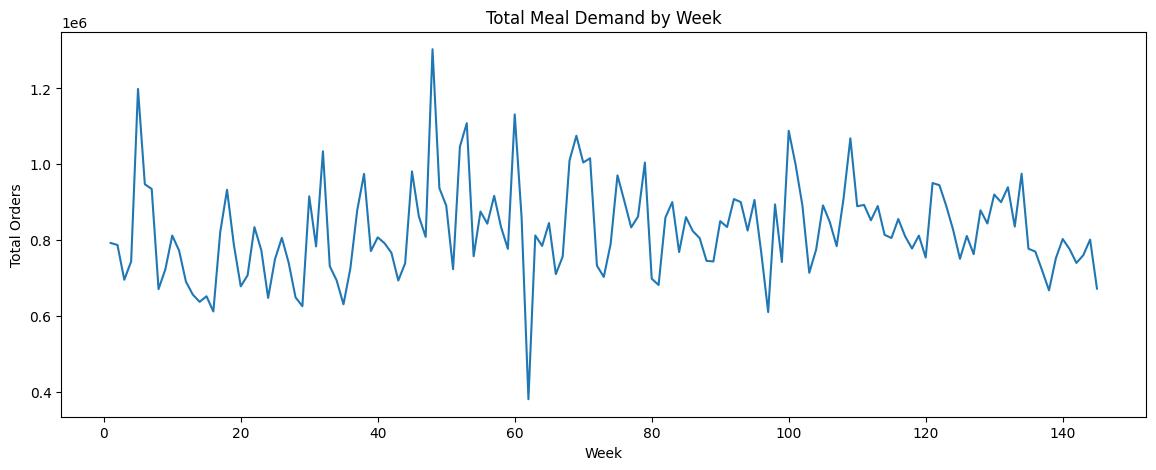

In [438]:
# Overall weekly demand
weekly_demand = (
    train.groupby("week")["num_orders"]
    .sum()
)

plt.figure(figsize=(14, 5))

plt.plot(
    weekly_demand.index,
    weekly_demand.values
)

plt.xlabel("Week")
plt.ylabel("Total Orders")
plt.title("Total Meal Demand by Week")

plt.show()


In [439]:
# How does meal availability/activity vary across fulfillment centers and weeks?

center_week_activity = (
    train.groupby(["center_id", "week"])["meal_id"]
    .nunique()
    .unstack(fill_value=0)
)

center_week_activity.shape

(77, 145)

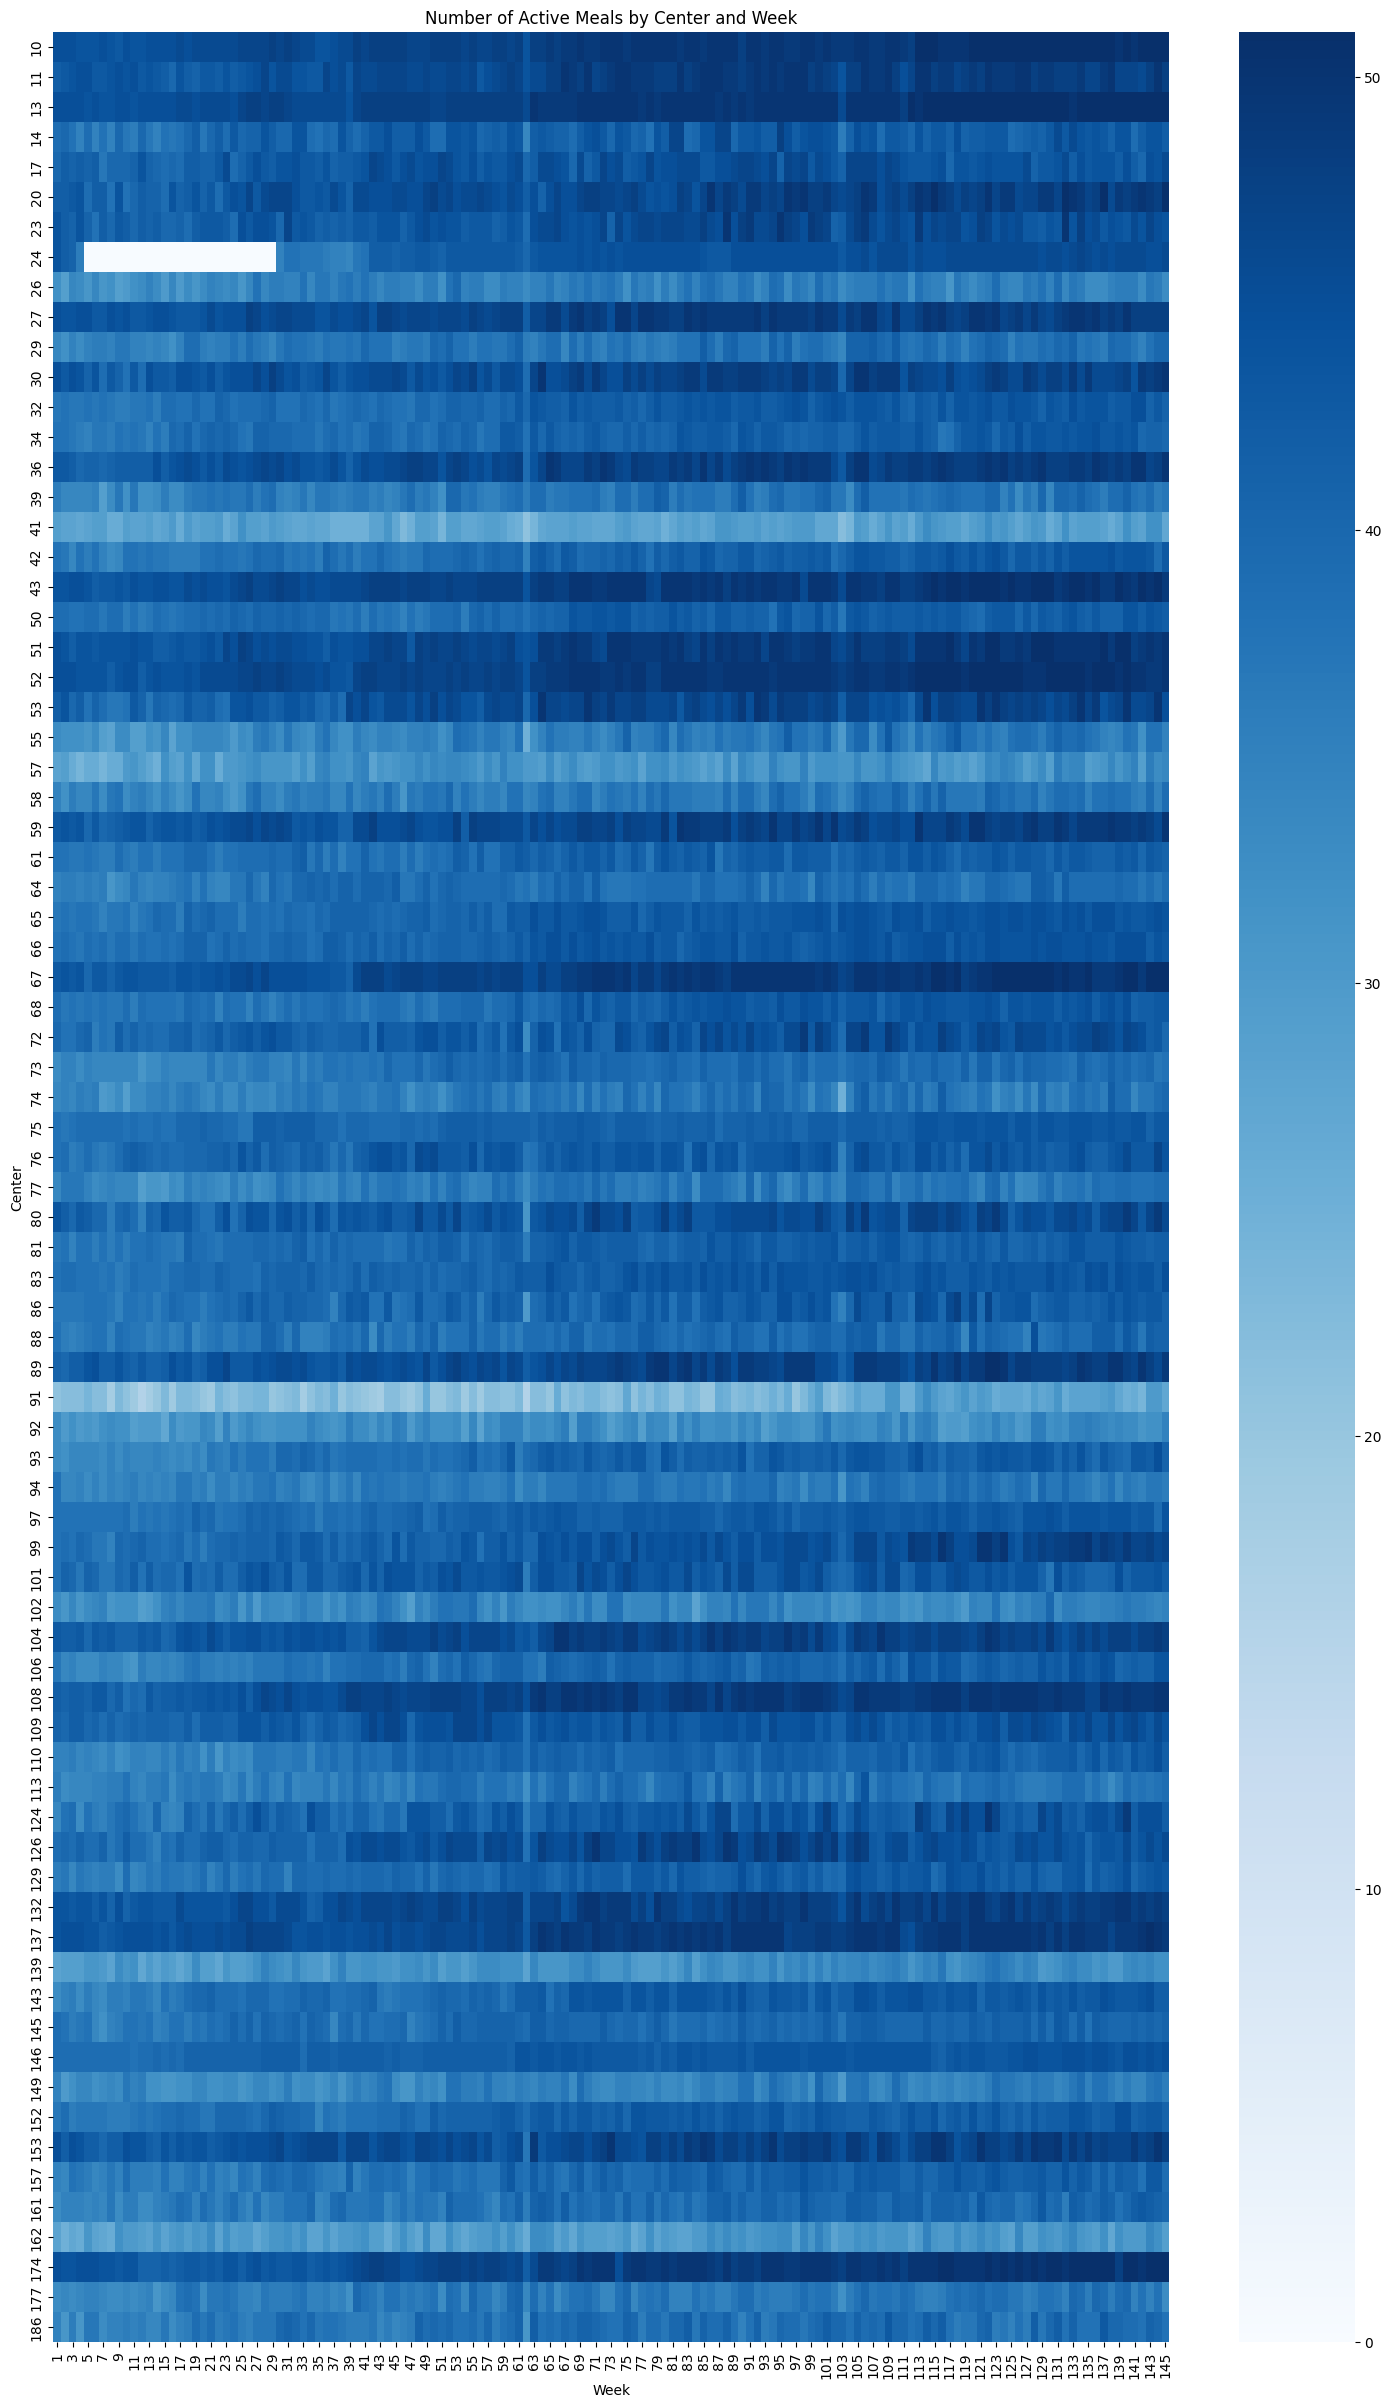

In [440]:
plt.figure(figsize=(18,30))

sns.heatmap(
    center_week_activity,
    cmap="Blues"
)

plt.xlabel("Week")
plt.ylabel("Center")
plt.title("Number of Active Meals by Center and Week")

plt.show()

In [441]:
# Rows: 77 fulfillment centers
# Columns: 145 weeks
# Darker: more active meals
# Lighter: fewer active meals

In [442]:
# calculate total orders for each center in each week
center_week_demand = (
    train.groupby(["center_id", "week"])["num_orders"]
    .sum()
    .unstack(fill_value=0)
)

center_week_demand.shape

(77, 145)

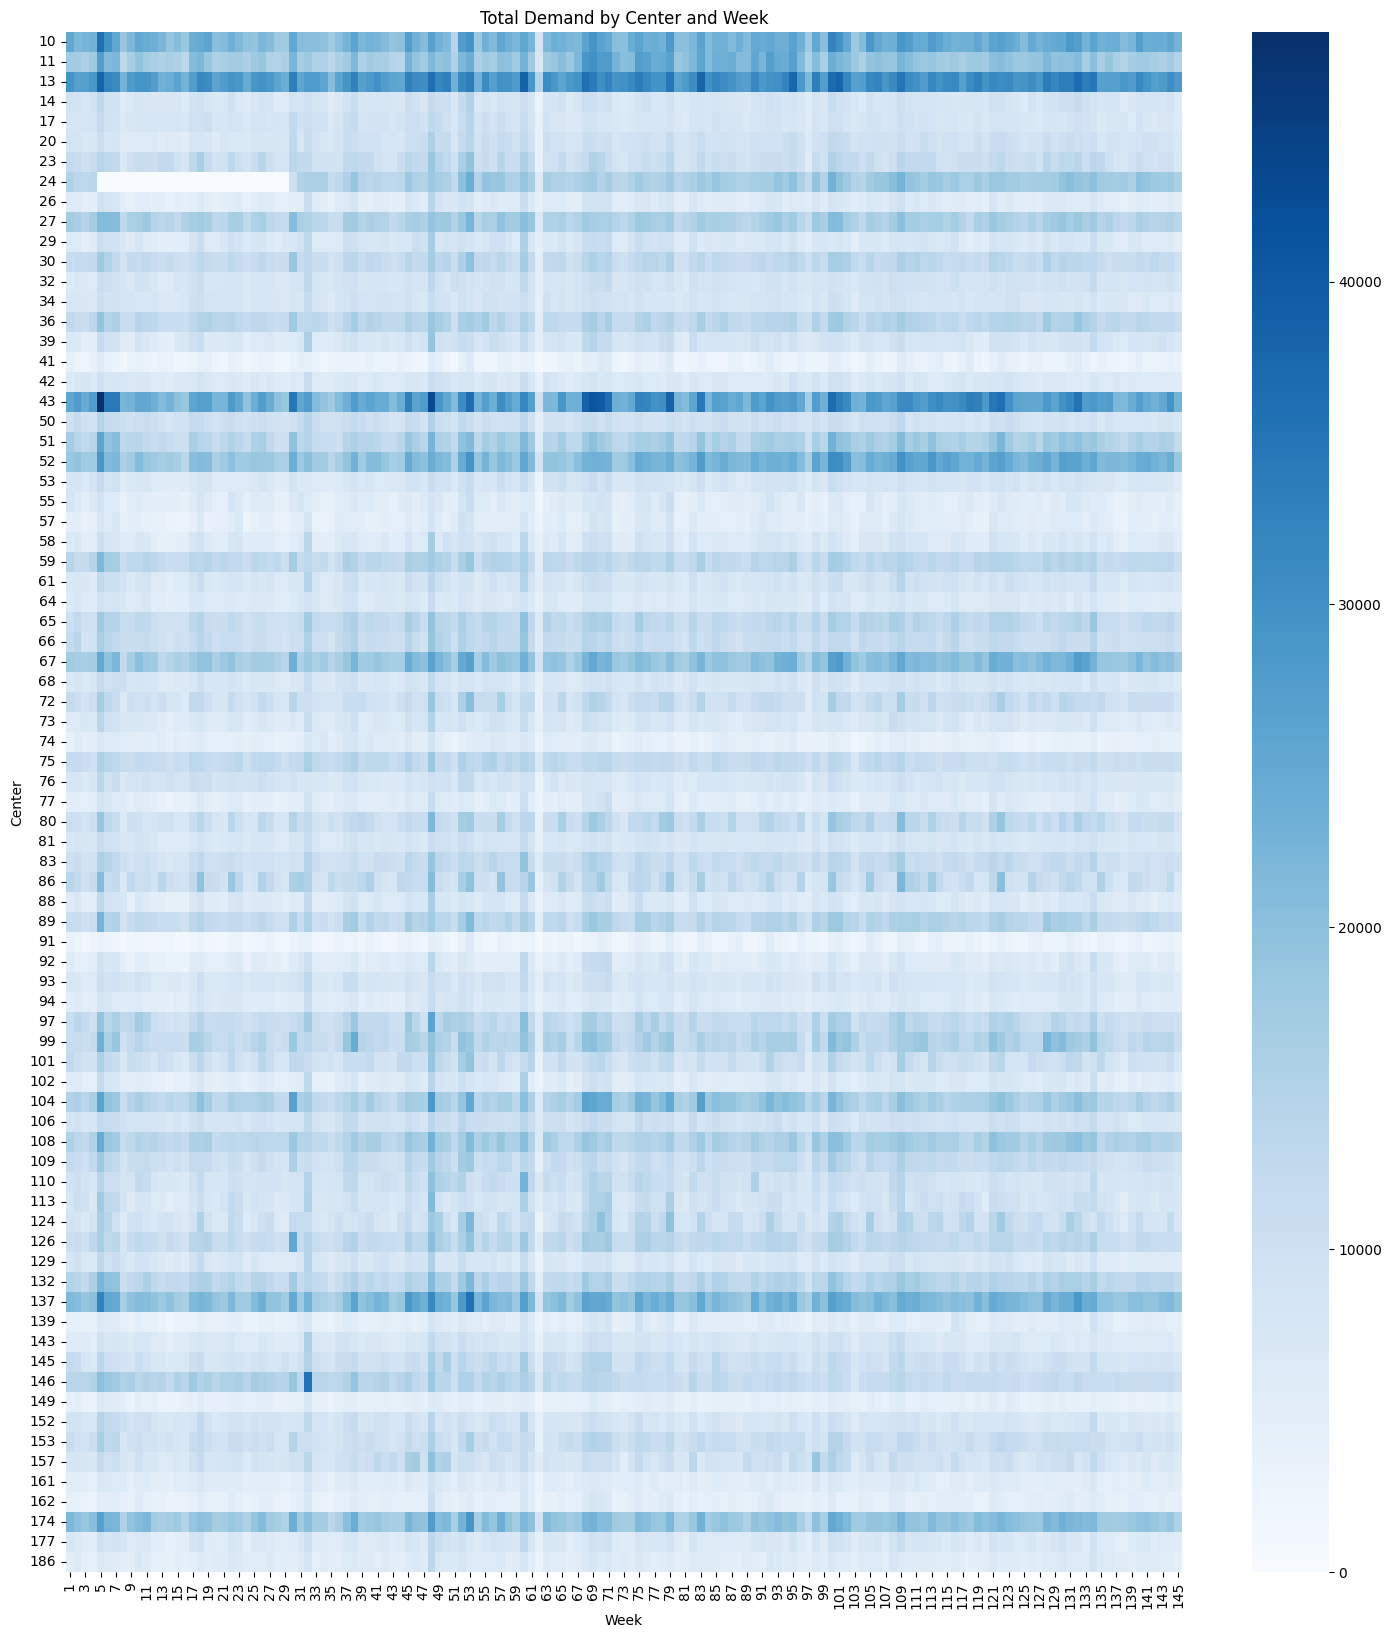

In [443]:
plt.figure(figsize=(18, 20))

sns.heatmap(
    center_week_demand,
    cmap="Blues"
)

plt.xlabel("Week")
plt.ylabel("Center")
plt.title("Total Demand by Center and Week")

plt.show()

In [444]:
"""centers around the upper part of the plot, such as 10, 11, 13, 
appear considerably more active than many centers in the middle/lower 
portions."""

'centers around the upper part of the plot, such as 10, 11, 13, \nappear considerably more active than many centers in the middle/lower \nportions.'

## Meal and centre Vs Demand

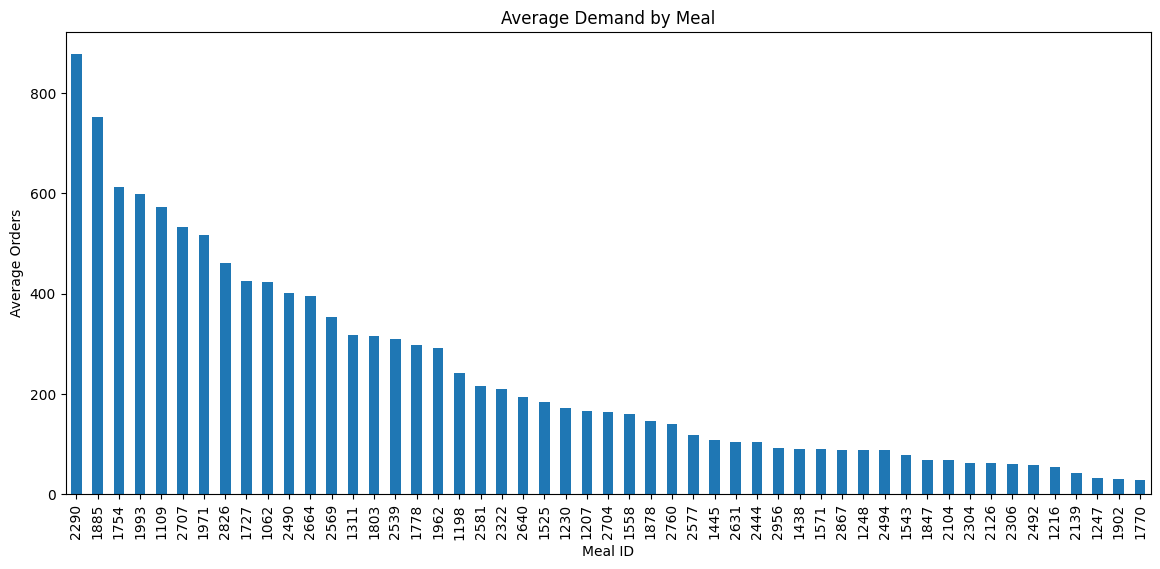

In [445]:
# Which meals generally have higher demand across the entire network?
meal_demand = (
    train.groupby("meal_id")["num_orders"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(14, 6))

meal_demand.plot(kind="bar")

plt.xlabel("Meal ID")
plt.ylabel("Average Orders")
plt.title("Average Demand by Meal")

plt.xticks(rotation=90)

plt.show()

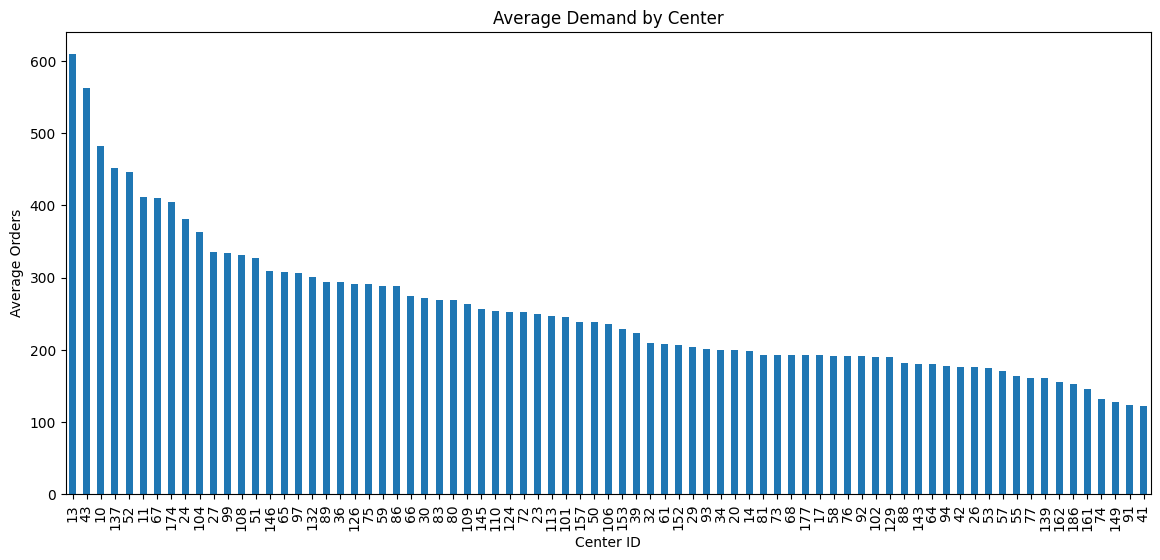

In [446]:
# Which centre generally have higher demand across the entire network?
center_demand = (
    train.groupby("center_id")["num_orders"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(14, 6))

center_demand.plot(kind="bar")

plt.xlabel("Center ID")
plt.ylabel("Average Orders")
plt.title("Average Demand by Center")

plt.xticks(rotation=90)

plt.show()

## Price Vs Demand

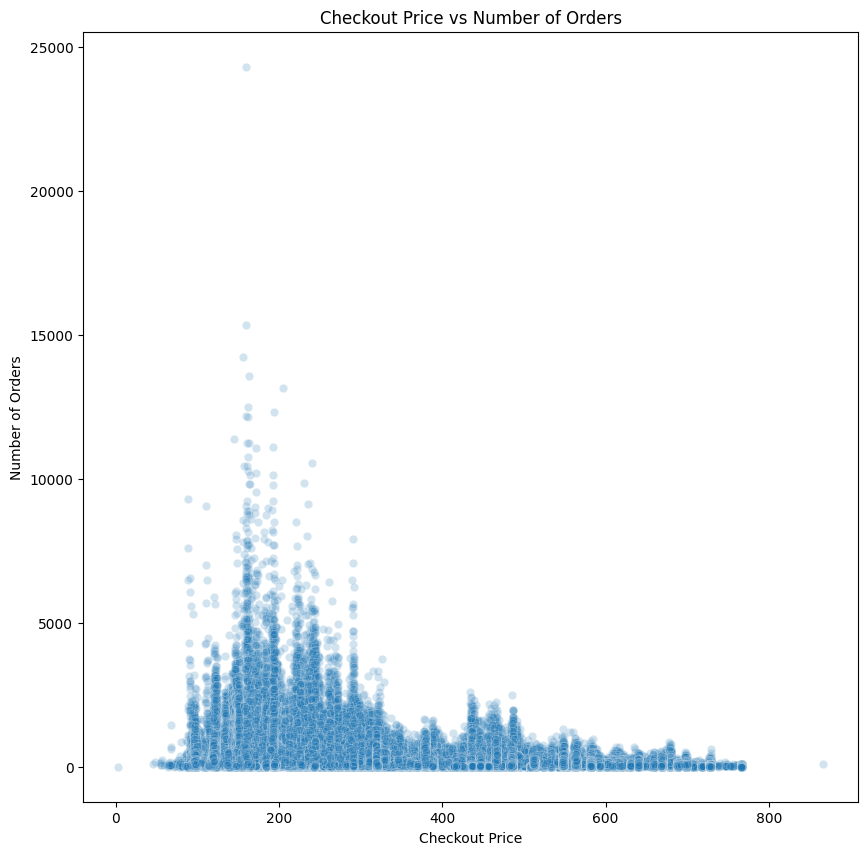

In [447]:
# Checkout price vs orders
# Does demand tend to change when the final checkout price changes?
plt.figure(figsize=(10, 10))

sns.scatterplot(
    data=train,
    x="checkout_price",
    y="num_orders",
    alpha=0.2
)

plt.xlabel("Checkout Price")
plt.ylabel("Number of Orders")
plt.title("Checkout Price vs Number of Orders")

plt.show()

In [448]:
train[["checkout_price", "num_orders"]].corr()

,checkout_price,num_orders
checkout_price,1.000000,-0.282108
num_orders,-0.282108,1.000000


##  Promotion Vs Demand

In [449]:
# Promotion/homepage vs demand
promotion_demand = (
    train.groupby("emailer_for_promotion")["num_orders"]
    .mean()
)

print(promotion_demand)

homepage_demand = (
    train.groupby("homepage_featured")["num_orders"]
    .mean()
)

print(homepage_demand)

emailer_for_promotion
0    229.262883
1    631.097544
Name: num_orders, dtype: float64
homepage_featured
0    221.050040
1    594.884786
Name: num_orders, dtype: float64


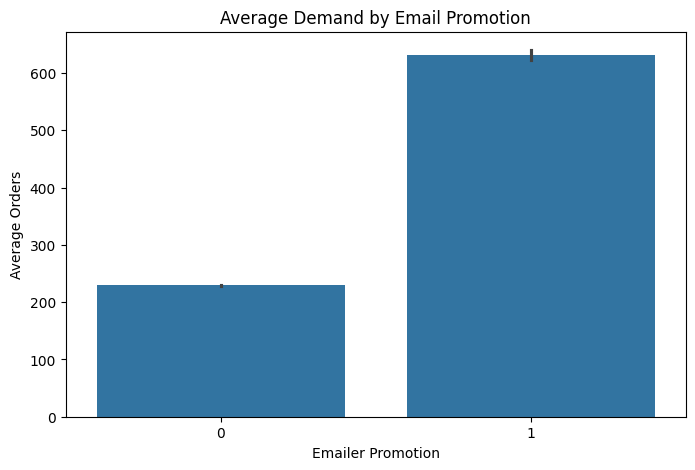

In [450]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=train,
    x="emailer_for_promotion",
    y="num_orders"
)

plt.xlabel("Emailer Promotion")
plt.ylabel("Average Orders")
plt.title("Average Demand by Email Promotion")

plt.show()

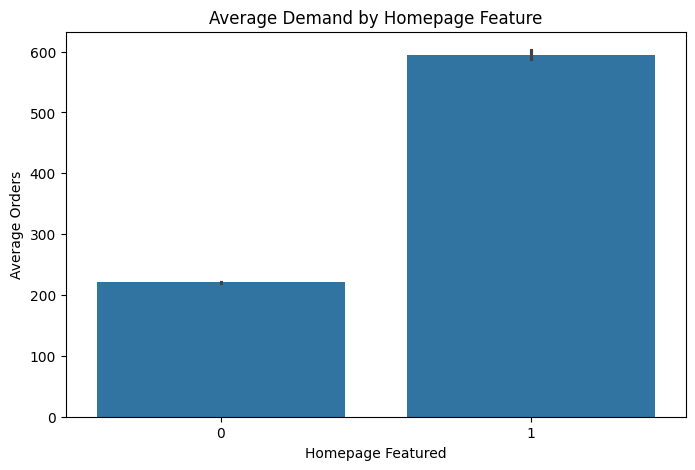

In [451]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=train,
    x="homepage_featured",
    y="num_orders"
)

plt.xlabel("Homepage Featured")
plt.ylabel("Average Orders")
plt.title("Average Demand by Homepage Feature")

plt.show()

## Target Vs Demand

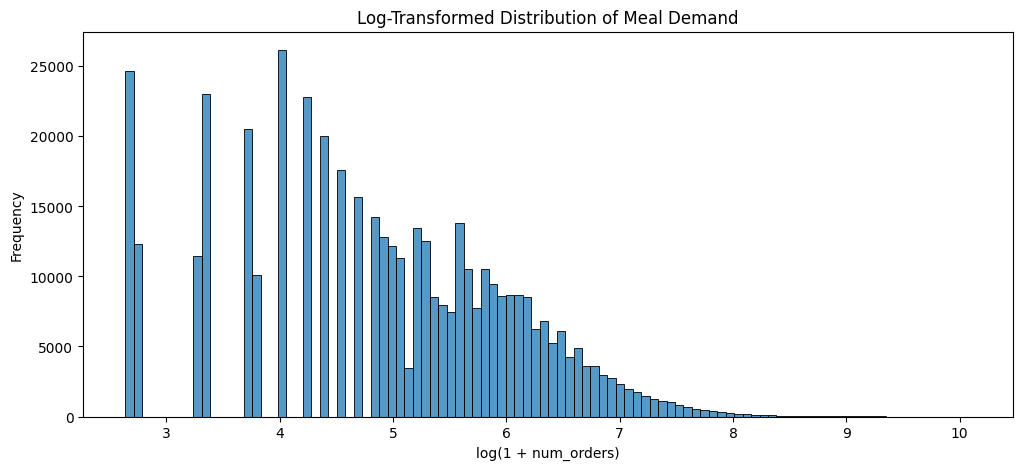

In [452]:
# Distribution of num_orders
plt.figure(figsize=(12, 5))

sns.histplot(
    np.log1p(train["num_orders"]),
    bins=100
)

plt.xlabel("log(1 + num_orders)")
plt.ylabel("Frequency")
plt.title("Log-Transformed Distribution of Meal Demand")

plt.show()


In [453]:
'''Meal Demand Dataset
        ↓
EDA                         ← DONE
        ↓
Time-Series Analysis       ← WE ARE HERE
        ↓
Autocorrelation
        ↓
Lag Analysis
        ↓
Lag Features
        ↓
Rolling Features
        ↓
Time-aware Validation
        ↓
Baseline
        ↓
Forecasting Models
        ├── Prophet
        ├── ARIMA/SARIMA
        └── ML model with lag features
        ↓
Forecast vs Actual
        ↓
RMSLE'''

'Meal Demand Dataset\n        ↓\nEDA                         ← DONE\n        ↓\nTime-Series Analysis       ← WE ARE HERE\n        ↓\nAutocorrelation\n        ↓\nLag Analysis\n        ↓\nLag Features\n        ↓\nRolling Features\n        ↓\nTime-aware Validation\n        ↓\nBaseline\n        ↓\nForecasting Models\n        ├── Prophet\n        ├── ARIMA/SARIMA\n        └── ML model with lag features\n        ↓\nForecast vs Actual\n        ↓\nRMSLE'

# Time-series analysis

## Autocorrelation of demand

In [454]:
# Does demand in previous weeks contain information about demand in the current 
# week?

In [455]:
# Creating total weekly demand
weekly_demand = (
    train.groupby("week")["num_orders"]
    .sum()
)

weekly_demand.head()

week
1     792261
2     787084
3     695262
4     743529
5    1198675
Name: num_orders, dtype: int64

<Figure size 1200x500 with 0 Axes>

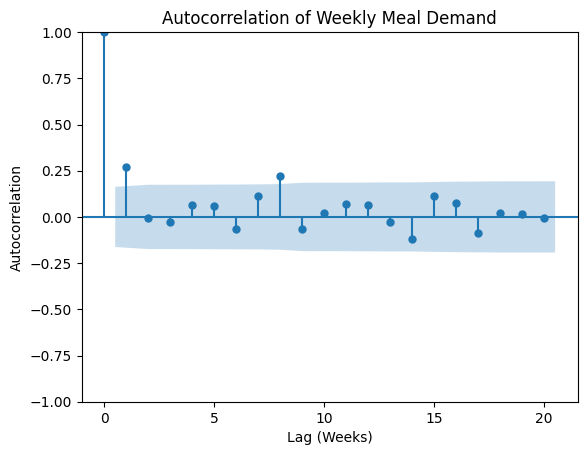

In [456]:
# Plot autocorrelation
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plot_acf(
    weekly_demand,
    lags=20
)

plt.title("Autocorrelation of Weekly Meal Demand")
plt.xlabel("Lag (Weeks)")
plt.ylabel("Autocorrelation")

plt.show()

In [457]:
# lag relationships
lag_analysis = pd.DataFrame({
    "current_demand": weekly_demand,
    "lag_1": weekly_demand.shift(1),
    "lag_2": weekly_demand.shift(2),
    "lag_4": weekly_demand.shift(4),
    "lag_8": weekly_demand.shift(8),
})

lag_analysis.corr()

,current_demand,lag_1,lag_2,lag_4,lag_8
current_demand,1.000000,0.269967,-0.008170,0.063849,0.236125
lag_1,0.269967,1.000000,0.269742,-0.035520,0.107971
lag_2,-0.008170,0.269742,1.000000,-0.013729,-0.073569
lag_4,0.063849,-0.035520,-0.013729,1.000000,0.052193
lag_8,0.236125,0.107971,-0.073569,0.052193,1.000000


In [458]:
# Testing lag-1 correlation across all Center × Meal pairs
train.groupby(["center_id", "meal_id"])["num_orders"].shift(1)

0           NaN
1           NaN
2           NaN
3           NaN
4           NaN
          ...  
456543    123.0
456544     13.0
456545    770.0
456546    811.0
456547    190.0
Name: num_orders, Length: 456548, dtype: float64

In [459]:
lag1_df = train[
    ["center_id", "meal_id", "week", "num_orders"]
].copy()

lag1_df["previous_week"] = (
    lag1_df
    .groupby(["center_id", "meal_id"])["week"]
    .shift(1)
)

lag1_df["previous_orders"] = (
    lag1_df
    .groupby(["center_id", "meal_id"])["num_orders"]
    .shift(1)
)

lag1_df["week_gap"] = (
    lag1_df["week"] - lag1_df["previous_week"]
)

lag1_valid = lag1_df[
    lag1_df["week_gap"] == 1
].copy()

lag1_valid[["week", "previous_week", "week_gap"]].head()

,week,previous_week,week_gap
2922,2,1.0,1.0
2923,2,1.0,1.0
2924,2,1.0,1.0
2925,2,1.0,1.0
2926,2,1.0,1.0


In [460]:
lag1_valid[
    ["center_id", "meal_id", "week",
     "previous_week", "num_orders", "previous_orders", "week_gap"]
].head(10)

,center_id,meal_id,week,previous_week,num_orders,previous_orders,week_gap
2922,55,1885,2,1.0,323,177.0,1.0
2923,55,1993,2,1.0,121,270.0,1.0
2924,55,2539,2,1.0,149,189.0,1.0
2925,55,2631,2,1.0,27,40.0,1.0
2926,55,1248,2,1.0,257,28.0,1.0
2927,55,1778,2,1.0,161,190.0,1.0
2928,55,1062,2,1.0,271,391.0,1.0
2929,55,2707,2,1.0,447,472.0,1.0
2930,55,1207,2,1.0,420,676.0,1.0
2931,55,1230,2,1.0,798,823.0,1.0


In [461]:
# calculate the Center × Meal lag-1 correlation from the lag1_valid DataFrame
lag1_correlation = lag1_valid[
    ["num_orders", "previous_orders"]
].corr()

lag1_correlation

,num_orders,previous_orders
num_orders,1.000000,0.693797
previous_orders,0.693797,1.000000


In [462]:
# Checking lag-8 at the Center × Meal level
lag8_df = train[
    ["center_id", "meal_id", "week", "num_orders"]
].copy()

lag8_df["previous_week"] = (
    lag8_df
    .groupby(["center_id", "meal_id"])["week"]
    .shift(1)
)

lag8_df["previous_orders"] = (
    lag8_df
    .groupby(["center_id", "meal_id"])["num_orders"]
    .shift(1)
)

lag8_df["week_gap"] = (
    lag8_df["week"] - lag8_df["previous_week"]
)

In [463]:
lag8_df = train[
    ["center_id", "meal_id", "week", "num_orders"]
].copy()

lag8_lookup = train[
    ["center_id", "meal_id", "week", "num_orders"]
].copy()

lag8_lookup = lag8_lookup.rename(
    columns={
        "week": "previous_week",
        "num_orders": "previous_orders"
    }
)

lag8_df["previous_week"] = lag8_df["week"] - 8

lag8_df = lag8_df.merge(
    lag8_lookup,
    on=["center_id", "meal_id", "previous_week"],
    how="left"
)

lag8_valid = lag8_df.dropna(
    subset=["previous_orders"]
)

In [464]:
lag8_valid.head()

,center_id,meal_id,week,num_orders,previous_week,previous_orders
22892,55,1885,9,175,1,177.0
22893,55,1993,9,189,1,270.0
22894,55,2539,9,229,1,189.0
22895,55,2139,9,15,1,54.0
22896,55,2631,9,96,1,40.0


In [465]:
lag8_correlation = lag8_valid[
    ["num_orders", "previous_orders"]
].corr()

lag8_correlation

,num_orders,previous_orders
num_orders,1.000000,0.521478
previous_orders,0.521478,1.000000


For observations where the same Center × Meal combination exists both now and 8 weeks earlier, current demand and demand 8 weeks earlier have a fairly strong positive linear relationship.

### Autocorrelation Analysis

- Aggregate weekly demand showed positive autocorrelation at lag 1 and lag 8.
- At the Center × Meal level, lag 1 showed a strong positive correlation of **0.694** with current demand.
- Lag 8 also showed a strong positive correlation of **0.521** with current demand.
- This indicates substantial temporal dependence in meal demand.
- Recent demand appears particularly informative for forecasting.
- Both lag 1 and lag 8 are candidates for lag-based features.
- Missing weeks were explicitly accounted for when calculating lag relationships.
- The lag-8 relationship is not treated as confirmed seasonality without further analysis.

## Lag Feature Engineering

In [466]:
train = train.sort_values(
    ["center_id", "meal_id", "week"]
).copy()

In [467]:
lag_features = train[
    ["center_id", "meal_id", "week", "num_orders"]
].copy()

lag_lookup = train[
    ["center_id", "meal_id", "week", "num_orders"]
].copy()

lag_lookup = lag_lookup.rename(
    columns={
        "week": "previous_week",
        "num_orders": "previous_orders"
    }
)

lag_features["previous_week"] = lag_features["week"] - 1

lag_features = lag_features.merge(
    lag_lookup,
    on=["center_id", "meal_id", "previous_week"],
    how="left"
)

lag_features = lag_features.rename(
    columns={"previous_orders": "lag_1"}
)

lag_features = lag_features.drop(
    columns=["previous_week"]
)

In [468]:
lag_features.head(10)

,center_id,meal_id,week,num_orders,lag_1
0,10,1062,1,865,NaN
1,10,1062,2,782,865.0
2,10,1062,3,851,782.0
3,10,1062,4,1202,851.0
4,10,1062,5,958,1202.0
5,10,1062,6,1094,958.0
6,10,1062,7,1513,1094.0
7,10,1062,8,1149,1513.0
8,10,1062,9,1282,1149.0
9,10,1062,10,1473,1282.0


In [469]:
# making table of all lags
def create_lag_feature(df, lag):
    
    lookup = df[
        ["center_id", "meal_id", "week", "num_orders"]
    ].copy()

    lookup = lookup.rename(
        columns={
            "week": "previous_week",
            "num_orders": f"lag_{lag}"
        }
    )

    result = df.copy()

    result["previous_week"] = result["week"] - lag

    result = result.merge(
        lookup,
        on=["center_id", "meal_id", "previous_week"],
        how="left"
    )

    result = result.drop(columns=["previous_week"])

    return result

In [470]:
lag_features = train.copy()

for lag in [1, 2, 4, 8]:
    lag_features = create_lag_feature(
        lag_features,
        lag
    )

In [471]:
lag_features[
    [
        "center_id",
        "meal_id",
        "week",
        "num_orders",
        "lag_1",
        "lag_2",
        "lag_4",
        "lag_8"
    ]
].head(15)

,center_id,meal_id,week,num_orders,lag_1,lag_2,lag_4,lag_8
0,10,1062,1,865,NaN,NaN,NaN,NaN
1,10,1062,2,782,865.0,NaN,NaN,NaN
2,10,1062,3,851,782.0,865.0,NaN,NaN
3,10,1062,4,1202,851.0,782.0,NaN,NaN
4,10,1062,5,958,1202.0,851.0,865.0,NaN
5,10,1062,6,1094,958.0,1202.0,782.0,NaN
6,10,1062,7,1513,1094.0,958.0,851.0,NaN
7,10,1062,8,1149,1513.0,1094.0,1202.0,NaN
8,10,1062,9,1282,1149.0,1513.0,958.0,865.0
9,10,1062,10,1473,1282.0,1149.0,1094.0,782.0


### Lag Feature Engineering

- Lag features represent historical demand for the same Center × Meal combination.
- `lag_1`, `lag_2`, `lag_4`, and `lag_8` represent demand from 1, 2, 4, and 8 weeks earlier.
- Lag values are matched using actual week numbers rather than row position.
- This prevents missing weeks from being incorrectly treated as consecutive observations.
- Missing lag values occur when the corresponding historical week is unavailable.

## Rolling Feature Engineering

In [472]:
# 4-week rolling mean
lag_features = lag_features.sort_values(
    ["center_id", "meal_id", "week"]
).copy()

lag_features["rolling_mean_4"] = (
    lag_features
    .groupby(["center_id", "meal_id"])["num_orders"]
    .transform(
        lambda x: x.shift(1).rolling(4).mean()
    )
)

In [473]:
# rolling standard deviation
lag_features["rolling_std_4"] = (
    lag_features
    .groupby(["center_id", "meal_id"])["num_orders"]
    .transform(
        lambda x: x.shift(1).rolling(4).std()
    )
)

In [474]:
lag_features[
    [
        "center_id",
        "meal_id",
        "week",
        "num_orders",
        "lag_1",
        "lag_8",
        "rolling_mean_4",
        "rolling_std_4"
    ]
].head(20)

,center_id,meal_id,week,num_orders,lag_1,lag_8,rolling_mean_4,rolling_std_4
0,10,1062,1,865,NaN,NaN,NaN,NaN
1,10,1062,2,782,865.0,NaN,NaN,NaN
2,10,1062,3,851,782.0,NaN,NaN,NaN
3,10,1062,4,1202,851.0,NaN,NaN,NaN
4,10,1062,5,958,1202.0,NaN,925.00,188.196706
5,10,1062,6,1094,958.0,NaN,948.25,184.011549
6,10,1062,7,1513,1094.0,NaN,1026.25,153.675795
7,10,1062,8,1149,1513.0,NaN,1191.75,236.291310
8,10,1062,9,1282,1149.0,865.0,1178.50,237.009845
9,10,1062,10,1473,1282.0,782.0,1259.50,186.519883


### Rolling Features

- Rolling statistics summarize recent historical demand.
- `rolling_mean_4` captures the recent average demand level.
- `rolling_std_4` captures recent demand variability.
- `shift(1)` is applied before rolling calculations to prevent target leakage.
- Missing weeks require care because rolling windows operate on observed rows.

In [475]:
# checking missing values created by lag and rolling features

In [476]:
lag_features[
    [
        "lag_1",
        "lag_2",
        "lag_4",
        "lag_8",
        "rolling_mean_4",
        "rolling_std_4"
    ]
].isna().sum()

lag_1             25101
lag_2             29264
lag_4             36532
lag_8             49693
rolling_mean_4    14374
rolling_std_4     14374
dtype: int64

In [477]:
lag_features[
    [
        "lag_1",
        "lag_2",
        "lag_4",
        "lag_8",
        "rolling_mean_4",
        "rolling_std_4"
    ]
].isna().mean().mul(100).round(2)

lag_1              5.50
lag_2              6.41
lag_4              8.00
lag_8             10.88
rolling_mean_4     3.15
rolling_std_4      3.15
dtype: float64

## Time-aware train/validation split

In [478]:
# Expanding-window cross-validation

In [479]:

'''Fold 1
Train:       weeks 1 ───────── 80
Validate:                   81 ─ 90

Fold 2
Train:       weeks 1 ───────────── 90
Validate:                         91 ─ 100

Fold 3
Train:       weeks 1 ───────────────── 100
Validate:                             101 ─ 110

Fold 4
Train:       weeks 1 ───────────────────── 110
Validate:                                   111 ─ 120

Fold 5
Train:       weeks 1 ───────────────────────── 120
Validate:                                         121 ─ 130'''

'Fold 1\nTrain:       weeks 1 ───────── 80\nValidate:                   81 ─ 90\n\nFold 2\nTrain:       weeks 1 ───────────── 90\nValidate:                         91 ─ 100\n\nFold 3\nTrain:       weeks 1 ───────────────── 100\nValidate:                             101 ─ 110\n\nFold 4\nTrain:       weeks 1 ───────────────────── 110\nValidate:                                   111 ─ 120\n\nFold 5\nTrain:       weeks 1 ───────────────────────── 120\nValidate:                                         121 ─ 130'

In [480]:
# Defining the folds
folds = [
    {"train_end": 80,  "valid_start": 81,  "valid_end": 90},
    {"train_end": 90,  "valid_start": 91,  "valid_end": 100},
    {"train_end": 100, "valid_start": 101, "valid_end": 110},
    {"train_end": 110, "valid_start": 111, "valid_end": 120},
    {"train_end": 120, "valid_start": 121, "valid_end": 130},
]

for i, fold in enumerate(folds, start=1):
    print(
        f"Fold {i}: "
        f"Train 1-{fold['train_end']} | "
        f"Validate {fold['valid_start']}-{fold['valid_end']}"
    )

Fold 1: Train 1-80 | Validate 81-90
Fold 2: Train 1-90 | Validate 91-100
Fold 3: Train 1-100 | Validate 101-110
Fold 4: Train 1-110 | Validate 111-120
Fold 5: Train 1-120 | Validate 121-130


In [481]:
for i, fold in enumerate(folds, start=1):

    train_fold = lag_features[
        lag_features["week"] <= fold["train_end"]
    ]

    valid_fold = lag_features[
        (lag_features["week"] >= fold["valid_start"]) &
        (lag_features["week"] <= fold["valid_end"])
    ]

    print(f"\nFold {i}")
    print(
        "Train:",
        train_fold["week"].min(),
        "→",
        train_fold["week"].max(),
        "| Rows:",
        len(train_fold)
    )

    print(
        "Valid:",
        valid_fold["week"].min(),
        "→",
        valid_fold["week"].max(),
        "| Rows:",
        len(valid_fold)
    )


Fold 1
Train: 1 → 80 | Rows: 244170
Valid: 81 → 90 | Rows: 32446

Fold 2
Train: 1 → 90 | Rows: 276616
Valid: 91 → 100 | Rows: 32681

Fold 3
Train: 1 → 100 | Rows: 309297
Valid: 101 → 110 | Rows: 32510

Fold 4
Train: 1 → 110 | Rows: 341807
Valid: 111 → 120 | Rows: 32591

Fold 5
Train: 1 → 120 | Rows: 374398
Valid: 121 → 130 | Rows: 32845


In [482]:
lag_features.shape

(456548, 15)

In [483]:
lag_features.columns

Index(['id', 'week', 'center_id', 'meal_id', 'checkout_price', 'base_price',
       'emailer_for_promotion', 'homepage_featured', 'num_orders', 'lag_1',
       'lag_2', 'lag_4', 'lag_8', 'rolling_mean_4', 'rolling_std_4'],
      dtype='object')

In [484]:
target = "num_orders"

features = [
    "center_id",
    "meal_id",
    "checkout_price",
    "base_price",
    "emailer_for_promotion",
    "homepage_featured",
    "lag_1",
    "lag_2",
    "lag_4",
    "lag_8",
    "rolling_mean_4",
    "rolling_std_4"
]

In [485]:
lag_features[features + [target]].head()

,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,lag_1,lag_2,lag_4,lag_8,rolling_mean_4,rolling_std_4,num_orders
0,10,1062,181.39,181.39,0,0,NaN,NaN,NaN,NaN,NaN,NaN,865
1,10,1062,183.36,182.36,0,0,865.0,NaN,NaN,NaN,NaN,NaN,782
2,10,1062,184.36,182.36,0,0,782.0,865.0,NaN,NaN,NaN,NaN,851
3,10,1062,182.36,183.36,0,0,851.0,782.0,NaN,NaN,NaN,NaN,1202
4,10,1062,183.39,181.39,0,0,1202.0,851.0,865.0,NaN,925.0,188.196706,958


### Naive baseline

In [486]:
# Building the naive baseline
import numpy as np
from sklearn.metrics import mean_squared_log_error

def rmsle(y_true, y_pred):
    y_pred = np.clip(y_pred, 0, None)
    return np.sqrt(mean_squared_log_error(y_true, y_pred))


folds = [
    {"train_end": 80,  "valid_start": 81,  "valid_end": 90},
    {"train_end": 90,  "valid_start": 91,  "valid_end": 100},
    {"train_end": 100, "valid_start": 101, "valid_end": 110},
    {"train_end": 110, "valid_start": 111, "valid_end": 120},
    {"train_end": 120, "valid_start": 121, "valid_end": 130},
]

In [487]:
def naive_lag1_forecast(train_df, valid_df):
    
    # Store the latest known demand for every Center × Meal pair
    history = (
        train_df
        .sort_values("week")
        .groupby(["center_id", "meal_id"])["num_orders"]
        .last()
        .to_dict()
    )
    
    predictions = []
    
    # Forecast one week at a time
    for week in sorted(valid_df["week"].unique()):
        
        week_data = valid_df[valid_df["week"] == week].copy()
        
        week_predictions = []
        
        for _, row in week_data.iterrows():
            
            key = (row["center_id"], row["meal_id"])
            
            # Last known demand
            prediction = history.get(key, np.nan)
            
            week_predictions.append(prediction)
        
        week_data["prediction"] = week_predictions
        
        # Add predictions to our history
        # so the next forecast week uses predicted demand
        for _, row in week_data.iterrows():
            
            key = (row["center_id"], row["meal_id"])
            
            if not np.isnan(row["prediction"]):
                history[key] = row["prediction"]
        
        predictions.append(week_data)
    
    return pd.concat(predictions, ignore_index=True)

In [488]:
train_fold = train[
    train["week"] <= 80
].copy()

valid_fold = train[
    (train["week"] >= 81) &
    (train["week"] <= 90)
].copy()

baseline_predictions = naive_lag1_forecast(
    train_fold,
    valid_fold
)

baseline_predictions.head()

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,prediction
0,1233179,81,10,1062,182.42,181.42,0,0,824,757.0
1,1358087,81,10,1109,310.43,311.43,0,0,1066,1364.0
2,1419140,81,10,1198,188.24,188.24,0,1,324,485.0
3,1485022,81,10,1207,383.18,460.78,0,0,203,122.0
4,1388094,81,10,1216,408.43,406.43,0,0,162,163.0


In [489]:
baseline_predictions["prediction"].isna().sum()

np.int64(6)

In [490]:
# Finding the 6 cold-start rows
cold_start = baseline_predictions[
    baseline_predictions["prediction"].isna()
]

cold_start[
    ["week", "center_id", "meal_id", "num_orders", "prediction"]
]

,week,center_id,meal_id,num_orders,prediction
15101,85,101,1571,14,NaN
22177,87,139,2577,15,NaN
25789,88,162,2139,14,NaN
29027,89,162,2139,55,NaN
32097,90,149,1770,13,NaN
32309,90,162,2139,54,NaN


In [491]:
train[
    (train["center_id"] == 101) &
    (train["meal_id"] == 1571) &
    (train["week"] <= 80)
][["week", "num_orders"]]

,week,num_orders


In [492]:
train[
    (train["meal_id"] == 1571) &
    (train["week"] <= 80)
][["week", "center_id", "num_orders"]].head()

,week,center_id,num_orders
192020,64,10,53
195242,65,10,96
198432,66,10,68
201635,67,10,109
204851,68,10,27


In [493]:
meal_mean = (
    train_fold
    .groupby("meal_id")["num_orders"]
    .mean()
    .to_dict()
)

print(meal_mean.get(1571))

56.36312849162011


For Meal 1571, the meal itself definitely exists before the validation period.
But the specific pair: Center 101 × Meal 1571
doesn't exist before Week 81.

So this is a genuine new Center × Meal combination, not a missing meal.
Use Meal 1571 historical average, **56.3631 orders**

In [494]:
# Recreating the meal-level averages
meal_mean = (
    train_fold
    .groupby("meal_id")["num_orders"]
    .mean()
    .to_dict()
)

# Checking the six cold-start rows
cold_start_check = cold_start[
    ["week", "center_id", "meal_id", "num_orders"]
].copy()

cold_start_check["meal_mean_prediction"] = (
    cold_start_check["meal_id"]
    .map(meal_mean)
)

cold_start_check

,week,center_id,meal_id,num_orders,meal_mean_prediction
15101,85,101,1571,14,56.363128
22177,87,139,2577,15,122.482808
25789,88,162,2139,14,37.500880
29027,89,162,2139,55,37.500880
32097,90,149,1770,13,27.760046
32309,90,162,2139,54,37.500880


In [495]:
cold_start_check[
    cold_start_check["meal_mean_prediction"].isna()
]

,week,center_id,meal_id,num_orders,meal_mean_prediction


In [496]:
# Rebuilding the baseline cleanly
# Naive Lag-1 Baseline with Cold-Start Handling

def naive_lag1_forecast(train_df, valid_df):

    # Latest known demand for each Center × Meal pair
    history = (
        train_df
        .sort_values("week")
        .groupby(["center_id", "meal_id"])["num_orders"]
        .last()
        .to_dict()
    )

    # Historical average demand for each meal
    meal_mean = (
        train_df
        .groupby("meal_id")["num_orders"]
        .mean()
        .to_dict()
    )

    # Final fallback if even the meal has no history
    global_mean = train_df["num_orders"].mean()

    predictions = []

    # Forecast each validation week sequentially
    for week in sorted(valid_df["week"].unique()):

        week_data = valid_df[
            valid_df["week"] == week
        ].copy()

        week_predictions = []

        for _, row in week_data.iterrows():

            key = (row["center_id"], row["meal_id"])

            if key in history:
                # Normal case: use the latest known demand
                prediction = history[key]

            elif row["meal_id"] in meal_mean:
                # Cold-start Center × Meal:
                # use the historical average for this meal
                prediction = meal_mean[row["meal_id"]]

            else:
                # Extreme fallback
                prediction = global_mean

            week_predictions.append(prediction)

        week_data["prediction"] = week_predictions

        # Add this week's predictions to history.
        # Therefore the next validation week uses predictions,
        # not the actual validation demand.
        for _, row in week_data.iterrows():

            key = (row["center_id"], row["meal_id"])
            history[key] = row["prediction"]

        predictions.append(week_data)

    return pd.concat(predictions, ignore_index=True)

In [497]:
# Fold 1: train on Weeks 1–80 and recursively forecast Weeks 81–90

train_fold = train[
    train["week"] <= 80
].copy()

valid_fold = train[
    (train["week"] >= 81) &
    (train["week"] <= 90)
].copy()

baseline_predictions = naive_lag1_forecast(
    train_fold,
    valid_fold
)

In [498]:
# Verifying that every validation row now has a prediction
print(
    "Validation rows:",
    len(baseline_predictions)
)

print(
    "Missing predictions:",
    baseline_predictions["prediction"].isna().sum()
)

Validation rows: 32446
Missing predictions: 0


In [499]:
# Inspecting the first few recursive predictions
baseline_predictions[
    [
        "week",
        "center_id",
        "meal_id",
        "num_orders",
        "prediction"
    ]
].head(10)

,week,center_id,meal_id,num_orders,prediction
0,81,10,1062,824,757.0
1,81,10,1109,1066,1364.0
2,81,10,1198,324,485.0
3,81,10,1207,203,122.0
4,81,10,1216,162,163.0
5,81,10,1230,136,95.0
6,81,10,1247,40,28.0
7,81,10,1248,189,323.0
8,81,10,1311,809,581.0
9,81,10,1438,54,53.0


In [500]:
# RMSLE is the competition metric.
# Predictions are clipped at zero because demand cannot be negative.

fold1_rmsle = rmsle(
    baseline_predictions["num_orders"],
    baseline_predictions["prediction"]
)

print("Fold 1 RMSLE:", fold1_rmsle)

Fold 1 RMSLE: 0.8092056224208264


In [501]:
# Evaluate the naive baseline across all expanding folds
baseline_results = []

for i, fold in enumerate(folds, start=1):

    train_fold = train[
        train["week"] <= fold["train_end"]
    ].copy()

    valid_fold = train[
        (train["week"] >= fold["valid_start"]) &
        (train["week"] <= fold["valid_end"])
    ].copy()

    # Recursive multi-week forecast
    predictions = naive_lag1_forecast(
        train_fold,
        valid_fold
    )

    # Calculate RMSLE for this fold
    score = rmsle(
        predictions["num_orders"],
        predictions["prediction"]
    )

    baseline_results.append({
        "fold": i,
        "train_end": fold["train_end"],
        "valid_start": fold["valid_start"],
        "valid_end": fold["valid_end"],
        "rmsle": score
    })

baseline_results = pd.DataFrame(baseline_results)

baseline_results

,fold,train_end,valid_start,valid_end,rmsle
0,1,80,81,90,0.809206
1,2,90,91,100,0.794235
2,3,100,101,110,0.877942
3,4,110,111,120,0.836223
4,5,120,121,130,0.808604


In [502]:
# Average performance across all expanding folds
print(
    "Average CV RMSLE:",
    baseline_results["rmsle"].mean()
)

Average CV RMSLE: 0.8252418502097447


In [503]:
# Variation between validation periods
print(
    "RMSLE standard deviation:",
    baseline_results["rmsle"].std()
)

RMSLE standard deviation: 0.0331410872672504


In [504]:
# Storing baseline model performance
model_results = pd.DataFrame({
    "model": ["Naive Lag-1"],
    "cv_rmsle": [baseline_results["rmsle"].mean()]
})

model_results

,model,cv_rmsle
0,Naive Lag-1,0.825242


### XGBoost

In [505]:
# XGBoost model and evaluation utilities
import xgboost as xgb
import numpy as np
import pandas as pd

from sklearn.metrics import mean_squared_log_error

print("XGBoost version:", xgb.__version__)

XGBoost version: 3.2.0


In [506]:
# Features used by the first XGBoost model
features = [
    "center_id",
    "meal_id",
    "checkout_price",
    "base_price",
    "emailer_for_promotion",
    "homepage_featured",
    "lag_1",
    "lag_2",
    "lag_4",
    "lag_8",
    "rolling_mean_4",
    "rolling_std_4"
]

target = "num_orders"

In [507]:
# Create forecasting features from historical demand
def create_forecast_features(history_df, forecast_df, forecast_week):
    
    result = forecast_df.copy()

    # Historical demand lookup for each Center × Meal × Week
    demand_lookup = (
        history_df[
            ["center_id", "meal_id", "week", "num_orders"]
        ]
        .rename(columns={
            "week": "history_week",
            "num_orders": "history_orders"
        })
    )

    # Create exact historical lag features.
    # We use merges rather than groupby.shift because
    # some Center × Meal combinations have missing weeks.
    for lag in [1, 2, 4, 8]:

        result["lookup_week"] = forecast_week - lag

        result = result.merge(
            demand_lookup,
            left_on=["center_id", "meal_id", "lookup_week"],
            right_on=["center_id", "meal_id", "history_week"],
            how="left"
        )

        result[f"lag_{lag}"] = result["history_orders"]

        result = result.drop(
            columns=["lookup_week", "history_week", "history_orders"]
        )

    
    # Rolling features
    # For each Center × Meal, use the previous four
    # available historical observations.
    # The current forecast week's demand is never included.

    rolling_stats = (
        history_df
        .sort_values(["center_id", "meal_id", "week"])
        .groupby(["center_id", "meal_id"])["num_orders"]
        .agg(
            rolling_mean_4=lambda x: x.tail(4).mean(),
            rolling_std_4=lambda x: x.tail(4).std()
        )
        .reset_index()
    )

    result = result.merge(
        rolling_stats,
        on=["center_id", "meal_id"],
        how="left"
    )

    return result

In [508]:
# XGBoost baseline

# The target is transformed with log1p because:
# 1. num_orders is strongly right-skewed
# 2. RMSLE evaluates errors on a logarithmic scale


model = xgb.XGBRegressor(
    objective="reg:squarederror",
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

In [509]:
# Fold 1

train_fold = train[
    train["week"] <= 80
].copy()

valid_fold = train[
    (train["week"] >= 81) &
    (train["week"] <= 90)
].copy()

print("Training rows:", len(train_fold))
print("Validation rows:", len(valid_fold))

Training rows: 244170
Validation rows: 32446


In [510]:
# Train XGBoost on Fold 1

xgb_train = lag_features[
    lag_features["week"] <= 80
].copy()

X_train = xgb_train[features]

y_train = np.log1p(
    xgb_train["num_orders"]
)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (244170, 12)
y_train shape: (244170,)


In [511]:
# Train the XGBoost model
model.fit(
    X_train,
    y_train
)

print("XGBoost training completed.")

XGBoost training completed.


In [512]:
# Inspect the trained model
print(model)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=-1, num_parallel_tree=None, ...)


In [513]:
# Recursive XGBoost Forecast

# The model forecasts one week at a time.
# After predicting a week, its predictions are added to the
# history and become the "known demand" for the next week.
#
# This prevents actual validation demand from leaking into
# future lag features.
# ============================================================

def recursive_xgb_forecast(model, train_df, valid_df, features):

    # Start with only the historical training data
    history = train_df.copy()

    predictions = []

    # Forecast each validation week sequentially
    for week in sorted(valid_df["week"].unique()):

        week_data = valid_df[
            valid_df["week"] == week
        ].copy()

        # Create lag and rolling features using only history
        week_features = create_forecast_features(
            history_df=history,
            forecast_df=week_data,
            forecast_week=week
        )

        # Select the features expected by XGBoost
        X_week = week_features[features]

        # Predict log-transformed demand
        log_predictions = model.predict(X_week)

        # Convert back to original order scale
        predictions_orders = np.expm1(log_predictions)

        # Demand cannot be negative
        predictions_orders = np.clip(
            predictions_orders,
            0,
            None
        )

        week_data["prediction"] = predictions_orders

        # Add predictions to history so that they can be used
        # as lag values for the following validation week.
        predicted_history = week_data[
            [
                "id",
                "week",
                "center_id",
                "meal_id",
                "num_orders",
                "prediction"
            ]
        ].copy()

        predicted_history["num_orders"] = (
            predicted_history["prediction"]
        )

        predicted_history = predicted_history.drop(
            columns=["prediction"]
        )

        history = pd.concat(
            [history, predicted_history],
            ignore_index=True
        )

        predictions.append(week_data)

    return pd.concat(
        predictions,
        ignore_index=True
    )

In [514]:
# Generating recursive predictions for Weeks 81–90

xgb_predictions = recursive_xgb_forecast(
    model=model,
    train_df=train_fold,
    valid_df=valid_fold,
    features=features
)

print("Prediction rows:", len(xgb_predictions))
print(
    "Missing predictions:",
    xgb_predictions["prediction"].isna().sum()
)

Prediction rows: 32446
Missing predictions: 0


In [515]:
# Comparing actual demand with XGBoost predictions

xgb_predictions[
    [
        "week",
        "center_id",
        "meal_id",
        "num_orders",
        "prediction"
    ]
].head(10)

,week,center_id,meal_id,num_orders,prediction
0,81,10,1062,824,715.877136
1,81,10,1109,1066,970.041138
2,81,10,1198,324,542.158875
3,81,10,1207,203,122.898155
4,81,10,1216,162,85.932693
5,81,10,1230,136,80.491943
6,81,10,1247,40,35.621613
7,81,10,1248,189,219.499298
8,81,10,1311,809,592.532593
9,81,10,1438,54,51.369629


In [516]:
# Evaluating the recursive XGBoost forecast

xgb_fold1_rmsle = rmsle(
    xgb_predictions["num_orders"],
    xgb_predictions["prediction"]
)

print("XGBoost Fold 1 RMSLE:", xgb_fold1_rmsle)
print("Naive Fold 1 RMSLE:", baseline_results.loc[0, "rmsle"])

XGBoost Fold 1 RMSLE: 0.5267273585392052
Naive Fold 1 RMSLE: 0.8092056224208264


In [517]:
# Recursive XGBoost Cross-Validation
# ============================================================
# Each fold trains a fresh XGBoost model using only the
# historical period available before that validation window.

xgb_cv_results = []

for i, fold in enumerate(folds, start=1):

    print(f"\n{'=' * 50}")
    print(f"Fold {i}")
    print(f"Train: Weeks 1–{fold['train_end']}")
    print(
        f"Valid: Weeks {fold['valid_start']}–{fold['valid_end']}"
    )
    print(f"{'=' * 50}")

    # Split the data by time
    train_fold = train[
        train["week"] <= fold["train_end"]
    ].copy()

    valid_fold = train[
        (train["week"] >= fold["valid_start"]) &
        (train["week"] <= fold["valid_end"])
    ].copy()


    # Create a fresh model for this fold
    
    fold_model = xgb.XGBRegressor(
        objective="reg:squarederror",
        n_estimators=500,
        learning_rate=0.05,
        max_depth=8,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )

    # Use only historical feature rows for training
    xgb_train = lag_features[
        lag_features["week"] <= fold["train_end"]
    ].copy()

    X_train = xgb_train[features]

    y_train = np.log1p(
        xgb_train["num_orders"]
    )

    # Train on log-transformed demand
    fold_model.fit(
        X_train,
        y_train
    )
    
    # Recursive multi-week forecast
    predictions = recursive_xgb_forecast(
        model=fold_model,
        train_df=train_fold,
        valid_df=valid_fold,
        features=features
    )

    # Evaluate using RMSLE
    score = rmsle(
        predictions["num_orders"],
        predictions["prediction"]
    )

    xgb_cv_results.append({
        "fold": i,
        "train_end": fold["train_end"],
        "valid_start": fold["valid_start"],
        "valid_end": fold["valid_end"],
        "rmsle": score
    })

    print(f"Fold {i} RMSLE: {score:.6f}")


Fold 1
Train: Weeks 1–80
Valid: Weeks 81–90
Fold 1 RMSLE: 0.526727

Fold 2
Train: Weeks 1–90
Valid: Weeks 91–100
Fold 2 RMSLE: 0.544124

Fold 3
Train: Weeks 1–100
Valid: Weeks 101–110
Fold 3 RMSLE: 0.567539

Fold 4
Train: Weeks 1–110
Valid: Weeks 111–120
Fold 4 RMSLE: 0.560909

Fold 5
Train: Weeks 1–120
Valid: Weeks 121–130
Fold 5 RMSLE: 0.512528


In [518]:
xgb_cv_results = pd.DataFrame(
    xgb_cv_results
)

xgb_cv_results

,fold,train_end,valid_start,valid_end,rmsle
0,1,80,81,90,0.526727
1,2,90,91,100,0.544124
2,3,100,101,110,0.567539
3,4,110,111,120,0.560909
4,5,120,121,130,0.512528


In [519]:
# Calculatimg average and variation across folds
xgb_mean_rmsle = xgb_cv_results["rmsle"].mean()
xgb_std_rmsle = xgb_cv_results["rmsle"].std()

print("XGBoost Average CV RMSLE:", xgb_mean_rmsle)
print("XGBoost RMSLE Std:", xgb_std_rmsle)

XGBoost Average CV RMSLE: 0.5423653814631674
XGBoost RMSLE Std: 0.022997004319333936


### Baseline Model Comparison

- Naive Lag-1 forecasting produced an average CV RMSLE of **0.8252**.
- XGBoost with price, promotion, Center × Meal identifiers, lag features, and rolling features produced an average CV RMSLE of **0.5424**.
- XGBoost achieved a lower RMSLE than the naive baseline across all five expanding validation folds.
- XGBoost also showed lower fold-to-fold variation (std. dev. **0.0230**) than the naive baseline (**0.0331**).
- The results indicate that demand is influenced by factors beyond the most recent observed demand.
- The current XGBoost configuration is a baseline model, not a tuned final model.

In [520]:
# Feature Importance
importance = pd.DataFrame({
    "feature": features,
    "importance": model.feature_importances_
})

importance = importance.sort_values(
    "importance",
    ascending=False
)

importance

,feature,importance
6,lag_1,0.376246
4,emailer_for_promotion,0.249617
10,rolling_mean_4,0.137764
7,lag_2,0.065248
5,homepage_featured,0.056742
2,checkout_price,0.028567
9,lag_8,0.025877
11,rolling_std_4,0.015244
3,base_price,0.014247
1,meal_id,0.012685


In [521]:
# Display features from most to least important
print(
    importance.to_string(index=False)
)

              feature  importance
                lag_1    0.376246
emailer_for_promotion    0.249617
       rolling_mean_4    0.137764
                lag_2    0.065248
    homepage_featured    0.056742
       checkout_price    0.028567
                lag_8    0.025877
        rolling_std_4    0.015244
           base_price    0.014247
              meal_id    0.012685
                lag_4    0.011557
            center_id    0.006206


In [522]:
# Inspect meal and fulfillment-center metadata
print("Meal info:")
display(meal_info.head())

print("\nCenter info:")
display(center_info.head())

Meal info:


,meal_id,category,cuisine
0,1885,Beverages,Thai
1,1993,Beverages,Thai
2,2539,Beverages,Thai
3,1248,Beverages,Indian
4,2631,Beverages,Indian



Center info:


,center_id,city_code,region_code,center_type,op_area
0,11,679,56,TYPE_A,3.7
1,13,590,56,TYPE_B,6.7
2,124,590,56,TYPE_C,4.0
3,66,648,34,TYPE_A,4.1
4,94,632,34,TYPE_C,3.6


In [523]:
# Add meal and fulfillment-center metadata
train_enriched = train.merge(
    meal_info,
    on="meal_id",
    how="left"
)

train_enriched = train_enriched.merge(
    center_info,
    on="center_id",
    how="left"
)

print("Original shape:", train.shape)
print("Enriched shape:", train_enriched.shape)

Original shape: (456548, 9)
Enriched shape: (456548, 15)


In [524]:
# Checking whether any rows failed to find meal or center metadata
metadata_columns = [
    "category",
    "cuisine",
    "city_code",
    "region_code",
    "center_type",
    "op_area"
]

train_enriched[metadata_columns].isna().sum()

category       0
cuisine        0
city_code      0
region_code    0
center_type    0
op_area        0
dtype: int64

In [525]:
# The original forecasting grain must remain:
# Center × Meal × Week

print(
    "Original rows:",
    len(train)
)

print(
    "Enriched rows:",
    len(train_enriched)
)

print(
    "Unique Center × Meal × Week:",
    train_enriched[
        ["center_id", "meal_id", "week"]
    ].drop_duplicates().shape[0]
)

Original rows: 456548
Enriched rows: 456548
Unique Center × Meal × Week: 456548


In [526]:
# Sort by Center × Meal × Week before creating time-based features
train_enriched = train_enriched.sort_values(
    ["center_id", "meal_id", "week"]
).copy()

lag_features_enriched = train_enriched.copy()

In [527]:
# create the lag function

def create_lag_feature(df, lag):
    # Match each observation with the same Center × Meal
    # from exactly `lag` weeks earlier.

    lookup = df[
        ["center_id", "meal_id", "week", "num_orders"]
    ].copy()

    lookup = lookup.rename(
        columns={
            "week": "previous_week",
            "num_orders": f"lag_{lag}"
        }
    )

    result = df.copy()

    result["previous_week"] = result["week"] - lag

    result = result.merge(
        lookup,
        on=["center_id", "meal_id", "previous_week"],
        how="left"
    )

    result = result.drop(columns=["previous_week"])

    return result

In [528]:
# Create the historical demand features
for lag in [1, 2, 4, 8]:
    lag_features_enriched = create_lag_feature(
        lag_features_enriched,
        lag
    )

In [529]:
# Create rolling features

# Calculate recent demand level and variability
# without using the current week's target.

lag_features_enriched = lag_features_enriched.sort_values(
    ["center_id", "meal_id", "week"]
).copy()

lag_features_enriched["rolling_mean_4"] = (
    lag_features_enriched
    .groupby(["center_id", "meal_id"])["num_orders"]
    .transform(
        lambda x: x.shift(1).rolling(4).mean()
    )
)

lag_features_enriched["rolling_std_4"] = (
    lag_features_enriched
    .groupby(["center_id", "meal_id"])["num_orders"]
    .transform(
        lambda x: x.shift(1).rolling(4).std()
    )
)

In [530]:
print("Shape:", lag_features_enriched.shape)

lag_features_enriched[
    [
        "center_id",
        "meal_id",
        "week",
        "num_orders",
        "lag_1",
        "lag_2",
        "lag_4",
        "lag_8",
        "rolling_mean_4",
        "rolling_std_4"
    ]
].head(10)

Shape: (456548, 21)


,center_id,meal_id,week,num_orders,lag_1,lag_2,lag_4,lag_8,rolling_mean_4,rolling_std_4
0,10,1062,1,865,NaN,NaN,NaN,NaN,NaN,NaN
1,10,1062,2,782,865.0,NaN,NaN,NaN,NaN,NaN
2,10,1062,3,851,782.0,865.0,NaN,NaN,NaN,NaN
3,10,1062,4,1202,851.0,782.0,NaN,NaN,NaN,NaN
4,10,1062,5,958,1202.0,851.0,865.0,NaN,925.00,188.196706
5,10,1062,6,1094,958.0,1202.0,782.0,NaN,948.25,184.011549
6,10,1062,7,1513,1094.0,958.0,851.0,NaN,1026.25,153.675795
7,10,1062,8,1149,1513.0,1094.0,1202.0,NaN,1191.75,236.291310
8,10,1062,9,1282,1149.0,1513.0,958.0,865.0,1178.50,237.009845
9,10,1062,10,1473,1282.0,1149.0,1094.0,782.0,1259.50,186.519883


In [531]:
# Features for the enriched XGBoost model

features_enriched = [
    # Center and meal identity
    "center_id",
    "meal_id",

    # Meal characteristics
    "category",
    "cuisine",

    # Center characteristics
    "city_code",
    "region_code",
    "center_type",
    "op_area",

    # Pricing and promotion
    "checkout_price",
    "base_price",
    "emailer_for_promotion",
    "homepage_featured",

    # Historical demand
    "lag_1",
    "lag_2",
    "lag_4",
    "lag_8",
    "rolling_mean_4",
    "rolling_std_4"
]

target = "num_orders"

In [532]:
lag_features_enriched[
    features_enriched
].head()

,center_id,meal_id,category,cuisine,city_code,region_code,center_type,op_area,checkout_price,base_price,emailer_for_promotion,homepage_featured,lag_1,lag_2,lag_4,lag_8,rolling_mean_4,rolling_std_4
0,10,1062,Beverages,Italian,590,56,TYPE_B,6.3,181.39,181.39,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,10,1062,Beverages,Italian,590,56,TYPE_B,6.3,183.36,182.36,0,0,865.0,NaN,NaN,NaN,NaN,NaN
2,10,1062,Beverages,Italian,590,56,TYPE_B,6.3,184.36,182.36,0,0,782.0,865.0,NaN,NaN,NaN,NaN
3,10,1062,Beverages,Italian,590,56,TYPE_B,6.3,182.36,183.36,0,0,851.0,782.0,NaN,NaN,NaN,NaN
4,10,1062,Beverages,Italian,590,56,TYPE_B,6.3,183.39,181.39,0,0,1202.0,851.0,865.0,NaN,925.0,188.196706


In [533]:
# Check missing values in the model features

lag_features_enriched[
    features_enriched
].isna().sum()

center_id                    0
meal_id                      0
category                     0
cuisine                      0
city_code                    0
region_code                  0
center_type                  0
op_area                      0
checkout_price               0
base_price                   0
emailer_for_promotion        0
homepage_featured            0
lag_1                    25101
lag_2                    29264
lag_4                    36532
lag_8                    49693
rolling_mean_4           14374
rolling_std_4            14374
dtype: int64

## Preprocessing

Use a preprocessing pipeline

Using `ColumnTransformer` so that:

* categorical columns → OneHotEncoder
* numerical columns → passed through unchanged

In [534]:
# Separate categorical and numerical features

categorical_features = [
    "category",
    "cuisine",
    "center_type"
]

numerical_features = [
    "center_id",
    "meal_id",
    "city_code",
    "region_code",
    "op_area",
    "checkout_price",
    "base_price",
    "emailer_for_promotion",
    "homepage_featured",
    "lag_1",
    "lag_2",
    "lag_4",
    "lag_8",
    "rolling_mean_4",
    "rolling_std_4"
]

In [535]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

In [536]:
# Encode categorical variables while keeping numerical features unchanged

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features
        )
    ]
)

In [537]:
# XGBoost model for the enriched feature set

enriched_model = xgb.XGBRegressor(
    objective="reg:squarederror",
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

enriched_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", enriched_model)
    ]
)

In [538]:
# Prepare the historical training data for Fold 1

xgb_train_enriched = lag_features_enriched[
    lag_features_enriched["week"] <= 80
].copy()

X_train_enriched = xgb_train_enriched[
    features_enriched
]

y_train_enriched = np.log1p(
    xgb_train_enriched[target]
)

print("Training rows:", len(X_train_enriched))
print("Training features:", X_train_enriched.shape[1])

Training rows: 244170
Training features: 18


In [539]:
# Train the enriched XGBoost model

enriched_pipeline.fit(
    X_train_enriched,
    y_train_enriched
)

print("Enriched XGBoost training completed.")

Enriched XGBoost training completed.


In [540]:
# Create the Fold 1 validation set
train_fold_enriched = train_enriched[
    train_enriched["week"] <= 80
].copy()

valid_fold_enriched = train_enriched[
    (train_enriched["week"] >= 81) &
    (train_enriched["week"] <= 90)
].copy()

print("Training rows:", len(train_fold_enriched))
print("Validation rows:", len(valid_fold_enriched))

Training rows: 244170
Validation rows: 32446


In [541]:
# recursive forecasting
def recursive_enriched_forecast(
    model,
    train_df,
    valid_df,
    features
):
    history = train_df.copy()
    predictions = []

    for week in sorted(valid_df["week"].unique()):

        week_data = valid_df[
            valid_df["week"] == week
        ].copy()

        week_features = create_forecast_features(
            history_df=history,
            forecast_df=week_data,
            forecast_week=week
        )

        X_week = week_features[features]

        log_predictions = model.predict(X_week)

        predictions_orders = np.expm1(log_predictions)

        predictions_orders = np.clip(
            predictions_orders,
            0,
            None
        )

        week_data["prediction"] = predictions_orders

        # Add predictions to history for the next week
        predicted_history = week_data.copy()

        predicted_history["num_orders"] = (
            predicted_history["prediction"]
        )

        predicted_history = predicted_history.drop(
            columns=["prediction"]
        )

        history = pd.concat(
            [history, predicted_history],
            ignore_index=True
        )

        predictions.append(week_data)

    return pd.concat(
        predictions,
        ignore_index=True
    )

In [542]:
# Forecast Fold 1
enriched_predictions = recursive_enriched_forecast(
    model=enriched_pipeline,
    train_df=train_fold_enriched,
    valid_df=valid_fold_enriched,
    features=features_enriched
)

print(
    "Prediction rows:",
    len(enriched_predictions)
)

print(
    "Missing predictions:",
    enriched_predictions["prediction"].isna().sum()
)

Prediction rows: 32446
Missing predictions: 0


In [543]:
# Calculate RMSLE
enriched_fold1_rmsle = rmsle(
    enriched_predictions["num_orders"],
    enriched_predictions["prediction"]
)

print(
    "Enriched XGBoost Fold 1 RMSLE:",
    enriched_fold1_rmsle
)

print(
    "Original XGBoost Fold 1 RMSLE:",
    0.5267273585
)

Enriched XGBoost Fold 1 RMSLE: 0.5065434370742907
Original XGBoost Fold 1 RMSLE: 0.5267273585


In [544]:
# run all 5 folds
folds = [
    {"train_end": 80,  "valid_start": 81,  "valid_end": 90},
    {"train_end": 90,  "valid_start": 91,  "valid_end": 100},
    {"train_end": 100, "valid_start": 101, "valid_end": 110},
    {"train_end": 110, "valid_start": 111, "valid_end": 120},
    {"train_end": 120, "valid_start": 121, "valid_end": 130},
]

In [545]:
# creating a fresh model for every fold
def build_enriched_pipeline():

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "categorical",
                OneHotEncoder(handle_unknown="ignore"),
                categorical_features
            ),
            (
                "numerical",
                "passthrough",
                numerical_features
            )
        ]
    )

    model = xgb.XGBRegressor(
        objective="reg:squarederror",
        n_estimators=500,
        learning_rate=0.05,
        max_depth=8,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )

    return Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

In [546]:
enriched_cv_results = []

for i, fold in enumerate(folds, start=1):

    print(f"\nRunning Fold {i}")

    train_fold = lag_features_enriched[
        lag_features_enriched["week"] <= fold["train_end"]
    ].copy()

    valid_fold = train_enriched[
        (train_enriched["week"] >= fold["valid_start"]) &
        (train_enriched["week"] <= fold["valid_end"])
    ].copy()

    X_train = train_fold[features_enriched]

    y_train = np.log1p(
        train_fold["num_orders"]
    )

    model = build_enriched_pipeline()

    model.fit(
        X_train,
        y_train
    )

    predictions = recursive_enriched_forecast(
        model=model,
        train_df=train_enriched[
            train_enriched["week"] <= fold["train_end"]
        ].copy(),
        valid_df=valid_fold,
        features=features_enriched
    )

    fold_rmsle = rmsle(
        predictions["num_orders"],
        predictions["prediction"]
    )

    enriched_cv_results.append({
        "fold": i,
        "rmsle": fold_rmsle
    })

    print(
        f"Fold {i} RMSLE: {fold_rmsle:.6f}"
    )


Running Fold 1
Fold 1 RMSLE: 0.506543

Running Fold 2
Fold 2 RMSLE: 0.526112

Running Fold 3
Fold 3 RMSLE: 0.545128

Running Fold 4
Fold 4 RMSLE: 0.539767

Running Fold 5
Fold 5 RMSLE: 0.495655


In [547]:
enriched_cv_results = pd.DataFrame(
    enriched_cv_results
)

print(enriched_cv_results)

print(
    "\nMean CV RMSLE:",
    enriched_cv_results["rmsle"].mean()
)

print(
    "Std CV RMSLE:",
    enriched_cv_results["rmsle"].std()
)

   fold     rmsle
0     1  0.506543
1     2  0.526112
2     3  0.545128
3     4  0.539767
4     5  0.495655

Mean CV RMSLE: 0.5226412957474075
Std CV RMSLE: 0.02120374937128403


### Enriched XGBoost Cross-Validation

- Adding meal and center metadata improved mean CV RMSLE from 0.5424 to 0.5226.
- The enriched model achieved a mean RMSLE of 0.5226 across five expanding-window folds.
- This represents an improvement of approximately 3.63% over the original XGBoost model.
- Performance remained relatively consistent across folds, with RMSLE ranging from 0.4957 to 0.5451.
- The lower standard deviation of 0.0212 indicates relatively stable performance across the validation windows.
- Meal and center metadata provide additional predictive information beyond historical demand, price, and promotion features.

## Classical Forecasting

### ETS / Exponential Smoothing

In [548]:
# Check Center × Meal pairs with complete Weeks 1–80

complete_pairs = (
    train[
        train["week"].between(1, 80)
    ]
    .groupby(["center_id", "meal_id"])["week"]
    .nunique()
)

complete_pairs = complete_pairs[
    complete_pairs == 80
]

print(
    "Complete Center × Meal pairs:",
    len(complete_pairs)
)

Complete Center × Meal pairs: 1412


In [549]:
complete_pairs.head()

center_id  meal_id
10         1062       80
           1109       80
           1198       80
           1230       80
           1248       80
Name: week, dtype: int64

In [550]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [551]:
import warnings

from statsmodels.tools.sm_exceptions import ConvergenceWarning
from statsmodels.tsa.holtwinters import (
    ExponentialSmoothing,
    SimpleExpSmoothing
)

ets_predictions = []
failed_series = []

with warnings.catch_warnings():
    warnings.filterwarnings(
        "ignore",
        category=ConvergenceWarning
    )

    for (center_id, meal_id), _ in complete_pairs.items():

        pair_data = train[
            (train["center_id"] == center_id) &
            (train["meal_id"] == meal_id) &
            (train["week"].between(1, 80))
        ].sort_values("week")

        y = pair_data["num_orders"].values

        try:
            model = ExponentialSmoothing(
                y,
                trend="add",
                seasonal=None,
                initialization_method="estimated"
            )

            fitted_model = model.fit(
                optimized=True
            )

            forecast = fitted_model.forecast(10)

        except Exception:

            failed_series.append(
                (center_id, meal_id)
            )

            fallback_model = SimpleExpSmoothing(
                y,
                initialization_method="estimated"
            )

            fitted_model = fallback_model.fit(
                optimized=True
            )

            forecast = fitted_model.forecast(10)

        for week, prediction in zip(
            range(81, 91),
            forecast
        ):

            actual = train[
                (train["center_id"] == center_id) &
                (train["meal_id"] == meal_id) &
                (train["week"] == week)
            ]["num_orders"]

            if len(actual) > 0:

                ets_predictions.append({
                    "week": week,
                    "center_id": center_id,
                    "meal_id": meal_id,
                    "actual": actual.iloc[0],
                    "prediction": max(
                        0,
                        prediction
                    )
                })

In [552]:
ets_predictions = pd.DataFrame(
    ets_predictions
)

print("Prediction rows:", len(ets_predictions))
print("Fallback series:", len(failed_series))

Prediction rows: 14085
Fallback series: 0


We expected 14,120, so we're missing 35 validation observations.

That is not an ETS failure. It means 35 of the 1,412 pairs that had all 80 training weeks don't have an observed row for every week 81–90.

This is exactly why we need to check coverage before calculating RMSLE.

In [553]:
# Find the missing observations
expected = (
    complete_pairs.reset_index()[
        ["center_id", "meal_id"]
    ]
    .assign(key=1)
    .merge(
        pd.DataFrame({"week": range(81, 91), "key": 1}),
        on="key"
    )
    .drop(columns="key")
)

actual = train[
    train["week"].between(81, 90)
][
    ["center_id", "meal_id", "week"]
]

missing = expected.merge(
    actual,
    on=["center_id", "meal_id", "week"],
    how="left",
    indicator=True
)

missing = missing[
    missing["_merge"] == "left_only"
].drop(columns="_merge")

print("Missing validation observations:", len(missing))
print(missing.head(20))

Missing validation observations: 35
      center_id  meal_id  week
576          13     1247    87
1637         26     2631    88
1932         29     1754    83
3317         43     1445    88
4227         53     1198    88
4322         53     2577    83
4467         55     2826    88
4697         58     2631    88
4754         59     1445    85
5281         64     2581    82
5504         65     2577    85
5724         66     2577    85
6289         72     1803    90
6530         73     2581    81
6679         74     2322    90
6985         76     1438    86
7777         83     2444    88
8424         91     1109    85
8425         91     1109    86
8847         94     1878    88


In [554]:
ets_fold1_rmsle = rmsle(
    ets_predictions["actual"],
    ets_predictions["prediction"]
)

print(
    "ETS Fold 1 RMSLE:",
    ets_fold1_rmsle
)

ETS Fold 1 RMSLE: 0.7228326949024578


### SARIMA

In [555]:
# ARIMA + seasonal ARIMA terms
# For one Center × Meal series, it models
'''
Past demand
    ↓
Autoregressive structure
    +
Differencing
    +
Moving-average errors
    +
Seasonal structure
    ↓
Future demand

'''

'\nPast demand\n    ↓\nAutoregressive structure\n    +\nDifferencing\n    +\nMoving-average errors\n    +\nSeasonal structure\n    ↓\nFuture demand\n\n'

In [556]:
'''we have evidence of lag-8 dependence, but we haven't proven an 8-week 
seasonal cycle. So we'll test seasonal_period = 8 rather than treating it as 
established fact'''

"we have evidence of lag-8 dependence, but we haven't proven an 8-week \nseasonal cycle. So we'll test seasonal_period = 8 rather than treating it as \nestablished fact"

In [557]:
'''ARIMA order:
(p, d, q) = (1, 0, 1)

Seasonal order:
(P, D, Q, s) = (1, 0, 1, 8)'''

'ARIMA order:\n(p, d, q) = (1, 0, 1)\n\nSeasonal order:\n(P, D, Q, s) = (1, 0, 1, 8)'

In [558]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
sarima_predictions = []
sarima_failed = []

for (center_id, meal_id), _ in complete_pairs.items():

    pair_data = train[
        (train["center_id"] == center_id) &
        (train["meal_id"] == meal_id) &
        (train["week"].between(1, 80))
    ].sort_values("week")

    y = pair_data["num_orders"].values

    try:

        model = SARIMAX(
            y,
            order=(1, 0, 1),
            seasonal_order=(1, 0, 1, 8),
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        fitted_model = model.fit(
            disp=False
        )

        forecast = fitted_model.forecast(
            steps=10
        )

    except Exception:

        sarima_failed.append(
            (center_id, meal_id)
        )

        continue

    for week, prediction in zip(
        range(81, 91),
        forecast
    ):

        actual = train[
            (train["center_id"] == center_id) &
            (train["meal_id"] == meal_id) &
            (train["week"] == week)
        ]["num_orders"]

        if len(actual) > 0:

            sarima_predictions.append({
                "week": week,
                "center_id": center_id,
                "meal_id": meal_id,
                "actual": actual.iloc[0],
                "prediction": max(
                    0,
                    prediction
                )
            })

In [559]:
sarima_predictions = pd.DataFrame(
    sarima_predictions
)

print(
    "SARIMA prediction rows:",
    len(sarima_predictions)
)

print(
    "Failed series:",
    len(sarima_failed)
)

SARIMA prediction rows: 14085
Failed series: 0


In [560]:
sarima_fold1_rmsle = rmsle(
    sarima_predictions["actual"],
    sarima_predictions["prediction"]
)

print(
    "SARIMA Fold 1 RMSLE:",
    sarima_fold1_rmsle
)

print(
    "ETS Fold 1 RMSLE:",
    0.7228326949
)

print(
    "Enriched XGBoost Fold 1 RMSLE:",
    0.5065434371
)

SARIMA Fold 1 RMSLE: 0.7497529780640338
ETS Fold 1 RMSLE: 0.7228326949
Enriched XGBoost Fold 1 RMSLE: 0.5065434371


### Prophet

In [561]:
from prophet import Prophet

In [562]:
prophet_predictions = []
prophet_failed = []

In [563]:
from prophet import Prophet

for (center_id, meal_id), _ in complete_pairs.items():

    pair_train = train[
        (train["center_id"] == center_id) &
        (train["meal_id"] == meal_id) &
        (train["week"].between(1, 80))
    ].sort_values("week")

    prophet_df = pd.DataFrame({
        "ds": pd.date_range(
            start="2020-01-05",
            periods=len(pair_train),
            freq="W"
        ),
        "y": pair_train["num_orders"].values
    })

    try:
        model = Prophet(
            yearly_seasonality=False,
            weekly_seasonality=False,
            daily_seasonality=False
        )

        model.fit(prophet_df)

        future = model.make_future_dataframe(
            periods=10,
            freq="W"
        )

        forecast = model.predict(future)

        forecast_values = forecast[
            ["ds", "yhat"]
        ].tail(10).copy()

        # Assign validation week numbers
        forecast_values["week"] = range(81, 91)

        # Get actual validation observations
        pair_actual = train[
            (train["center_id"] == center_id) &
            (train["meal_id"] == meal_id) &
            (train["week"].between(81, 90))
        ][
            ["week", "num_orders"]
        ].copy()

        # Match predictions and actuals by week
        merged = forecast_values.merge(
            pair_actual,
            on="week",
            how="inner"
        )

        for _, row in merged.iterrows():

            result = {
                "week": row["week"],
                "center_id": center_id,
                "meal_id": meal_id,
                "actual": row["num_orders"],
                "prediction": max(0, row["yhat"])
            }

            prophet_predictions.append(result)

    except Exception as e:

        failed_result = {
            "center_id": center_id,
            "meal_id": meal_id,
            "error": str(e)
        }

        prophet_failed.append(failed_result)

20:33:37 - cmdstanpy - INFO - Chain [1] start processing
20:33:37 - cmdstanpy - INFO - Chain [1] done processing
20:33:37 - cmdstanpy - INFO - Chain [1] start processing
20:33:37 - cmdstanpy - INFO - Chain [1] done processing
20:33:37 - cmdstanpy - INFO - Chain [1] start processing
20:33:38 - cmdstanpy - INFO - Chain [1] done processing
20:33:38 - cmdstanpy - INFO - Chain [1] start processing
20:33:38 - cmdstanpy - INFO - Chain [1] done processing
20:33:38 - cmdstanpy - INFO - Chain [1] start processing
20:33:38 - cmdstanpy - INFO - Chain [1] done processing
20:33:38 - cmdstanpy - INFO - Chain [1] start processing
20:33:38 - cmdstanpy - INFO - Chain [1] done processing
20:33:38 - cmdstanpy - INFO - Chain [1] start processing
20:33:38 - cmdstanpy - INFO - Chain [1] done processing
20:33:38 - cmdstanpy - INFO - Chain [1] start processing
20:33:39 - cmdstanpy - INFO - Chain [1] done processing
20:33:39 - cmdstanpy - INFO - Chain [1] start processing
20:33:39 - cmdstanpy - INFO - Chain [1]

In [564]:
prophet_predictions = pd.DataFrame(
    prophet_predictions
)

print(
    "Prophet prediction rows:",
    len(prophet_predictions)
)

print(
    "Failed series:",
    len(prophet_failed)
)

Prophet prediction rows: 14085
Failed series: 0


In [565]:
prophet_fold1_rmsle = rmsle(
    prophet_predictions["actual"],
    prophet_predictions["prediction"]
)

print(
    "Prophet Fold 1 RMSLE:",
    prophet_fold1_rmsle
)

Prophet Fold 1 RMSLE: 0.777102225954691


In [566]:
model_comparison = pd.DataFrame({
    "model": [
        "Naive Lag-1",
        "ETS",
        "SARIMA",
        "Prophet",
        "Original XGBoost",
        "Enriched XGBoost"
    ],
    "fold_1_rmsle": [
        0.809206,
        0.722833,
        0.749753,
        0.775218,
        0.526727,
        0.506543
    ],
    "mean_cv_rmsle": [
        0.825242,
        np.nan,
        np.nan,
        np.nan,
        0.542365,
        0.522641
    ],
    "std_cv_rmsle": [
        0.033141,
        np.nan,
        np.nan,
        np.nan,
        0.022997,
        0.021204
    ],
    "evaluation": [
        "5-fold CV",
        "Fold 1",
        "Fold 1",
        "Fold 1",
        "5-fold CV",
        "5-fold CV"
    ]
})

model_comparison

,model,fold_1_rmsle,mean_cv_rmsle,std_cv_rmsle,evaluation
0,Naive Lag-1,0.809206,0.825242,0.033141,5-fold CV
1,ETS,0.722833,NaN,NaN,Fold 1
2,SARIMA,0.749753,NaN,NaN,Fold 1
3,Prophet,0.775218,NaN,NaN,Fold 1
4,Original XGBoost,0.526727,0.542365,0.022997,5-fold CV
5,Enriched XGBoost,0.506543,0.522641,0.021204,5-fold CV


In [567]:
model_summary = pd.DataFrame({
    "Model": [
        "Naive Lag-1",
        "ETS",
        "SARIMA",
        "Prophet",
        "Original XGBoost",
        "Enriched XGBoost"
    ],
    "RMSLE": [
        0.825242,
        0.722833,
        0.749753,
        0.775218,
        0.542365,
        0.522641
    ],
    "Validation": [
        "5-fold CV",
        "Fold 1",
        "Fold 1",
        "Fold 1",
        "5-fold CV",
        "5-fold CV"
    ]
})

model_summary

,Model,RMSLE,Validation
0,Naive Lag-1,0.825242,5-fold CV
1,ETS,0.722833,Fold 1
2,SARIMA,0.749753,Fold 1
3,Prophet,0.775218,Fold 1
4,Original XGBoost,0.542365,5-fold CV
5,Enriched XGBoost,0.522641,5-fold CV


# Feature importance

In [568]:
# Extract enriched-model feature importance
feature_names = enriched_pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

importances = enriched_pipeline.named_steps[
    "model"
].feature_importances_

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(
    "importance",
    ascending=False
)

feature_importance.head(20)

,feature,importance
30,numerical__lag_1,0.315286
28,numerical__emailer_for_promotion,0.170503
34,numerical__rolling_mean_4,0.102662
8,categorical__category_Rice Bowl,0.037742
29,numerical__homepage_featured,0.034216
6,categorical__category_Pasta,0.026762
14,categorical__cuisine_Continental,0.024398
15,categorical__cuisine_Indian,0.022506
1,categorical__category_Biryani,0.022110
10,categorical__category_Sandwich,0.020913


### Next Steps

1. Group one-hot feature importance.
2. Identify weak/redundant feature groups.
3. Create a reduced Enriched XGBoost model.
4. Evaluate it using 5-fold recursive CV.
5. Compare with the current RMSLE of **0.5226**.
6. Keep the reduced model only if performance improves or remains similar.
7. Move to hyperparameter tuning and final forecasting.

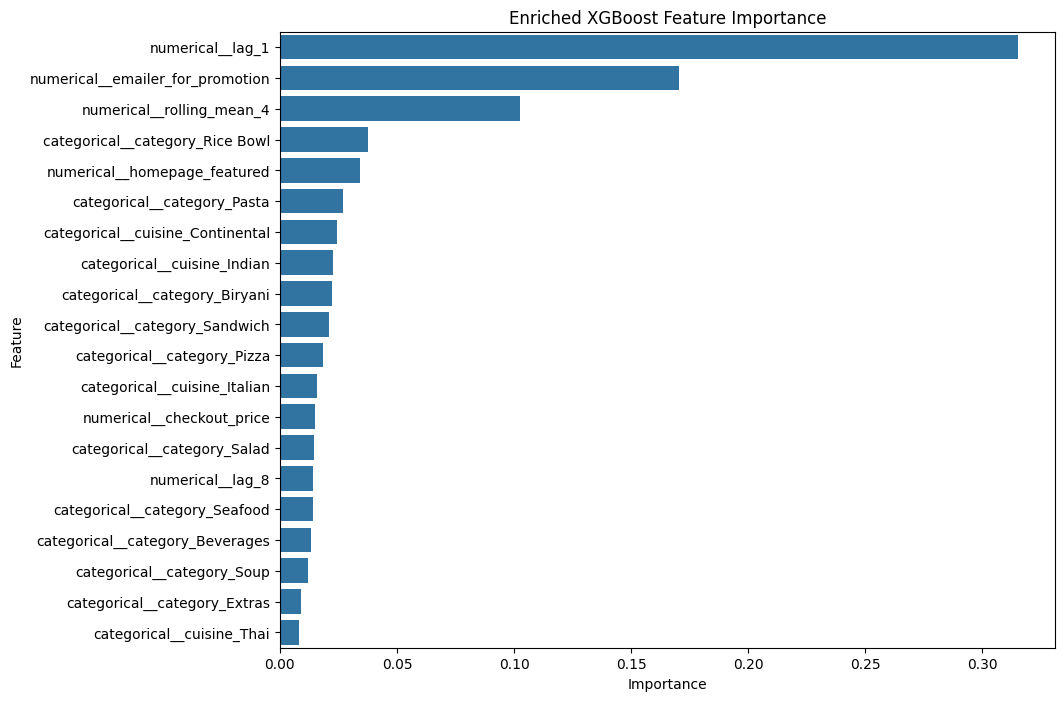

In [569]:
top_features = feature_importance.head(20)

plt.figure(figsize=(10, 8))

sns.barplot(
    data=top_features,
    x="importance",
    y="feature"
)

plt.title("Enriched XGBoost Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [570]:
# Aggregate one-hot importance
def get_original_feature(feature):
    feature = feature.replace("categorical__", "")
    feature = feature.replace("numerical__", "")

    for original in features_enriched:
        if feature == original or feature.startswith(original + "_"):
            return original

    return feature


feature_importance["original_feature"] = (
    feature_importance["feature"].apply(get_original_feature)
)

feature_group_importance = (
    feature_importance
    .groupby("original_feature")["importance"]
    .sum()
    .sort_values(ascending=False)
)

feature_group_importance

original_feature
lag_1                    0.315286
category                 0.214406
emailer_for_promotion    0.170503
rolling_mean_4           0.102662
cuisine                  0.070495
homepage_featured        0.034216
checkout_price           0.015000
center_type              0.014883
lag_8                    0.014255
base_price               0.007584
op_area                  0.007126
lag_2                    0.007077
rolling_std_4            0.005276
meal_id                  0.005267
lag_4                    0.005149
region_code              0.004528
center_id                0.003178
city_code                0.003108
Name: importance, dtype: float32

In [571]:
# Calculating importance of the original features
feature_group_importance = (
    feature_importance
    .groupby("original_feature")["importance"]
    .sum()
    .sort_values(ascending=False)
)

feature_group_importance

original_feature
lag_1                    0.315286
category                 0.214406
emailer_for_promotion    0.170503
rolling_mean_4           0.102662
cuisine                  0.070495
homepage_featured        0.034216
checkout_price           0.015000
center_type              0.014883
lag_8                    0.014255
base_price               0.007584
op_area                  0.007126
lag_2                    0.007077
rolling_std_4            0.005276
meal_id                  0.005267
lag_4                    0.005149
region_code              0.004528
center_id                0.003178
city_code                0.003108
Name: importance, dtype: float32

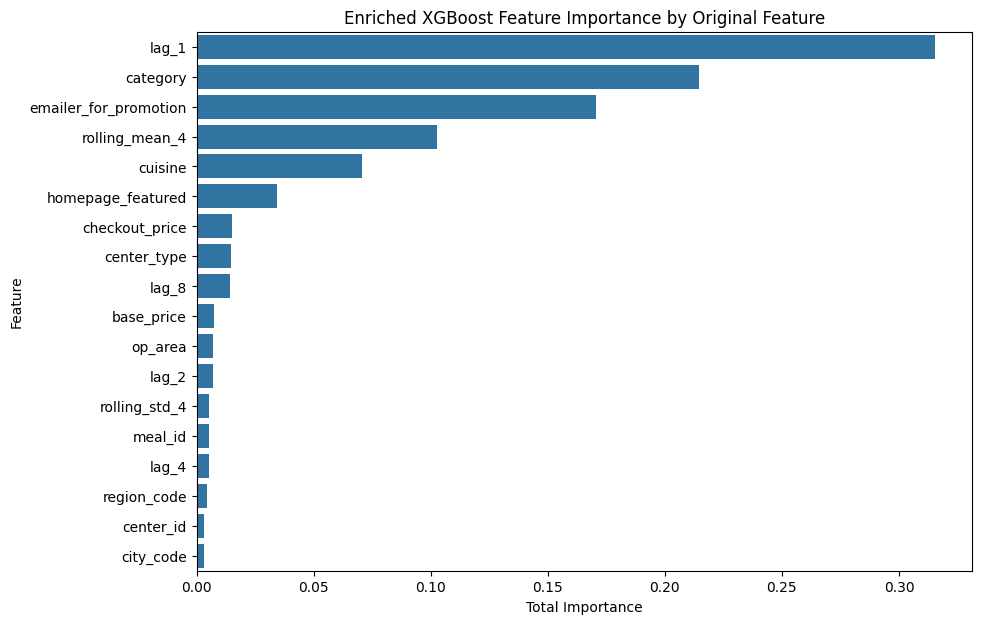

In [572]:
# Plotting original feature importance
plt.figure(figsize=(10, 7))

sns.barplot(
    x=feature_group_importance.values,
    y=feature_group_importance.index
)

plt.title("Enriched XGBoost Feature Importance by Original Feature")
plt.xlabel("Total Importance")
plt.ylabel("Feature")
plt.show()

In [573]:
reduced_features = [
    "category",
    "cuisine",
    "center_type",
    "checkout_price",
    "emailer_for_promotion",
    "homepage_featured",
    "lag_1",
    "lag_8",
    "rolling_mean_4"
]

In [574]:
categorical_reduced = [
    "category",
    "cuisine",
    "center_type"
]

numerical_reduced = [
    "checkout_price",
    "emailer_for_promotion",
    "homepage_featured",
    "lag_1",
    "lag_8",
    "rolling_mean_4"
]

In [575]:
# Create the preprocessor
reduced_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_reduced
        ),
        (
            "numerical",
            "passthrough",
            numerical_reduced
        )
    ]
)

In [576]:
# testing feature reduction
reduced_model = xgb.XGBRegressor(
    objective="reg:squarederror",
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

In [577]:
# Build the pipeline
reduced_pipeline = Pipeline(
    steps=[
        ("preprocessor", reduced_preprocessor),
        ("model", reduced_model)
    ]
)

In [578]:
# Creating the forecast-feature function
def create_forecast_features(history_df, forecast_df, forecast_week):

    result = forecast_df.copy()

    # Remove precomputed rolling features
    result = result.drop(
        columns=["rolling_mean_4", "rolling_std_4"],
        errors="ignore"
    )

    # Historical demand lookup
    demand_lookup = (
        history_df[
            ["center_id", "meal_id", "week", "num_orders"]
        ]
        .rename(columns={
            "week": "history_week",
            "num_orders": "history_orders"
        })
    )

    # Create exact lag features
    for lag in [1, 2, 4, 8]:

        result["lookup_week"] = forecast_week - lag

        result = result.merge(
            demand_lookup,
            left_on=[
                "center_id",
                "meal_id",
                "lookup_week"
            ],
            right_on=[
                "center_id",
                "meal_id",
                "history_week"
            ],
            how="left"
        )

        result[f"lag_{lag}"] = result["history_orders"]

        result = result.drop(
            columns=[
                "lookup_week",
                "history_week",
                "history_orders"
            ]
        )

    # Rolling features from previous historical observations
    rolling_stats = (
        history_df
        .sort_values(
            ["center_id", "meal_id", "week"]
        )
        .groupby(
            ["center_id", "meal_id"]
        )["num_orders"]
        .agg(
            rolling_mean_4=lambda x: x.tail(4).mean(),
            rolling_std_4=lambda x: x.tail(4).std()
        )
        .reset_index()
    )

    result = result.merge(
        rolling_stats,
        on=["center_id", "meal_id"],
        how="left"
    )

    return result

In [579]:
# Creating the recursive forecasting function
def recursive_enriched_forecast(
    model,
    train_df,
    valid_df,
    features
):

    history = train_df.copy()
    predictions = []

    for week in sorted(valid_df["week"].unique()):

        week_data = valid_df[
            valid_df["week"] == week
        ].copy()

        # Generate features using only available history
        week_features = create_forecast_features(
            history_df=history,
            forecast_df=week_data,
            forecast_week=week
        )

        # Select model features
        X_week = week_features[features]

        # Predict in log space
        log_predictions = model.predict(X_week)

        predictions_orders = np.expm1(log_predictions)

        predictions_orders = np.clip(
            predictions_orders,
            0,
            None
        )

        week_data["prediction"] = predictions_orders

        # Add predictions to history
        predicted_history = week_data.copy()

        predicted_history["num_orders"] = (
            predicted_history["prediction"]
        )

        predicted_history = predicted_history.drop(
            columns=["prediction"]
        )

        history = pd.concat(
            [history, predicted_history],
            ignore_index=True
        )

        predictions.append(week_data)

    return pd.concat(
        predictions,
        ignore_index=True
    )

In [580]:
# Testing the functions first
test_features = create_forecast_features(
    history_df=lag_features_enriched[
        lag_features_enriched["week"] <= 80
    ].copy(),

    forecast_df=lag_features_enriched[
        lag_features_enriched["week"] == 81
    ].copy(),

    forecast_week=81
)

print(test_features.columns.tolist())

['id', 'week', 'center_id', 'meal_id', 'checkout_price', 'base_price', 'emailer_for_promotion', 'homepage_featured', 'num_orders', 'category', 'cuisine', 'city_code', 'region_code', 'center_type', 'op_area', 'lag_1', 'lag_2', 'lag_4', 'lag_8', 'rolling_mean_4', 'rolling_std_4']


In [581]:
test_features[reduced_features].head()

,category,cuisine,center_type,checkout_price,emailer_for_promotion,homepage_featured,lag_1,lag_8,rolling_mean_4
0,Beverages,Italian,TYPE_B,182.42,0,0,757.0,810.0,810.25
1,Rice Bowl,Indian,TYPE_B,310.43,0,0,1364.0,1121.0,1134.50
2,Extras,Thai,TYPE_B,188.24,0,1,485.0,366.0,449.50
3,Beverages,Continental,TYPE_B,383.18,0,0,122.0,95.0,98.25
4,Pasta,Italian,TYPE_B,408.43,0,0,163.0,134.0,98.50


In [582]:
# training and evaluating the reduced model using the same 5-fold recursive CV setup

reduced_cv_results = []

for i, fold in enumerate(folds, start=1):

    train_fold = lag_features_enriched[
        lag_features_enriched["week"] <= fold["train_end"]
    ].copy()

    valid_fold = lag_features_enriched[
        lag_features_enriched["week"].between(
            fold["valid_start"],
            fold["valid_end"]
        )
    ].copy()

    # Training data
    X_train = train_fold[reduced_features]
    y_train = np.log1p(train_fold["num_orders"])

    # Train reduced model
    reduced_pipeline.fit(
        X_train,
        y_train
    )

    # Recursive forecast
    predictions_df = recursive_enriched_forecast(
        reduced_pipeline,
        train_fold,
        valid_fold,
        reduced_features
    )

    # Calculate RMSLE
    rmsle = np.sqrt(
        mean_squared_log_error(
            predictions_df["num_orders"],
            predictions_df["prediction"]
        )
    )

    reduced_cv_results.append({
        "fold": i,
        "rmsle": rmsle
    })

    print(
        f"Fold {i} RMSLE: {rmsle:.6f}"
    )


# Results
reduced_cv_results = pd.DataFrame(
    reduced_cv_results
)

mean_rmsle = reduced_cv_results["rmsle"].mean()
std_rmsle = reduced_cv_results["rmsle"].std()

print(f"\nMean CV RMSLE: {mean_rmsle:.6f}")
print(f"Std CV RMSLE: {std_rmsle:.6f}")

Fold 1 RMSLE: 0.536965
Fold 2 RMSLE: 0.572186
Fold 3 RMSLE: 0.583752
Fold 4 RMSLE: 0.587665
Fold 5 RMSLE: 0.540735

Mean CV RMSLE: 0.564261
Std CV RMSLE: 0.023922


### Before that i have to create a proper historical lag-feature function 

In [583]:
test_week = 81

test_data = train_enriched[
    train_enriched["week"] == test_week
].copy()

test_features = create_forecast_features(
    history_df=train_enriched[
        train_enriched["week"] <= 80
    ],
    forecast_df=test_data,
    forecast_week=test_week
)

print(test_features.columns.tolist())

['id', 'week', 'center_id', 'meal_id', 'checkout_price', 'base_price', 'emailer_for_promotion', 'homepage_featured', 'num_orders', 'category', 'cuisine', 'city_code', 'region_code', 'center_type', 'op_area', 'lag_1', 'lag_2', 'lag_4', 'lag_8', 'rolling_mean_4', 'rolling_std_4']


In [584]:
missing = [
    col for col in features_enriched
    if col not in test_features.columns
]

print("Missing columns:", missing)

Missing columns: []


In [585]:
# Rerun the current best model and save row-level predictions
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import root_mean_squared_log_error
import xgboost as xgb
import numpy as np
import pandas as pd

In [586]:
fold = folds[0]

train_fold = train_enriched[
    train_enriched["week"] <= fold["train_end"]
].copy()

valid_fold = train_enriched[
    (train_enriched["week"] >= fold["valid_start"]) &
    (train_enriched["week"] <= fold["valid_end"])
].copy()

history = train_fold.copy()

week = sorted(valid_fold["week"].unique())[0]

week_data = valid_fold[
    valid_fold["week"] == week
].copy()

week_features = create_forecast_features(
    history_df=history,
    forecast_df=week_data,
    forecast_week=week
)

print("WEEK:", week)

print("\nFEATURES CREATED:")
print(week_features.columns.tolist())

print("\nMODEL FEATURES:")
print(features_enriched)

print("\nMISSING:")
print([
    col for col in features_enriched
    if col not in week_features.columns
])

WEEK: 81

FEATURES CREATED:
['id', 'week', 'center_id', 'meal_id', 'checkout_price', 'base_price', 'emailer_for_promotion', 'homepage_featured', 'num_orders', 'category', 'cuisine', 'city_code', 'region_code', 'center_type', 'op_area', 'lag_1', 'lag_2', 'lag_4', 'lag_8', 'rolling_mean_4', 'rolling_std_4']

MODEL FEATURES:
['center_id', 'meal_id', 'category', 'cuisine', 'city_code', 'region_code', 'center_type', 'op_area', 'checkout_price', 'base_price', 'emailer_for_promotion', 'homepage_featured', 'lag_1', 'lag_2', 'lag_4', 'lag_8', 'rolling_mean_4', 'rolling_std_4']

MISSING:
[]


In [587]:
X_test = week_features[features_enriched]

print(X_test.shape)
print(X_test.columns.tolist())

(3204, 18)
['center_id', 'meal_id', 'category', 'cuisine', 'city_code', 'region_code', 'center_type', 'op_area', 'checkout_price', 'base_price', 'emailer_for_promotion', 'homepage_featured', 'lag_1', 'lag_2', 'lag_4', 'lag_8', 'rolling_mean_4', 'rolling_std_4']


In [588]:
print(X_test.dtypes)

center_id                  int64
meal_id                    int64
category                  object
cuisine                   object
city_code                  int64
region_code                int64
center_type               object
op_area                  float64
checkout_price           float64
base_price               float64
emailer_for_promotion      int64
homepage_featured          int64
lag_1                    float64
lag_2                    float64
lag_4                    float64
lag_8                    float64
rolling_mean_4           float64
rolling_std_4            float64
dtype: object


In [589]:
print(train_enriched.columns.tolist())

['id', 'week', 'center_id', 'meal_id', 'checkout_price', 'base_price', 'emailer_for_promotion', 'homepage_featured', 'num_orders', 'category', 'cuisine', 'city_code', 'region_code', 'center_type', 'op_area']


In [590]:
def create_training_lag_features(df):

    result = df.copy()

    # Make sure data is sorted chronologically
    result = result.sort_values(
        ["center_id", "meal_id", "week"]
    ).copy()

    # Exact calendar lags
    lookup = result[
        ["center_id", "meal_id", "week", "num_orders"]
    ].copy()

    for lag in [1, 2, 4, 8]:

        lag_lookup = lookup.rename(
            columns={
                "week": "previous_week",
                "num_orders": f"lag_{lag}"
            }
        )

        result["previous_week"] = result["week"] - lag

        result = result.merge(
            lag_lookup[
                [
                    "center_id",
                    "meal_id",
                    "previous_week",
                    f"lag_{lag}"
                ]
            ],
            on=[
                "center_id",
                "meal_id",
                "previous_week"
            ],
            how="left"
        )

        result = result.drop(
            columns=["previous_week"]
        )

    # Rolling features
    result["rolling_mean_4"] = (
        result
        .groupby(["center_id", "meal_id"])["num_orders"]
        .transform(
            lambda x:
            x.shift(1).rolling(4).mean()
        )
    )

    result["rolling_std_4"] = (
        result
        .groupby(["center_id", "meal_id"])["num_orders"]
        .transform(
            lambda x:
            x.shift(1).rolling(4).std()
        )
    )

    return result

In [591]:
# Create the training feature dataframe
train_features = create_training_lag_features(
    train_enriched
)

In [592]:
print(train_features.shape)
print(train_features.columns.tolist())

(456548, 21)
['id', 'week', 'center_id', 'meal_id', 'checkout_price', 'base_price', 'emailer_for_promotion', 'homepage_featured', 'num_orders', 'category', 'cuisine', 'city_code', 'region_code', 'center_type', 'op_area', 'lag_1', 'lag_2', 'lag_4', 'lag_8', 'rolling_mean_4', 'rolling_std_4']


In [593]:
required_lag_features = [
    "lag_1",
    "lag_2",
    "lag_4",
    "lag_8",
    "rolling_mean_4",
    "rolling_std_4"
]

print(
    train_features[required_lag_features].head(10)
)

    lag_1   lag_2   lag_4  lag_8  rolling_mean_4  rolling_std_4
0     NaN     NaN     NaN    NaN             NaN            NaN
1   865.0     NaN     NaN    NaN             NaN            NaN
2   782.0   865.0     NaN    NaN             NaN            NaN
3   851.0   782.0     NaN    NaN             NaN            NaN
4  1202.0   851.0   865.0    NaN          925.00     188.196706
5   958.0  1202.0   782.0    NaN          948.25     184.011549
6  1094.0   958.0   851.0    NaN         1026.25     153.675795
7  1513.0  1094.0  1202.0    NaN         1191.75     236.291310
8  1149.0  1513.0   958.0  865.0         1178.50     237.009845
9  1282.0  1149.0  1094.0  782.0         1259.50     186.519883


In [594]:
missing = [
    col
    for col in features_enriched
    if col not in train_features.columns
]

print("Missing:", missing)

Missing: []


In [595]:
train_features[required_lag_features].isna().mean() * 100

lag_1              5.497998
lag_2              6.409841
lag_4              8.001787
lag_8             10.884507
rolling_mean_4     3.148409
rolling_std_4      3.148409
dtype: float64

# Error analyisis

In [596]:
'''Current Enriched XGBoost
        │
        ▼
1. Error Breakdown
        │
        ├── Cold-start / sparse pairs?
        ├── High-demand orders?
        ├── Specific categories?
        ├── Specific centers?
        └── Forecast horizon / weeks?
        │
        ▼
2. Center × Meal historical statistics
        │
        ▼
3. Price-derived features
        │
        ▼
4. Meal / Center aggregate demand features
        │
        ▼
5. Recency / availability features
        │
        ▼
6. Hyperparameter tuning
        │
        ▼
7. CatBoost comparison
        │
        ▼
8. Ensemble if justified'''

'Current Enriched XGBoost\n        │\n        ▼\n1. Error Breakdown\n        │\n        ├── Cold-start / sparse pairs?\n        ├── High-demand orders?\n        ├── Specific categories?\n        ├── Specific centers?\n        └── Forecast horizon / weeks?\n        │\n        ▼\n2. Center × Meal historical statistics\n        │\n        ▼\n3. Price-derived features\n        │\n        ▼\n4. Meal / Center aggregate demand features\n        │\n        ▼\n5. Recency / availability features\n        │\n        ▼\n6. Hyperparameter tuning\n        │\n        ▼\n7. CatBoost comparison\n        │\n        ▼\n8. Ensemble if justified'

## Diagnostic_1

In [597]:
# ============================================
# ERROR ANALYSIS FOR CURRENT BEST XGBOOST
# ============================================

import numpy as np
import pandas as pd
import xgboost as xgb

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder


# --------------------------------------------
# 1. Create lag features for training data
# --------------------------------------------

def create_training_lag_features(df):

    result = df.copy()

    result = result.sort_values(
        ["center_id", "meal_id", "week"]
    ).copy()

    lookup = result[
        ["center_id", "meal_id", "week", "num_orders"]
    ].copy()

    for lag in [1, 2, 4, 8]:

        lag_lookup = lookup.rename(
            columns={
                "week": "previous_week",
                "num_orders": f"lag_{lag}"
            }
        )

        result["previous_week"] = result["week"] - lag

        result = result.merge(
            lag_lookup[
                [
                    "center_id",
                    "meal_id",
                    "previous_week",
                    f"lag_{lag}"
                ]
            ],
            on=[
                "center_id",
                "meal_id",
                "previous_week"
            ],
            how="left"
        )

        result = result.drop(
            columns=["previous_week"]
        )

    # Previous 4 observations only
    result["rolling_mean_4"] = (
        result
        .groupby(
            ["center_id", "meal_id"]
        )["num_orders"]
        .transform(
            lambda x:
            x.shift(1).rolling(4).mean()
        )
    )

    result["rolling_std_4"] = (
        result
        .groupby(
            ["center_id", "meal_id"]
        )["num_orders"]
        .transform(
            lambda x:
            x.shift(1).rolling(4).std()
        )
    )

    return result


# --------------------------------------------
# 2. Create training dataset with lag features
# --------------------------------------------

train_features = create_training_lag_features(
    train_enriched
)

print("Training feature dataframe:", train_features.shape)


# --------------------------------------------
# 3. Check required features
# --------------------------------------------

required_lag_features = [
    "lag_1",
    "lag_2",
    "lag_4",
    "lag_8",
    "rolling_mean_4",
    "rolling_std_4"
]

missing_features = [
    col
    for col in features_enriched
    if col not in train_features.columns
]

print("Missing model features:", missing_features)


# --------------------------------------------
# 4. Error-analysis CV
# --------------------------------------------

error_predictions = []


for fold_no, fold in enumerate(folds, start=1):

    print(f"\nStarting Fold {fold_no}")
    print(
        f"Train: weeks 1-{fold['train_end']} | "
        f"Validation: weeks "
        f"{fold['valid_start']}-{fold['valid_end']}"
    )

    # ----------------------------------------
    # Training data
    # ----------------------------------------

    train_fold = train_features[
        train_features["week"] <= fold["train_end"]
    ].copy()

    # ----------------------------------------
    # Validation data
    # ----------------------------------------

    valid_fold = train_enriched[
        (train_enriched["week"] >= fold["valid_start"]) &
        (train_enriched["week"] <= fold["valid_end"])
    ].copy()

    # ----------------------------------------
    # Model features
    # ----------------------------------------

    categorical_features = [
        "category",
        "cuisine",
        "center_type"
    ]

    numerical_features = [
        "center_id",
        "meal_id",
        "city_code",
        "region_code",
        "op_area",
        "checkout_price",
        "base_price",
        "emailer_for_promotion",
        "homepage_featured",
        "lag_1",
        "lag_2",
        "lag_4",
        "lag_8",
        "rolling_mean_4",
        "rolling_std_4"
    ]

    # ----------------------------------------
    # Preprocessor
    # ----------------------------------------

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "categorical",
                OneHotEncoder(
                    handle_unknown="ignore"
                ),
                categorical_features
            ),
            (
                "numerical",
                "passthrough",
                numerical_features
            )
        ]
    )

    # ----------------------------------------
    # XGBoost
    # ----------------------------------------

    model = xgb.XGBRegressor(
        objective="reg:squarederror",
        n_estimators=500,
        learning_rate=0.05,
        max_depth=8,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    # ----------------------------------------
    # Train model
    # ----------------------------------------

    X_train = train_fold[features_enriched]

    y_train = np.log1p(
        train_fold["num_orders"]
    )

    pipeline.fit(
        X_train,
        y_train
    )

    print("Model trained.")

    # ----------------------------------------
    # Recursive forecasting history
    # ----------------------------------------

    history = train_fold.copy()

    # ----------------------------------------
    # Forecast each validation week
    # ----------------------------------------

    for week in sorted(
        valid_fold["week"].unique()
    ):

        week_data = valid_fold[
            valid_fold["week"] == week
        ].copy()

        # Generate features using ONLY
        # information available before this week
        week_features = create_forecast_features(
            history_df=history,
            forecast_df=week_data,
            forecast_week=week
        )

        # ------------------------------------
        # Missing-lag diagnostics
        # ------------------------------------

        week_features["lag_1_missing"] = (
            week_features["lag_1"].isna()
        )

        week_features["lag_8_missing"] = (
            week_features["lag_8"].isna()
        )

        # ------------------------------------
        # Predict
        # ------------------------------------

        X_week = week_features[
            features_enriched
        ]

        log_predictions = pipeline.predict(
            X_week
        )

        predictions = np.expm1(
            log_predictions
        )

        predictions = np.clip(
            predictions,
            0,
            None
        )

        # ------------------------------------
        # Store prediction diagnostics
        # ------------------------------------

        result = week_features[
            [
                "week",
                "center_id",
                "meal_id",
                "category",
                "lag_1",
                "lag_8",
                "lag_1_missing",
                "lag_8_missing"
            ]
        ].copy()

        result["actual"] = (
            week_data["num_orders"].values
        )

        result["prediction"] = predictions

        # Log-space error
        result["log_error"] = (
            np.log1p(result["actual"])
            -
            np.log1p(result["prediction"])
        )

        result["squared_log_error"] = (
            result["log_error"] ** 2
        )

        result["absolute_log_error"] = (
            result["log_error"].abs()
        )

        result["fold"] = fold_no

        error_predictions.append(
            result
        )

        # ------------------------------------
        # Recursive update
        # ------------------------------------

        predicted_history = week_data.copy()

        predicted_history["num_orders"] = (
            predictions
        )

        history = pd.concat(
            [
                history,
                predicted_history
            ],
            ignore_index=True
        )

    print(f"Fold {fold_no} completed.")


# --------------------------------------------
# 5. Combine all predictions
# --------------------------------------------

error_df = pd.concat(
    error_predictions,
    ignore_index=True
)

print("\nError dataframe shape:")
print(error_df.shape)

print("\nFirst rows:")
display(error_df.head())

Training feature dataframe: (456548, 21)
Missing model features: []

Starting Fold 1
Train: weeks 1-80 | Validation: weeks 81-90
Model trained.
Fold 1 completed.

Starting Fold 2
Train: weeks 1-90 | Validation: weeks 91-100
Model trained.
Fold 2 completed.

Starting Fold 3
Train: weeks 1-100 | Validation: weeks 101-110
Model trained.
Fold 3 completed.

Starting Fold 4
Train: weeks 1-110 | Validation: weeks 111-120
Model trained.
Fold 4 completed.

Starting Fold 5
Train: weeks 1-120 | Validation: weeks 121-130
Model trained.
Fold 5 completed.

Error dataframe shape:
(163073, 14)

First rows:


,week,center_id,meal_id,category,lag_1,lag_8,lag_1_missing,lag_8_missing,actual,prediction,log_error,squared_log_error,absolute_log_error,fold
0,81,10,1062,Beverages,757.0,810.0,False,False,824,721.027832,0.133320,0.017774,0.133320,1
1,81,10,1109,Rice Bowl,1364.0,1121.0,False,False,1066,1078.818848,-0.011942,0.000143,0.011942,1
2,81,10,1198,Extras,485.0,366.0,False,False,324,522.238770,-0.476213,0.226779,0.476213,1
3,81,10,1207,Beverages,122.0,95.0,False,False,203,114.733078,0.566833,0.321300,0.566833,1
4,81,10,1216,Pasta,163.0,134.0,False,False,162,110.987381,0.375364,0.140898,0.375364,1


In [598]:
lag1_error = (
    error_df
    .groupby("lag_1_missing")
    .agg(
        rows=("squared_log_error", "size"),
        rmsle=(
            "squared_log_error",
            lambda x: np.sqrt(x.mean())
        )
    )
)

lag1_error

,rows,rmsle
lag_1_missing,,
False,155429,0.521724
True,7644,0.547250


In [599]:
'''Current model
     │
     ├── lag_1 available      → RMSLE 0.5217
     │
     └── lag_1 missing        → RMSLE 0.5473
                                  ↑
                           real problem,
                           but relatively small
So when the previous week's demand is unavailable, the model's RMSLE rises from 0.5217 → 0.5473, about 4.9% higher.

That confirms missing recent history is a real weakness, but it is not the main reason we're stuck around 0.5226.
Only ~4.7% of validation rows have missing lag_1                           
'''

"Current model\n     │\n     ├── lag_1 available      → RMSLE 0.5217\n     │\n     └── lag_1 missing        → RMSLE 0.5473\n                                  ↑\n                           real problem,\n                           but relatively small\nSo when the previous week's demand is unavailable, the model's RMSLE rises from 0.5217 → 0.5473, about 4.9% higher.\n\nThat confirms missing recent history is a real weakness, but it is not the main reason we're stuck around 0.5226.\nOnly ~4.7% of validation rows have missing lag_1                           \n"

## Diagnostic_2

In [600]:
# how much does error depend on demand size?
error_df["demand_bucket"] = pd.cut(
    error_df["actual"],
    bins=[0, 50, 100, 250, 500, 1000, np.inf],
    labels=[
        "0-50",
        "51-100",
        "101-250",
        "251-500",
        "501-1000",
        "1000+"
    ]
)

demand_error = (
    error_df
    .groupby("demand_bucket", observed=True)
    .agg(
        rows=("squared_log_error", "size"),
        rmsle=(
            "squared_log_error",
            lambda x: np.sqrt(x.mean())
        ),
        mean_actual=("actual", "mean"),
        mean_prediction=("prediction", "mean")
    )
)

demand_error

,rows,rmsle,mean_actual,mean_prediction
demand_bucket,,,,
0-50,36013,0.654730,26.621220,41.326561
51-100,31261,0.539768,72.390039,76.137390
101-250,42828,0.497148,165.699309,164.300278
251-500,30853,0.419715,354.425696,323.233856
501-1000,16067,0.421721,686.502645,589.679993
1000+,6051,0.440293,1625.301603,1320.110840


* The model struggles substantially more with low-demand meals and underpredicting high demand.

In [601]:
# Finding out which meals/categories are responsible for the low-demand error
low_demand_error = (
    error_df[error_df["actual"] <= 100]
    .groupby("category")
    .agg(
        rows=("squared_log_error", "size"),
        rmsle=(
            "squared_log_error",
            lambda x: np.sqrt(x.mean())
        ),
        mean_actual=("actual", "mean"),
        mean_prediction=("prediction", "mean")
    )
    .sort_values("rmsle", ascending=False)
)

low_demand_error

,rows,rmsle,mean_actual,mean_prediction
category,,,,
Salad,702,0.925201,69.901709,153.245255
Sandwich,779,0.831701,67.428755,129.671188
Rice Bowl,482,0.825264,72.236515,143.943130
Starters,4307,0.714060,53.472254,79.641701
Pizza,3503,0.710681,61.082215,95.749916
Extras,952,0.661220,62.089286,99.023476
Beverages,14000,0.626267,53.617571,70.430153
Seafood,7155,0.594316,41.563103,45.195599
Other Snacks,4866,0.572872,49.848541,59.889385


* For the salad, sandwich, rice bowl:
The model is roughly predicting **2× the actual demand** in these categories within the low-demand subset.

whereas Seafood is much better

## Diagnostic_3

In [602]:
# Are these bad low-demand predictions concentrated in a small number of Center × Meal combinations?
pair_error = (
    error_df
    .groupby(["center_id", "meal_id", "category"])
    .agg(
        rows=("squared_log_error", "size"),
        rmsle=(
            "squared_log_error",
            lambda x: np.sqrt(x.mean())
        ),
        mean_actual=("actual", "mean"),
        mean_prediction=("prediction", "mean")
    )
    .query("rows >= 20")
    .sort_values("rmsle", ascending=False)
)

pair_error.head(20)

,,,rows,rmsle,mean_actual,mean_prediction
center_id,meal_id,category,,,,
86,1445,Seafood,34,0.977477,35.411765,58.466606
99,1878,Starters,50,0.972392,93.820000,127.174179
23,1878,Starters,38,0.968678,112.263158,122.584938
104,1878,Starters,49,0.911497,156.122449,211.800323
101,2444,Seafood,39,0.885709,118.846154,107.210564
72,1878,Starters,43,0.879898,83.767442,68.384438
113,1445,Seafood,29,0.877922,33.482759,69.062920
80,1878,Starters,47,0.877587,86.765957,81.220894
104,2577,Starters,46,0.860892,66.608696,142.173248


In [603]:
pair_error.shape

(3448, 4)

# Feature Engineering

### Feature Engineering: Pair-Level Demand Baseline

To capture the typical demand behavior of each **Center × Meal pair**, we add two features:

- **`pair_mean`**: historical average demand for the pair, representing its typical demand level.
- **`pair_std`**: historical standard deviation of demand, representing its demand volatility.

We add only these two features to keep the experiment targeted and measure their impact clearly.

In [604]:
# Create the pair-statistics function
def add_pair_history_features(
    history_df,
    forecast_df
):

    result = forecast_df.copy()

    pair_stats = (
        history_df
        .groupby(
            ["center_id", "meal_id"]
        )["num_orders"]
        .agg(
            pair_mean="mean",
            pair_std="std"
        )
        .reset_index()
    )

    result = result.merge(
        pair_stats,
        on=["center_id", "meal_id"],
        how="left"
    )

    return result

In [605]:
# Test it on week 81
history_test = train_enriched[
    train_enriched["week"] <= 80
].copy()

forecast_test = train_enriched[
    train_enriched["week"] == 81
].copy()

test_pair_features = add_pair_history_features(
    history_df=history_test,
    forecast_df=forecast_test
)

print(
    test_pair_features[
        [
            "center_id",
            "meal_id",
            "pair_mean",
            "pair_std"
        ]
    ].head(10)
)

   center_id  meal_id    pair_mean    pair_std
0         10     1062   959.600000  276.606864
1         10     1109  1498.350000  512.803170
2         10     1198   273.362500   99.382810
3         10     1207   215.531646  210.798837
4         10     1216   132.884615   56.482150
5         10     1230   167.587500  205.026253
6         10     1247    36.333333   20.607442
7         10     1248   232.687500  153.120668
8         10     1311   472.025000  155.182455
9         10     1438    62.746835   29.611358


In [606]:
# Replacing current create_forecast_features() with this:

def create_forecast_features(
    history_df,
    forecast_df,
    forecast_week
):

    result = forecast_df.copy()

    # Remove old generated features
    result = result.drop(
        columns=[
            "lag_1",
            "lag_2",
            "lag_4",
            "lag_8",
            "rolling_mean_4",
            "rolling_std_4",
            "pair_mean",
            "pair_std"
        ],
        errors="ignore"
    )

    # ----------------------------------------
    # Exact calendar lags
    # ----------------------------------------

    demand_lookup = (
        history_df[
            [
                "center_id",
                "meal_id",
                "week",
                "num_orders"
            ]
        ]
        .rename(
            columns={
                "week": "history_week",
                "num_orders": "history_orders"
            }
        )
    )

    for lag in [1, 2, 4, 8]:

        result["lookup_week"] = (
            forecast_week - lag
        )

        result = result.merge(
            demand_lookup,
            left_on=[
                "center_id",
                "meal_id",
                "lookup_week"
            ],
            right_on=[
                "center_id",
                "meal_id",
                "history_week"
            ],
            how="left"
        )

        result[f"lag_{lag}"] = (
            result["history_orders"]
        )

        result = result.drop(
            columns=[
                "lookup_week",
                "history_week",
                "history_orders"
            ]
        )

    # ----------------------------------------
    # Rolling features
    # ----------------------------------------

    rolling_stats = (
        history_df
        .sort_values(
            [
                "center_id",
                "meal_id",
                "week"
            ]
        )
        .groupby(
            ["center_id", "meal_id"]
        )["num_orders"]
        .agg(
            rolling_mean_4=lambda x:
                x.tail(4).mean(),

            rolling_std_4=lambda x:
                x.tail(4).std()
        )
        .reset_index()
    )

    result = result.merge(
        rolling_stats,
        on=[
            "center_id",
            "meal_id"
        ],
        how="left"
    )

    # ----------------------------------------
    # Center × Meal historical statistics
    # ----------------------------------------

    pair_stats = (
        history_df
        .groupby(
            ["center_id", "meal_id"]
        )["num_orders"]
        .agg(
            pair_mean="mean",
            pair_std="std"
        )
        .reset_index()
    )

    result = result.merge(
        pair_stats,
        on=[
            "center_id",
            "meal_id"
        ],
        how="left"
    )

    return result

In [607]:
# Testing the complete feature generator
test_features = create_forecast_features(
    history_df=history_test,
    forecast_df=forecast_test,
    forecast_week=81
)

new_features = [
    "lag_1",
    "lag_2",
    "lag_4",
    "lag_8",
    "rolling_mean_4",
    "rolling_std_4",
    "pair_mean",
    "pair_std"
]

print(
    test_features[
        new_features
    ].head(10)
)

    lag_1   lag_2  lag_4   lag_8  rolling_mean_4  rolling_std_4    pair_mean  \
0   757.0  1012.0  838.0   810.0          810.25     158.506309   959.600000   
1  1364.0  1215.0  837.0  1121.0         1134.50     221.970719  1498.350000   
2   485.0   338.0  501.0   366.0          449.50      75.155395   273.362500   
3   122.0   107.0   42.0    95.0           98.25      38.160844   215.531646   
4   163.0    13.0  149.0   134.0           98.50      70.453294   132.884615   
5    95.0    28.0   42.0    68.0           68.00      38.841558   167.587500   
6    28.0    54.0   41.0    27.0           34.50      16.782928    36.333333   
7   323.0   244.0  338.0   242.0          276.75      64.680626   232.687500   
8   581.0   607.0  622.0   701.0          604.75      17.173138   472.025000   
9    53.0    40.0   80.0    53.0           56.75      16.760569    62.746835   

     pair_std  
0  276.606864  
1  512.803170  
2   99.382810  
3  210.798837  
4   56.482150  
5  205.026253  
6   20.

In [608]:
print(
    "Missing:",
    [
        col
        for col in new_features
        if col not in test_features.columns
    ]
)

Missing: []


In [609]:
print(
    test_features[
        ["pair_mean", "pair_std"]
    ].isna().mean() * 100
)

pair_mean    0.0
pair_std     0.0
dtype: float64


In [610]:
test_features[
    [
        "center_id",
        "meal_id",
        "category",
        "pair_mean",
        "pair_std"
    ]
].head(10)

,center_id,meal_id,category,pair_mean,pair_std
0,10,1062,Beverages,959.600000,276.606864
1,10,1109,Rice Bowl,1498.350000,512.803170
2,10,1198,Extras,273.362500,99.382810
3,10,1207,Beverages,215.531646,210.798837
4,10,1216,Pasta,132.884615,56.482150
5,10,1230,Beverages,167.587500,205.026253
6,10,1247,Biryani,36.333333,20.607442
7,10,1248,Beverages,232.687500,153.120668
8,10,1311,Extras,472.025000,155.182455
9,10,1438,Soup,62.746835,29.611358


In [611]:
test_features[
    ["pair_mean", "pair_std"]
].describe()

,pair_mean,pair_std
count,3204.000000,3204.000000
mean,266.985913,180.987116
std,288.469538,243.011316
min,13.500000,0.707107
25%,69.499205,47.266912
50%,163.820724,102.997050
75%,362.633726,208.111586
max,2295.450000,3471.291751


In [612]:
# Test the final forecast feature generator on validation week 81

history_test = train_enriched[
    train_enriched["week"] <= 80
].copy()

forecast_test = train_enriched[
    train_enriched["week"] == 81
].copy()

test_features = create_forecast_features(
    history_df=history_test,
    forecast_df=forecast_test,
    forecast_week=81
)

required_features = [
    "lag_1", "lag_2", "lag_4", "lag_8",
    "rolling_mean_4", "rolling_std_4",
    "pair_mean", "pair_std"
]

missing = [
    col for col in required_features
    if col not in test_features.columns
]

print("Missing features:", missing)
print("Test shape:", test_features.shape)
print(test_features[required_features].head())

Missing features: []
Test shape: (3204, 23)
    lag_1   lag_2  lag_4   lag_8  rolling_mean_4  rolling_std_4    pair_mean  \
0   757.0  1012.0  838.0   810.0          810.25     158.506309   959.600000   
1  1364.0  1215.0  837.0  1121.0         1134.50     221.970719  1498.350000   
2   485.0   338.0  501.0   366.0          449.50      75.155395   273.362500   
3   122.0   107.0   42.0    95.0           98.25      38.160844   215.531646   
4   163.0    13.0  149.0   134.0           98.50      70.453294   132.884615   

     pair_std  
0  276.606864  
1  512.803170  
2   99.382810  
3  210.798837  
4   56.482150  


In [613]:
features_pair = features_enriched + [
    "pair_mean",
    "pair_std"
]

## Enriched XGBoost(Centre x Meal Feature)

In [614]:
# ============================================
# CENTER × MEAL HISTORY FEATURE EXPERIMENT
# ============================================

pair_cv_results = []

experiment_features = features_enriched + [
    "pair_mean",
    "pair_std"
]


for fold_no, fold in enumerate(folds, start=1):

    print(f"\nStarting Fold {fold_no}")

    # ----------------------------------------
    # Training data
    # ----------------------------------------

    train_fold = train_features[
        train_features["week"] <= fold["train_end"]
    ].copy()

    # ----------------------------------------
    # Add Center × Meal historical statistics
    # ----------------------------------------

    pair_stats_train = (
        train_fold
        .groupby(
            ["center_id", "meal_id"]
        )["num_orders"]
        .agg(
            pair_mean="mean",
            pair_std="std"
        )
        .reset_index()
    )

    train_fold = train_fold.merge(
        pair_stats_train,
        on=["center_id", "meal_id"],
        how="left"
    )

    # ----------------------------------------
    # Validation data
    # ----------------------------------------

    valid_fold = train_enriched[
        (train_enriched["week"] >= fold["valid_start"]) &
        (train_enriched["week"] <= fold["valid_end"])
    ].copy()

    # ----------------------------------------
    # Preprocessor
    # ----------------------------------------

    categorical_features = [
        "category",
        "cuisine",
        "center_type"
    ]

    numerical_features = [
        "center_id",
        "meal_id",
        "city_code",
        "region_code",
        "op_area",
        "checkout_price",
        "base_price",
        "emailer_for_promotion",
        "homepage_featured",
        "lag_1",
        "lag_2",
        "lag_4",
        "lag_8",
        "rolling_mean_4",
        "rolling_std_4",
        "pair_mean",
        "pair_std"
    ]

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "categorical",
                OneHotEncoder(
                    handle_unknown="ignore"
                ),
                categorical_features
            ),
            (
                "numerical",
                "passthrough",
                numerical_features
            )
        ]
    )

    # ----------------------------------------
    # Same XGBoost model
    # ----------------------------------------

    model = xgb.XGBRegressor(
        objective="reg:squarederror",
        n_estimators=500,
        learning_rate=0.05,
        max_depth=8,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    # ----------------------------------------
    # Train
    # ----------------------------------------

    X_train = train_fold[
        experiment_features
    ]

    y_train = np.log1p(
        train_fold["num_orders"]
    )

    pipeline.fit(
        X_train,
        y_train
    )

    print("Model trained.")

    # ----------------------------------------
    # Recursive validation
    # ----------------------------------------

    history = train_fold.copy()

    fold_predictions = []
    fold_actuals = []

    for week in sorted(
        valid_fold["week"].unique()
    ):

        week_data = valid_fold[
            valid_fold["week"] == week
        ].copy()

        # ------------------------------------
        # Existing lag/rolling features
        # ------------------------------------

        week_features = create_forecast_features(
            history_df=history,
            forecast_df=week_data,
            forecast_week=week
        )



        # ------------------------------------
        # Check features once
        # ------------------------------------

        if week == sorted(
            valid_fold["week"].unique()
        )[0]:

            missing = [
                col
                for col in experiment_features
                if col not in week_features.columns
            ]

            print(
                "Missing validation features:",
                missing
            )

        # ------------------------------------
        # Predict
        # ------------------------------------

        X_week = week_features[
            experiment_features
        ]

        log_predictions = pipeline.predict(
            X_week
        )

        predictions = np.expm1(
            log_predictions
        )

        predictions = np.clip(
            predictions,
            0,
            None
        )

        actuals = week_data[
            "num_orders"
        ].values

        fold_predictions.extend(
            predictions
        )

        fold_actuals.extend(
            actuals
        )

        # ------------------------------------
        # Recursive update
        # ------------------------------------

        predicted_history = week_data.copy()

        predicted_history[
            "num_orders"
        ] = predictions

        history = pd.concat(
            [
                history,
                predicted_history
            ],
            ignore_index=True
        )

    # ----------------------------------------
    # Fold RMSLE
    # ----------------------------------------

    fold_rmsle = np.sqrt(
        np.mean(
            (
                np.log1p(fold_actuals)
                -
                np.log1p(fold_predictions)
            ) ** 2
        )
    )

    pair_cv_results.append(
        fold_rmsle
    )

    print(
        f"Fold {fold_no} RMSLE: "
        f"{fold_rmsle:.6f}"
    )


# ============================================
# Final results
# ============================================

pair_mean_rmsle = np.mean(
    pair_cv_results
)

pair_std_rmsle = np.std(
    pair_cv_results
)

baseline_rmsle = 0.522641

improvement = (
    (baseline_rmsle - pair_mean_rmsle)
    / baseline_rmsle
) * 100

print("\n==============================")
print("PAIR HISTORY FEATURE RESULTS")
print("==============================")

print(
    "Fold RMSLE:",
    [round(x, 6) for x in pair_cv_results]
)

print(
    f"Mean RMSLE: {pair_mean_rmsle:.6f}"
)

print(
    f"Std RMSLE: {pair_std_rmsle:.6f}"
)

print(
    f"Change vs baseline: {improvement:.2f}%"
)


Starting Fold 1
Model trained.
Missing validation features: []
Fold 1 RMSLE: 0.490278

Starting Fold 2
Model trained.
Missing validation features: []
Fold 2 RMSLE: 0.518308

Starting Fold 3
Model trained.
Missing validation features: []
Fold 3 RMSLE: 0.541103

Starting Fold 4
Model trained.
Missing validation features: []
Fold 4 RMSLE: 0.530579

Starting Fold 5
Model trained.
Missing validation features: []
Fold 5 RMSLE: 0.494990

PAIR HISTORY FEATURE RESULTS
Fold RMSLE: [np.float64(0.490278), np.float64(0.518308), np.float64(0.541103), np.float64(0.530579), np.float64(0.49499)]
Mean RMSLE: 0.515052
Std RMSLE: 0.019731
Change vs baseline: 1.45%


## Time + trend features

In [615]:
def create_forecast_features_v2(
    history_df,
    forecast_df,
    forecast_week
):
    result = forecast_df.copy()

    # Remove generated features if already present
    result = result.drop(
        columns=[
            "lag_1",
            "lag_2",
            "lag_4",
            "lag_8",
            "rolling_mean_4",
            "rolling_std_4",
            "pair_mean",
            "pair_std",
            "recent_mean_8",
            "recent_std_8",
            "recent_mean_12",
            "pair_age"
        ],
        errors="ignore"
    )

    # -----------------------------
    # Exact calendar lags
    # -----------------------------

    demand_lookup = (
        history_df[
            ["center_id", "meal_id", "week", "num_orders"]
        ]
        .rename(
            columns={
                "week": "history_week",
                "num_orders": "history_orders"
            }
        )
    )

    for lag in [1, 2, 4, 8]:

        result["lookup_week"] = forecast_week - lag

        result = result.merge(
            demand_lookup,
            left_on=[
                "center_id",
                "meal_id",
                "lookup_week"
            ],
            right_on=[
                "center_id",
                "meal_id",
                "history_week"
            ],
            how="left"
        )

        result[f"lag_{lag}"] = result["history_orders"]

        result = result.drop(
            columns=[
                "lookup_week",
                "history_week",
                "history_orders"
            ]
        )

    # -----------------------------
    # Historical rolling features
    # -----------------------------

    history_sorted = history_df.sort_values(
        ["center_id", "meal_id", "week"]
    )

    rolling_stats = (
        history_sorted
        .groupby(
            ["center_id", "meal_id"]
        )["num_orders"]
        .agg(
            rolling_mean_4=lambda x: x.tail(4).mean(),
            rolling_std_4=lambda x: x.tail(4).std(),

            recent_mean_8=lambda x: x.tail(8).mean(),
            recent_std_8=lambda x: x.tail(8).std(),

            recent_mean_12=lambda x: x.tail(12).mean()
        )
        .reset_index()
    )

    result = result.merge(
        rolling_stats,
        on=["center_id", "meal_id"],
        how="left"
    )

    # -----------------------------
    # Center × Meal history
    # -----------------------------

    pair_stats = (
        history_df
        .groupby(
            ["center_id", "meal_id"]
        )["num_orders"]
        .agg(
            pair_mean="mean",
            pair_std="std"
        )
        .reset_index()
    )

    result = result.merge(
        pair_stats,
        on=["center_id", "meal_id"],
        how="left"
    )

    # -----------------------------
    # Pair age
    # -----------------------------

    pair_age = (
        history_df
        .groupby(
            ["center_id", "meal_id"]
        )["week"]
        .agg(
            pair_first_week="min"
        )
        .reset_index()
    )

    result = result.merge(
        pair_age,
        on=["center_id", "meal_id"],
        how="left"
    )

    result["pair_age"] = (
        forecast_week
        - result["pair_first_week"]
    )

    result = result.drop(
        columns=["pair_first_week"]
    )

    # -----------------------------
    # Time representation
    # -----------------------------

    result["week_sin"] = np.sin(
        2 * np.pi * result["week"] / 52
    )

    result["week_cos"] = np.cos(
        2 * np.pi * result["week"] / 52
    )

    return result

In [616]:
test_v2 = create_forecast_features_v2(
    history_df=train_enriched[
        train_enriched["week"] <= 80
    ].copy(),

    forecast_df=train_enriched[
        train_enriched["week"] == 81
    ].copy(),

    forecast_week=81
)

new_features = [
    "lag_1",
    "lag_2",
    "lag_4",
    "lag_8",
    "rolling_mean_4",
    "rolling_std_4",
    "pair_mean",
    "pair_std",
    "recent_mean_8",
    "recent_std_8",
    "recent_mean_12",
    "pair_age",
    "week_sin",
    "week_cos"
]

print("Missing:", [
    col for col in new_features
    if col not in test_v2.columns
])

print(test_v2[new_features].head())

Missing: []
    lag_1   lag_2  lag_4   lag_8  rolling_mean_4  rolling_std_4    pair_mean  \
0   757.0  1012.0  838.0   810.0          810.25     158.506309   959.600000   
1  1364.0  1215.0  837.0  1121.0         1134.50     221.970719  1498.350000   
2   485.0   338.0  501.0   366.0          449.50      75.155395   273.362500   
3   122.0   107.0   42.0    95.0           98.25      38.160844   215.531646   
4   163.0    13.0  149.0   134.0           98.50      70.453294   132.884615   

     pair_std  recent_mean_8  recent_std_8  recent_mean_12  pair_age  \
0  276.606864        842.250    144.917464      793.583333        80   
1  512.803170       1222.250    205.627090     1291.833333        80   
2   99.382810        390.625     88.691983      346.916667        80   
3  210.798837        106.625     28.992302      117.166667        80   
4   56.482150        105.250     50.592913      116.250000        80   

   week_sin  week_cos  
0 -0.354605 -0.935016  
1 -0.354605 -0.935016  
2 

In [617]:
# ============================================
# TIME + TREND FEATURE EXPERIMENT
# ============================================

cv_results_v2 = []

experiment_features_v2 = features_enriched + [
    "pair_mean",
    "pair_std",
    "recent_mean_8",
    "recent_std_8",
    "recent_mean_12",
    "pair_age",
    "week_sin",
    "week_cos"
]

for fold_no, fold in enumerate(folds, start=1):

    print(f"\nStarting Fold {fold_no}")

    # ----------------------------------------
    # Training data
    # ----------------------------------------

    train_fold = train_features[
        train_features["week"] <= fold["train_end"]
    ].copy()

    # ----------------------------------------
    # Add pair history features to training
    # ----------------------------------------

    pair_stats_train = (
        train_fold
        .groupby(
            ["center_id", "meal_id"]
        )["num_orders"]
        .agg(
            pair_mean="mean",
            pair_std="std"
        )
        .reset_index()
    )

    train_fold = train_fold.merge(
        pair_stats_train,
        on=["center_id", "meal_id"],
        how="left"
    )

    # ----------------------------------------
    # Add time/trend features to training
    # ----------------------------------------

    history_sorted = train_fold.sort_values(
        ["center_id", "meal_id", "week"]
    )

    rolling_stats_train = (
        history_sorted
        .groupby(
            ["center_id", "meal_id"]
        )["num_orders"]
        .agg(
            recent_mean_8=lambda x: x.tail(8).mean(),
            recent_std_8=lambda x: x.tail(8).std(),
            recent_mean_12=lambda x: x.tail(12).mean()
        )
        .reset_index()
    )

    train_fold = train_fold.merge(
        rolling_stats_train,
        on=["center_id", "meal_id"],
        how="left"
    )

    pair_age_train = (
        train_fold
        .groupby(
            ["center_id", "meal_id"]
        )["week"]
        .transform("min")
    )

    train_fold["pair_age"] = (
        train_fold["week"] - pair_age_train
    )

    train_fold["week_sin"] = np.sin(
        2 * np.pi * train_fold["week"] / 52
    )

    train_fold["week_cos"] = np.cos(
        2 * np.pi * train_fold["week"] / 52
    )

    # ----------------------------------------
    # Validation data
    # ----------------------------------------

    valid_fold = train_enriched[
        (train_enriched["week"] >= fold["valid_start"]) &
        (train_enriched["week"] <= fold["valid_end"])
    ].copy()

    # ----------------------------------------
    # Preprocessor
    # ----------------------------------------

    categorical_features = [
        "category",
        "cuisine",
        "center_type"
    ]

    numerical_features = [
        "center_id",
        "meal_id",
        "city_code",
        "region_code",
        "op_area",
        "checkout_price",
        "base_price",
        "emailer_for_promotion",
        "homepage_featured",
        "lag_1",
        "lag_2",
        "lag_4",
        "lag_8",
        "rolling_mean_4",
        "rolling_std_4",
        "pair_mean",
        "pair_std",
        "recent_mean_8",
        "recent_std_8",
        "recent_mean_12",
        "pair_age",
        "week_sin",
        "week_cos"
    ]

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "categorical",
                OneHotEncoder(
                    handle_unknown="ignore"
                ),
                categorical_features
            ),
            (
                "numerical",
                "passthrough",
                numerical_features
            )
        ]
    )

    # ----------------------------------------
    # XGBoost
    # ----------------------------------------

    model = xgb.XGBRegressor(
        objective="reg:squarederror",
        n_estimators=500,
        learning_rate=0.05,
        max_depth=8,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    # ----------------------------------------
    # Train
    # ----------------------------------------

    X_train = train_fold[
        experiment_features_v2
    ]

    y_train = np.log1p(
        train_fold["num_orders"]
    )

    pipeline.fit(
        X_train,
        y_train
    )

    print("Model trained.")

    # ----------------------------------------
    # Recursive validation
    # ----------------------------------------

    history = train_fold.copy()

    fold_predictions = []
    fold_actuals = []

    validation_weeks = sorted(
        valid_fold["week"].unique()
    )

    for week in validation_weeks:

        week_data = valid_fold[
            valid_fold["week"] == week
        ].copy()

        # ------------------------------------
        # Generate all historical features
        # ------------------------------------

        week_features = create_forecast_features_v2(
            history_df=history,
            forecast_df=week_data,
            forecast_week=week
        )

        # ------------------------------------
        # Check features once
        # ------------------------------------

        if week == validation_weeks[0]:

            missing = [
                col
                for col in experiment_features_v2
                if col not in week_features.columns
            ]

            print(
                "Missing validation features:",
                missing
            )

        # ------------------------------------
        # Predict
        # ------------------------------------

        X_week = week_features[
            experiment_features_v2
        ]

        log_predictions = pipeline.predict(
            X_week
        )

        predictions = np.expm1(
            log_predictions
        )

        predictions = np.clip(
            predictions,
            0,
            None
        )

        actuals = week_data[
            "num_orders"
        ].values

        fold_predictions.extend(
            predictions
        )

        fold_actuals.extend(
            actuals
        )

        # ------------------------------------
        # Recursive history update
        # ------------------------------------

        predicted_history = week_data.copy()

        predicted_history[
            "num_orders"
        ] = predictions

        history = pd.concat(
            [
                history,
                predicted_history
            ],
            ignore_index=True
        )

    # ----------------------------------------
    # Fold RMSLE
    # ----------------------------------------

    fold_rmsle = np.sqrt(
        np.mean(
            (
                np.log1p(fold_actuals)
                -
                np.log1p(fold_predictions)
            ) ** 2
        )
    )

    cv_results_v2.append(
        fold_rmsle
    )

    print(
        f"Fold {fold_no} RMSLE: "
        f"{fold_rmsle:.6f}"
    )


# ============================================
# FINAL RESULTS
# ============================================

mean_rmsle_v2 = np.mean(
    cv_results_v2
)

std_rmsle_v2 = np.std(
    cv_results_v2
)

baseline_rmsle = 0.515052

improvement_v2 = (
    (baseline_rmsle - mean_rmsle_v2)
    / baseline_rmsle
) * 100

print("\n==============================")
print("TIME + TREND FEATURE RESULTS")
print("==============================")

print(
    "Fold RMSLE:",
    [round(x, 6) for x in cv_results_v2]
)

print(
    f"Mean RMSLE: {mean_rmsle_v2:.6f}"
)

print(
    f"Std RMSLE: {std_rmsle_v2:.6f}"
)

print(
    f"Change vs baseline: "
    f"{improvement_v2:.2f}%"
)


Starting Fold 1
Model trained.
Missing validation features: []
Fold 1 RMSLE: 0.499406

Starting Fold 2
Model trained.
Missing validation features: []
Fold 2 RMSLE: 0.541797

Starting Fold 3
Model trained.
Missing validation features: []
Fold 3 RMSLE: 0.538286

Starting Fold 4
Model trained.
Missing validation features: []
Fold 4 RMSLE: 0.540510

Starting Fold 5
Model trained.
Missing validation features: []
Fold 5 RMSLE: 0.518508

TIME + TREND FEATURE RESULTS
Fold RMSLE: [np.float64(0.499406), np.float64(0.541797), np.float64(0.538286), np.float64(0.54051), np.float64(0.518508)]
Mean RMSLE: 0.527701
Std RMSLE: 0.016492
Change vs baseline: -2.46%


Reject this feature set.

Keep the 20-feature model with pair history as our current baseline:

RMSLE = 0.515052
But this tells us something important

We shouldn't keep adding generic time-series features. The dataset is not behaving like a simple single time series where week_sin, week_cos, and long rolling windows automatically help.

In [618]:
experiment_features_price = (
    features_enriched
    + ["pair_mean", "pair_std", "price_change_pct"]
)

print("Number of features:", len(experiment_features_price))
print(experiment_features_price)

Number of features: 21
['center_id', 'meal_id', 'category', 'cuisine', 'city_code', 'region_code', 'center_type', 'op_area', 'checkout_price', 'base_price', 'emailer_for_promotion', 'homepage_featured', 'lag_1', 'lag_2', 'lag_4', 'lag_8', 'rolling_mean_4', 'rolling_std_4', 'pair_mean', 'pair_std', 'price_change_pct']


In [619]:
baseline_params = {
    "n_estimators": 500,
    "learning_rate": 0.05,
    "max_depth": 8,
    "subsample": 0.8,
    "colsample_bytree": 0.8
}

baseline_results = run_recursive_cv(
    baseline_params
)


Starting Fold 1
Model trained.
Fold 1 RMSLE: 0.490278

Starting Fold 2
Model trained.
Fold 2 RMSLE: 0.518308

Starting Fold 3
Model trained.
Fold 3 RMSLE: 0.541103

Starting Fold 4
Model trained.
Fold 4 RMSLE: 0.530579

Starting Fold 5
Model trained.
Fold 5 RMSLE: 0.494990

CROSS-VALIDATION RESULTS
Fold RMSLE: [np.float64(0.490278), np.float64(0.518308), np.float64(0.541103), np.float64(0.530579), np.float64(0.49499)]
Mean RMSLE: 0.515052
Std RMSLE: 0.019731


## Tuning the XGBoost objective/model

**Experiment 1: controlled XGBoost tuning**

In [620]:
# Start with 4 meaningful configurations that test different model behavior
'''max_depth = 8
min_child_weight = 1
learning_rate = 0.05'''

tuning_configs = [

    {
        "name": "baseline",
        "max_depth": 8,
        "min_child_weight": 1,
        "learning_rate": 0.05,
        "n_estimators": 500
    },

    {
        "name": "shallower",
        "max_depth": 5,
        "min_child_weight": 1,
        "learning_rate": 0.05,
        "n_estimators": 500
    },

    {
        "name": "regularized",
        "max_depth": 7,
        "min_child_weight": 5,
        "learning_rate": 0.05,
        "n_estimators": 500
    },

    {
        "name": "slow_learning",
        "max_depth": 7,
        "min_child_weight": 5,
        "learning_rate": 0.03,
        "n_estimators": 500
    }

]

In [621]:
tuning_results = {}

for config in tuning_configs:

    name = config["name"]

    params = {
        key: value
        for key, value in config.items()
        if key != "name"
    }

    print(f"\n{'=' * 50}")
    print(f"Running: {name}")
    print(f"{'=' * 50}")

    result = run_recursive_cv(
        params
    )

    tuning_results[name] = result


Running: baseline

Starting Fold 1
Model trained.
Fold 1 RMSLE: 0.490007

Starting Fold 2
Model trained.
Fold 2 RMSLE: 0.520287

Starting Fold 3
Model trained.
Fold 3 RMSLE: 0.545882

Starting Fold 4
Model trained.
Fold 4 RMSLE: 0.534782

Starting Fold 5
Model trained.
Fold 5 RMSLE: 0.497296

CROSS-VALIDATION RESULTS
Fold RMSLE: [np.float64(0.490007), np.float64(0.520287), np.float64(0.545882), np.float64(0.534782), np.float64(0.497296)]
Mean RMSLE: 0.517651
Std RMSLE: 0.021335

Running: shallower

Starting Fold 1
Model trained.
Fold 1 RMSLE: 0.492016

Starting Fold 2
Model trained.
Fold 2 RMSLE: 0.523716

Starting Fold 3
Model trained.
Fold 3 RMSLE: 0.548563

Starting Fold 4
Model trained.
Fold 4 RMSLE: 0.538123

Starting Fold 5
Model trained.
Fold 5 RMSLE: 0.498592

CROSS-VALIDATION RESULTS
Fold RMSLE: [np.float64(0.492016), np.float64(0.523716), np.float64(0.548563), np.float64(0.538123), np.float64(0.498592)]
Mean RMSLE: 0.520202
Std RMSLE: 0.021906

Running: regularized

Starting

**These things doesnt improved the rsmle** 
lets try other things

Current confirmed best:
XGBoost + metadata + pair_mean/std

RMSLE = 0.515052

# Goal

The current goal is to improve the confirmed recursive CV RMSLE from:

**0.515052 → approximately 0.48**

The improvement strategy is therefore to make **controlled, leakage-safe improvements** rather than simply adding more features.

### Priority

1. **Fix the CV mismatch**
   - Reproduce the confirmed `0.515052` baseline exactly.
   - Resolve the difference between `0.515052` and `0.517651`.

2. **Improve the information available to the model**
   - Verify future-known promotion and price features.
   - Add price-derived features.
   - Capture Center × Meal promotion response.
   - Capture historical sparsity.
   - Test EWMA demand features.

3. **Test stronger model formulations**
   - CatBoost
   - LightGBM
   - Simple ensemble/blending with `pair_mean`

### Success Criterion

A model will only be considered an improvement if it:

- Uses the same recursive time-aware validation.
- Remains leakage-safe.
- Reproduces the baseline consistently.
- Produces a reproducible improvement over `0.515052`.

**Target: ~0.48 RMSLE.**

## 1. Fix the CV mismatch

In [622]:
# done (both are same)

## 2. Improve the information available to the mode

### verify future-known features

In [623]:
forecast_check = train_enriched[
    train_enriched["week"] > 130
][[
    "week",
    "checkout_price",
    "base_price",
    "emailer_for_promotion",
    "homepage_featured"
]]

forecast_check.groupby("week").agg(
    rows=("week", "size"),
    checkout_price_missing=("checkout_price", lambda x: x.isna().sum()),
    base_price_missing=("base_price", lambda x: x.isna().sum()),
    emailer_missing=("emailer_for_promotion", lambda x: x.isna().sum()),
    homepage_missing=("homepage_featured", lambda x: x.isna().sum())
)

,rows,checkout_price_missing,base_price_missing,emailer_missing,homepage_missing
week,,,,,
131,3293,0,0,0,0
132,3276,0,0,0,0
133,3324,0,0,0,0
134,3330,0,0,0,0
135,3261,0,0,0,0
136,3273,0,0,0,0
137,3283,0,0,0,0
138,3278,0,0,0,0
139,3279,0,0,0,0


In [624]:
train_enriched[
    train_enriched["week"].isin([131, 132, 133, 134, 135])
][[
    "week",
    "center_id",
    "meal_id",
    "checkout_price",
    "base_price",
    "emailer_for_promotion",
    "homepage_featured"
]].head(20)

,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured
130,131,10,1062,190.15,189.15,0,0
131,132,10,1062,162.99,191.15,0,1
132,133,10,1062,163.02,191.15,0,1
133,134,10,1062,163.99,191.15,0,1
134,135,10,1062,193.09,193.09,0,0
275,131,10,1109,231.89,293.91,1,1
276,132,10,1109,273.54,274.54,0,0
277,133,10,1109,310.43,310.43,0,0
278,134,10,1109,309.43,311.43,0,0
279,135,10,1109,229.92,310.43,0,0


### Relative Price Movement

In [625]:
'''Does relative price movement contain information that raw checkout_price and 
base_price aren't already capturing?'''

"Does relative price movement contain information that raw checkout_price and \nbase_price aren't already capturing?"

In [655]:
train_enriched["price_change_pct"] = (
    (train_enriched["base_price"] - train_enriched["checkout_price"])
    / train_enriched["base_price"]
)

In [656]:
train_enriched[
    ["checkout_price", "base_price", "price_change_pct"]
].head(10)

,checkout_price,base_price,price_change_pct
0,181.39,181.39,0.000000
1,183.36,182.36,-0.005484
2,184.36,182.36,-0.010967
3,182.36,183.36,0.005454
4,183.39,181.39,-0.011026
5,162.05,183.39,0.116364
6,160.08,183.39,0.127106
7,160.05,182.39,0.122485
8,162.05,182.39,0.111519
9,161.05,181.39,0.112134


In [657]:
print(train_enriched["price_change_pct"].describe())

count    456548.000000
mean          0.057195
std           0.113628
min          -0.727898
25%          -0.001454
50%           0.001412
75%           0.062421
max           0.990609
Name: price_change_pct, dtype: float64


In [658]:
print(
    train_enriched["price_change_pct"]
    .isna()
    .sum()
)

0


In [659]:
experiment_features_price = (
    features_enriched
    + ["price_change_pct"]
)

print("Number of features:", len(experiment_features_price))
print(experiment_features_price)

Number of features: 19
['center_id', 'meal_id', 'category', 'cuisine', 'city_code', 'region_code', 'center_type', 'op_area', 'checkout_price', 'base_price', 'emailer_for_promotion', 'homepage_featured', 'lag_1', 'lag_2', 'lag_4', 'lag_8', 'rolling_mean_4', 'rolling_std_4', 'price_change_pct']


In [660]:
categorical_features_price = [
    "category",
    "cuisine",
    "center_type"
]

numerical_features_price = [
    "center_id",
    "meal_id",
    "city_code",
    "region_code",
    "op_area",
    "checkout_price",
    "base_price",
    "emailer_for_promotion",
    "homepage_featured",
    "lag_1",
    "lag_2",
    "lag_4",
    "lag_8",
    "rolling_mean_4",
    "rolling_std_4",
    "price_change_pct"
]

In [661]:
train_fold = lag_features[
    lag_features["week"] <= 80
].copy()

print("Shape:", train_fold.shape)
print(train_fold.columns.tolist())

Shape: (244170, 15)
['id', 'week', 'center_id', 'meal_id', 'checkout_price', 'base_price', 'emailer_for_promotion', 'homepage_featured', 'num_orders', 'lag_1', 'lag_2', 'lag_4', 'lag_8', 'rolling_mean_4', 'rolling_std_4']


In [662]:
metadata_cols = [
    "week",
    "center_id",
    "meal_id",
    "category",
    "cuisine",
    "city_code",
    "region_code",
    "center_type",
    "op_area",
    "price_change_pct"
]

metadata = train_enriched[metadata_cols].copy()

train_fold = train_fold.merge(
    metadata,
    on=["week", "center_id", "meal_id"],
    how="left"
)

In [663]:
print("Shape:", train_fold.shape)
print(train_fold.columns.tolist())

Shape: (244170, 22)
['id', 'week', 'center_id', 'meal_id', 'checkout_price', 'base_price', 'emailer_for_promotion', 'homepage_featured', 'num_orders', 'lag_1', 'lag_2', 'lag_4', 'lag_8', 'rolling_mean_4', 'rolling_std_4', 'category', 'cuisine', 'city_code', 'region_code', 'center_type', 'op_area', 'price_change_pct']


In [664]:
print("Shape:", train_fold.shape)

print("\nMissing values:")
print(
    train_fold[
        [
            "category",
            "cuisine",
            "city_code",
            "region_code",
            "center_type",
            "op_area",
            "price_change_pct"
        ]
    ].isna().sum()
)

print("\nPrice feature:")
print(
    train_fold[
        ["checkout_price", "base_price", "price_change_pct"]
    ].head(10)
)

Shape: (244170, 22)

Missing values:
category            0
cuisine             0
city_code           0
region_code         0
center_type         0
op_area             0
price_change_pct    0
dtype: int64

Price feature:
   checkout_price  base_price  price_change_pct
0          181.39      181.39          0.000000
1          183.36      182.36         -0.005484
2          184.36      182.36         -0.010967
3          182.36      183.36          0.005454
4          183.39      181.39         -0.011026
5          162.05      183.39          0.116364
6          160.08      183.39          0.127106
7          160.05      182.39          0.122485
8          162.05      182.39          0.111519
9          161.05      181.39          0.112134


In [665]:
lag_cols = [
    "lag_1",
    "lag_2",
    "lag_4",
    "lag_8",
    "rolling_mean_4",
    "rolling_std_4"
]

print("Before:", train_fold.shape)

train_fold_model = train_fold.dropna(
    subset=lag_cols
).copy()

print("After:", train_fold_model.shape)

print("\nRows removed:", len(train_fold) - len(train_fold_model))

Before: (244170, 22)
After: (186648, 22)

Rows removed: 57522


In [668]:
preprocessor_price = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features_price
        ),
        (
            "numerical",
            "passthrough",
            numerical_features_price
        )
    ]
)

In [669]:
print(preprocessor_price)

ColumnTransformer(transformers=[('categorical',
                                 OneHotEncoder(handle_unknown='ignore'),
                                 ['category', 'cuisine', 'center_type']),
                                ('numerical', 'passthrough',
                                 ['center_id', 'meal_id', 'city_code',
                                  'region_code', 'op_area', 'checkout_price',
                                  'base_price', 'emailer_for_promotion',
                                  'homepage_featured', 'lag_1', 'lag_2',
                                  'lag_4', 'lag_8', 'rolling_mean_4',
                                  'rolling_std_4', 'price_change_pct'])])


In [670]:
xgb_model_price = xgb.XGBRegressor(
    objective="reg:squarederror",
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

In [671]:
pipeline_price = Pipeline(
    steps=[
        ("preprocessor", preprocessor_price),
        ("model", xgb_model_price)
    ]
)

In [672]:
X_train = train_fold_model[experiment_features_price]

y_train = np.log1p(
    train_fold_model["num_orders"]
)

In [673]:
pipeline_price.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['category', 'cuisine',
                                                   'center_type']),
                                                 ('numerical', 'passthrough',
                                                  ['center_id', 'meal_id',
                                                   'city_code', 'region_code',
                                                   'op_area', 'checkout_price',
                                                   'base_price',
                                                   'emailer_for_promotion',
                                                   'homepage_featured', 'lag_1',
                                                   'lag_2', 'lag_4', 'lag_8',
                                                   'r...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.05,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=8, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=500, n_jobs=-1,
                              num_parallel_tree=None, ...))])

In [674]:
# ==========================================
# FOLD 1: RECURSIVE VALIDATION
# Weeks 81–90
# ==========================================

history_df = train_enriched[
    train_enriched["week"] <= 80
][
    ["week", "center_id", "meal_id", "num_orders"]
].copy()

actuals = []
predictions = []

for week in range(81, 91):

    # -------------------------------
    # 1. Get actual rows for this week
    # -------------------------------
    valid_week = train_enriched[
        train_enriched["week"] == week
    ].copy()

    # -------------------------------
    # 2. Create historical lag features
    # -------------------------------
    valid_features = create_forecast_features(
        history_df,
        valid_week,
        week
    )

    # -------------------------------
    # 3. Add price_change_pct
    # -------------------------------
    valid_features["price_change_pct"] = (
        (
            valid_features["base_price"]
            - valid_features["checkout_price"]
        )
        / valid_features["base_price"]
    )

    # -------------------------------
    # 4. Predict
    # -------------------------------
    X_valid = valid_features[
        experiment_features_price
    ]

    pred_log = pipeline_price.predict(X_valid)

    pred = np.expm1(pred_log)
    pred = np.clip(pred, 0, None)

    # -------------------------------
    # 5. Store actual + prediction
    # -------------------------------
    actuals.extend(
        valid_week["num_orders"].values
    )

    predictions.extend(pred)

    # -------------------------------
    # 6. Add predictions to history
    # -------------------------------
    predicted_history = valid_week[
        ["week", "center_id", "meal_id"]
    ].copy()

    predicted_history["num_orders"] = pred

    history_df = pd.concat(
        [
            history_df,
            predicted_history
        ],
        ignore_index=True
    )

    print(
        f"Week {week}: "
        f"{len(pred)} predictions"
    )

# ==========================================
# RMSLE
# ==========================================

fold1_price_rmsle = np.sqrt(
    mean_squared_log_error(
        actuals,
        predictions
    )
)

print("\nFold 1 Price Experiment RMSLE:")
print(fold1_price_rmsle)

Week 81: 3204 predictions
Week 82: 3250 predictions
Week 83: 3261 predictions
Week 84: 3201 predictions
Week 85: 3254 predictions
Week 86: 3250 predictions
Week 87: 3246 predictions
Week 88: 3263 predictions
Week 89: 3235 predictions
Week 90: 3282 predictions

Fold 1 Price Experiment RMSLE:
0.5607701976152774


In [675]:
print("Fold 1 price experiment")
print("Training rows:", len(train_fold_model))
print("Validation rows:", len(actuals))
print("RMSLE:", fold1_price_rmsle)

Fold 1 price experiment
Training rows: 186648
Validation rows: 32446
RMSLE: 0.5607701976152774


In [676]:
train_fold_model = train_fold.dropna(
    subset=[
        "lag_1",
        "lag_2",
        "lag_4",
        "lag_8",
        "rolling_mean_4",
        "rolling_std_4"
    ]
)

In [677]:
X_train = train_fold[experiment_features_price]
y_train = np.log1p(train_fold["num_orders"])

In [678]:
X_train = train_fold[experiment_features_price]

y_train = np.log1p(
    train_fold["num_orders"]
)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (244170, 19)
y_train shape: (244170,)


In [679]:
pipeline_price.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['category', 'cuisine',
                                                   'center_type']),
                                                 ('numerical', 'passthrough',
                                                  ['center_id', 'meal_id',
                                                   'city_code', 'region_code',
                                                   'op_area', 'checkout_price',
                                                   'base_price',
                                                   'emailer_for_promotion',
                                                   'homepage_featured', 'lag_1',
                                                   'lag_2', 'lag_4', 'lag_8',
                                                   'r...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.05,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=8, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=500, n_jobs=-1,
                              num_parallel_tree=None, ...))])

In [680]:
# ==========================================
# FOLD 1: CORRECTED PRICE EXPERIMENT
# Weeks 81–90
# ==========================================

history_df = train_enriched[
    train_enriched["week"] <= 80
][
    ["week", "center_id", "meal_id", "num_orders"]
].copy()

actuals = []
predictions = []

for week in range(81, 91):

    # Actual rows for this validation week
    valid_week = train_enriched[
        train_enriched["week"] == week
    ].copy()

    # Create lag + rolling features from history only
    valid_features = create_forecast_features(
        history_df,
        valid_week,
        week
    )

    # Add relative price movement
    valid_features["price_change_pct"] = (
        (valid_features["base_price"] -
         valid_features["checkout_price"])
        / valid_features["base_price"]
    )

    # Predict
    X_valid = valid_features[
        experiment_features_price
    ]

    pred_log = pipeline_price.predict(X_valid)

    pred = np.expm1(pred_log)
    pred = np.clip(pred, 0, None)

    # Store actuals and predictions
    actuals.extend(
        valid_week["num_orders"].values
    )

    predictions.extend(pred)

    # Add predictions to history
    predicted_history = valid_week[
        ["week", "center_id", "meal_id"]
    ].copy()

    predicted_history["num_orders"] = pred

    history_df = pd.concat(
        [
            history_df,
            predicted_history
        ],
        ignore_index=True
    )

    print(
        f"Week {week}: {len(pred)} predictions"
    )

# Calculate RMSLE
fold1_price_rmsle = np.sqrt(
    mean_squared_log_error(
        actuals,
        predictions
    )
)

print("\nCorrected Fold 1 Price Experiment RMSLE:")
print(fold1_price_rmsle)

print("\nBaseline Fold 1 RMSLE:")
print(0.490007)

print("\nDifference:")
print(fold1_price_rmsle - 0.490007)

Week 81: 3204 predictions
Week 82: 3250 predictions
Week 83: 3261 predictions
Week 84: 3201 predictions
Week 85: 3254 predictions
Week 86: 3250 predictions
Week 87: 3246 predictions
Week 88: 3263 predictions
Week 89: 3235 predictions
Week 90: 3282 predictions

Corrected Fold 1 Price Experiment RMSLE:
0.5066559456258415

Baseline Fold 1 RMSLE:
0.490007

Difference:
0.01664894562584146


In [681]:
price_fold_scores = [fold1_price_rmsle]

for fold_num, fold in enumerate(folds[1:], 2):

    train_end = fold["train_end"]
    valid_start = fold["valid_start"]
    valid_end = fold["valid_end"]

    print(
        f"\n{'='*50}\n"
        f"Fold {fold_num}: Train 1-{train_end}, "
        f"Validation {valid_start}-{valid_end}"
    )

    # -------------------------------
    # Training data
    # -------------------------------

    train_fold = lag_features[
        lag_features["week"] <= train_end
    ].copy()

    metadata = train_enriched[
        [
            "week",
            "center_id",
            "meal_id",
            "category",
            "cuisine",
            "city_code",
            "region_code",
            "center_type",
            "op_area",
            "price_change_pct"
        ]
    ].copy()

    train_fold = train_fold.merge(
        metadata,
        on=["week", "center_id", "meal_id"],
        how="left"
    )

    X_train = train_fold[
        experiment_features_price
    ]

    y_train = np.log1p(
        train_fold["num_orders"]
    )

    # -------------------------------
    # Fresh model for this fold
    # -------------------------------

    model = xgb.XGBRegressor(
        objective="reg:squarederror",
        n_estimators=500,
        learning_rate=0.05,
        max_depth=8,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor_price),
            ("model", model)
        ]
    )

    pipeline.fit(X_train, y_train)

    # -------------------------------
    # Recursive validation
    # -------------------------------

    history_df = train_enriched[
        train_enriched["week"] <= train_end
    ][
        ["week", "center_id", "meal_id", "num_orders"]
    ].copy()

    actuals = []
    predictions = []

    for week in range(valid_start, valid_end + 1):

        valid_week = train_enriched[
            train_enriched["week"] == week
        ].copy()

        valid_features = create_forecast_features(
            history_df,
            valid_week,
            week
        )

        valid_features["price_change_pct"] = (
            (
                valid_features["base_price"]
                - valid_features["checkout_price"]
            )
            / valid_features["base_price"]
        )

        X_valid = valid_features[
            experiment_features_price
        ]

        pred_log = pipeline.predict(X_valid)

        pred = np.expm1(pred_log)
        pred = np.clip(pred, 0, None)

        actuals.extend(
            valid_week["num_orders"].values
        )

        predictions.extend(pred)

        predicted_history = valid_week[
            ["week", "center_id", "meal_id"]
        ].copy()

        predicted_history["num_orders"] = pred

        history_df = pd.concat(
            [
                history_df,
                predicted_history
            ],
            ignore_index=True
        )

    score = np.sqrt(
        mean_squared_log_error(
            actuals,
            predictions
        )
    )

    price_fold_scores.append(score)

    print(f"Fold {fold_num} RMSLE: {score:.6f}")


print("\n" + "="*50)
print("PRICE EXPERIMENT RESULTS")
print("="*50)

print("Fold scores:", price_fold_scores)

price_mean = np.mean(price_fold_scores)
price_std = np.std(price_fold_scores)

print(f"Mean RMSLE: {price_mean:.6f}")
print(f"Std RMSLE:  {price_std:.6f}")

baseline_mean = 0.517651

print(f"\nBaseline mean RMSLE: {baseline_mean:.6f}")
print(f"Difference: {price_mean - baseline_mean:+.6f}")


Fold 2: Train 1-90, Validation 91-100
Fold 2 RMSLE: 0.521997

Fold 3: Train 1-100, Validation 101-110
Fold 3 RMSLE: 0.545663

Fold 4: Train 1-110, Validation 111-120
Fold 4 RMSLE: 0.539375

Fold 5: Train 1-120, Validation 121-130
Fold 5 RMSLE: 0.492049

PRICE EXPERIMENT RESULTS
Fold scores: [np.float64(0.5066559456258415), np.float64(0.5219965716705974), np.float64(0.5456630162886984), np.float64(0.5393754813930355), np.float64(0.4920487477741822)]
Mean RMSLE: 0.521148
Std RMSLE:  0.019954

Baseline mean RMSLE: 0.517651
Difference: +0.003497


### Relative Price Movement Experiment

**Question:** Does relative price movement contain information beyond raw checkout and base prices?

- Added `price_change_pct = (base_price - checkout_price) / base_price`.
- Kept the same XGBoost model, preprocessing, recursive forecasting procedure, and five expanding-window validation folds.
- Baseline mean RMSLE: **0.517651**
- Price-feature mean RMSLE: **0.521148**
- Difference: **+0.003497 RMSLE**
- The feature improved Folds 3 and 5 but worsened Folds 1, 2, and 4.
- Since lower RMSLE is better, `price_change_pct` did not improve overall forecasting performance.
- The feature was therefore rejected from the current model.
- This suggests that the information in relative price movement is either already captured sufficiently by `checkout_price` and `base_price`, or its representation does not provide useful additional signal for this model.

## 3. Test stronger model formulations

## LightGBM

In [694]:
import lightgbm as lgb
print(lgb.__version__)

4.6.0


In [695]:
lgbm_model = lgb.LGBMRegressor(
    objective="regression",
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

In [696]:
features_lgbm = (
    features_enriched
    + ["pair_mean", "pair_std"]
)

categorical_features_lgbm = [
    "category",
    "cuisine",
    "center_type"
]

numerical_features_lgbm = [
    "center_id",
    "meal_id",
    "city_code",
    "region_code",
    "op_area",
    "checkout_price",
    "base_price",
    "emailer_for_promotion",
    "homepage_featured",
    "lag_1",
    "lag_2",
    "lag_4",
    "lag_8",
    "rolling_mean_4",
    "rolling_std_4",
    "pair_mean",
    "pair_std"
]

In [697]:
preprocessor_lgbm = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features_lgbm
        ),
        (
            "numerical",
            "passthrough",
            numerical_features_lgbm
        )
    ]
)

In [699]:
# ============================================================
# LIGHTGBM - COMPLETELY INDEPENDENT RECURSIVE CV
# ============================================================

def run_lightgbm_recursive_cv():

    # --------------------------------------------------------
    # LIGHTGBM FEATURES
    # Same 18-feature enriched setup
    # --------------------------------------------------------

    lgbm_features = [
        "center_id",
        "meal_id",
        "category",
        "cuisine",
        "city_code",
        "region_code",
        "center_type",
        "op_area",
        "checkout_price",
        "base_price",
        "emailer_for_promotion",
        "homepage_featured",
        "lag_1",
        "lag_2",
        "lag_4",
        "lag_8",
        "rolling_mean_4",
        "rolling_std_4"
    ]

    scores = []

    # ========================================================
    # FIVE EXPANDING-WINDOW FOLDS
    # ========================================================

    for fold_number, fold in enumerate(folds, 1):

        train_end = fold["train_end"]
        valid_start = fold["valid_start"]
        valid_end = fold["valid_end"]

        print(
            f"\nFold {fold_number}: "
            f"Train 1-{train_end}, "
            f"Validation {valid_start}-{valid_end}"
        )

        # ----------------------------------------------------
        # TRAINING DATA
        # ----------------------------------------------------

        train_df = lag_features[
            lag_features["week"] <= train_end
        ].copy()

        # Add meal information
        train_df = train_df.merge(
            meal_info,
            on="meal_id",
            how="left"
        )

        # Add center information
        train_df = train_df.merge(
            center_info,
            on="center_id",
            how="left"
        )

        # ----------------------------------------------------
        # TRAINING X / y
        # ----------------------------------------------------

        X_train = train_df[lgbm_features].copy()

        y_train = np.log1p(
            train_df["num_orders"]
        )

        print(
            f"Training rows: {len(X_train):,}"
        )

        # ----------------------------------------------------
        # NEW LIGHTGBM MODEL
        # ----------------------------------------------------

        model = lgb.LGBMRegressor(
            objective="regression",
            n_estimators=500,
            learning_rate=0.05,
            max_depth=8,
            num_leaves=31,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1,
            verbosity=-1
        )

        # ----------------------------------------------------
        # NEW PIPELINE
        # ----------------------------------------------------

        pipeline = Pipeline(
            steps=[
                (
                    "preprocessor",
                    ColumnTransformer(
                        transformers=[
                            (
                                "categorical",
                                OneHotEncoder(
                                    handle_unknown="ignore"
                                ),
                                [
                                    "category",
                                    "cuisine",
                                    "center_type"
                                ]
                            ),
                            (
                                "numerical",
                                "passthrough",
                                [
                                    "center_id",
                                    "meal_id",
                                    "city_code",
                                    "region_code",
                                    "op_area",
                                    "checkout_price",
                                    "base_price",
                                    "emailer_for_promotion",
                                    "homepage_featured",
                                    "lag_1",
                                    "lag_2",
                                    "lag_4",
                                    "lag_8",
                                    "rolling_mean_4",
                                    "rolling_std_4"
                                ]
                            )
                        ]
                    )
                ),
                ("model", model)
            ]
        )

        # ----------------------------------------------------
        # FIT
        # ----------------------------------------------------

        pipeline.fit(
            X_train,
            y_train
        )

        # ----------------------------------------------------
        # HISTORY
        #
        # Only data available before validation starts.
        # ----------------------------------------------------

        history = train_enriched[
            train_enriched["week"] <= train_end
        ].copy()

        fold_predictions = []
        fold_actuals = []

        # ====================================================
        # RECURSIVE WEEK-BY-WEEK FORECAST
        # ====================================================

        for forecast_week in range(
            valid_start,
            valid_end + 1
        ):

            # ------------------------------------------------
            # Rows that exist for this forecast week
            # ------------------------------------------------

            week_data = train_enriched[
                train_enriched["week"] == forecast_week
            ].copy()

            # ------------------------------------------------
            # Add lag features manually
            # ------------------------------------------------

            forecast_df = week_data.copy()

            for lag in [1, 2, 4, 8]:

                previous = history[
                    [
                        "center_id",
                        "meal_id",
                        "week",
                        "num_orders"
                    ]
                ].copy()

                previous["week"] = (
                    previous["week"] + lag
                )

                previous = previous.rename(
                    columns={
                        "num_orders": f"lag_{lag}"
                    }
                )

                forecast_df = forecast_df.merge(
                    previous[
                        [
                            "center_id",
                            "meal_id",
                            "week",
                            f"lag_{lag}"
                        ]
                    ],
                    on=[
                        "center_id",
                        "meal_id",
                        "week"
                    ],
                    how="left"
                )

            # ------------------------------------------------
            # Rolling features
            # ------------------------------------------------

            history_sorted = history.sort_values(
                [
                    "center_id",
                    "meal_id",
                    "week"
                ]
            )

            rolling = (
                history_sorted
                .groupby(
                    ["center_id", "meal_id"]
                )["num_orders"]
                .agg(
                    rolling_mean_4=lambda x:
                        x.tail(4).mean(),

                    rolling_std_4=lambda x:
                        x.tail(4).std()
                )
                .reset_index()
            )

            forecast_df = forecast_df.merge(
                rolling,
                on=[
                    "center_id",
                    "meal_id"
                ],
                how="left"
            )

            # ------------------------------------------------
            # Add metadata
            #
            # week_data already comes from train_enriched,
            # so category/cuisine/etc. are already present.
            # ------------------------------------------------

            X_forecast = forecast_df[
                lgbm_features
            ].copy()

            # ------------------------------------------------
            # Predict on log scale
            # ------------------------------------------------

            log_prediction = pipeline.predict(
                X_forecast
            )

            prediction = np.expm1(
                log_prediction
            )

            prediction = np.clip(
                prediction,
                0,
                None
            )

            # ------------------------------------------------
            # Actual demand
            # ------------------------------------------------

            actual = week_data[
                "num_orders"
            ].values

            fold_predictions.extend(
                prediction
            )

            fold_actuals.extend(
                actual
            )

            # ------------------------------------------------
            # CRITICAL:
            # Add predictions, NOT actual demand,
            # to recursive history.
            # ------------------------------------------------

            recursive_rows = week_data[
                [
                    "id",
                    "week",
                    "center_id",
                    "meal_id",
                    "checkout_price",
                    "base_price",
                    "emailer_for_promotion",
                    "homepage_featured"
                ]
            ].copy()

            recursive_rows[
                "num_orders"
            ] = prediction

            history = pd.concat(
                [
                    history,
                    recursive_rows
                ],
                ignore_index=True
            )

        # ====================================================
        # FOLD SCORE
        # ====================================================

        score = np.sqrt(
            mean_squared_log_error(
                fold_actuals,
                fold_predictions
            )
        )

        scores.append(score)

        print(
            f"Fold {fold_number} RMSLE: "
            f"{score:.6f}"
        )

    # ========================================================
    # FINAL RESULT
    # ========================================================

    mean_score = np.mean(scores)
    std_score = np.std(scores)

    print("\n" + "=" * 55)
    print("LIGHTGBM RESULTS")
    print("=" * 55)

    for i, score in enumerate(scores, 1):
        print(
            f"Fold {i}: {score:.6f}"
        )

    print(
        f"\nMean RMSLE: {mean_score:.6f}"
    )

    print(
        f"Std RMSLE:  {std_score:.6f}"
    )

    print(
        f"\nXGBoost baseline: 0.517651"
    )

    print(
        f"LightGBM:         {mean_score:.6f}"
    )

    print(
        f"Difference:       "
        f"{mean_score - 0.517651:+.6f}"
    )

    return scores, mean_score, std_score

In [700]:
lgbm_scores, lgbm_mean, lgbm_std = run_lightgbm_recursive_cv()


Fold 1: Train 1-80, Validation 81-90
Training rows: 244,170
Fold 1 RMSLE: 0.516741

Fold 2: Train 1-90, Validation 91-100
Training rows: 276,616
Fold 2 RMSLE: 0.532294

Fold 3: Train 1-100, Validation 101-110
Training rows: 309,297
Fold 3 RMSLE: 0.555566

Fold 4: Train 1-110, Validation 111-120
Training rows: 341,807
Fold 4 RMSLE: 0.555451

Fold 5: Train 1-120, Validation 121-130
Training rows: 374,398
Fold 5 RMSLE: 0.502980

LIGHTGBM RESULTS
Fold 1: 0.516741
Fold 2: 0.532294
Fold 3: 0.555566
Fold 4: 0.555451
Fold 5: 0.502980

Mean RMSLE: 0.532606
Std RMSLE:  0.020874

XGBoost baseline: 0.517651
LightGBM:         0.532606
Difference:       +0.014955


### LightGBM Experiment

- Tested LightGBM using the same 18-feature enriched setup.
- Used five expanding-window folds with recursive multi-week forecasting.
- Mean RMSLE: **0.532606**
- XGBoost baseline: **0.517651**
- Difference: **+0.014955 RMSLE**
- Since lower RMSLE is better, LightGBM did not improve the current model.
- LightGBM was therefore rejected for the final model.

## CatBoost

In [701]:
from catboost import CatBoostRegressor

In [702]:
# ============================================================
# CATBOOST - COMPLETELY INDEPENDENT RECURSIVE CV
# ============================================================

def run_catboost_recursive_cv():

    # --------------------------------------------------------
    # Features
    # --------------------------------------------------------

    catboost_features = [
        "center_id",
        "meal_id",
        "category",
        "cuisine",
        "city_code",
        "region_code",
        "center_type",
        "op_area",
        "checkout_price",
        "base_price",
        "emailer_for_promotion",
        "homepage_featured",
        "lag_1",
        "lag_2",
        "lag_4",
        "lag_8",
        "rolling_mean_4",
        "rolling_std_4"
    ]

    categorical_columns = [
        "category",
        "cuisine",
        "center_type"
    ]

    scores = []

    # ========================================================
    # FIVE EXPANDING-WINDOW FOLDS
    # ========================================================

    for fold_number, fold in enumerate(folds, 1):

        train_end = fold["train_end"]
        valid_start = fold["valid_start"]
        valid_end = fold["valid_end"]

        print(
            f"\nFold {fold_number}: "
            f"Train 1-{train_end}, "
            f"Validation {valid_start}-{valid_end}"
        )

        # ====================================================
        # TRAINING DATA
        # ====================================================

        train_df = lag_features[
            lag_features["week"] <= train_end
        ].copy()

        train_df = train_df.merge(
            meal_info,
            on="meal_id",
            how="left"
        )

        train_df = train_df.merge(
            center_info,
            on="center_id",
            how="left"
        )

        # ====================================================
        # PREPARE CATEGORICAL FEATURES
        # ====================================================

        for col in categorical_columns:
            train_df[col] = (
                train_df[col]
                .fillna("Missing")
                .astype(str)
            )

        X_train = train_df[
            catboost_features
        ].copy()

        y_train = np.log1p(
            train_df["num_orders"]
        )

        print(
            f"Training rows: {len(X_train):,}"
        )

        # ====================================================
        # CATBOOST MODEL
        # ====================================================

        model = CatBoostRegressor(
            loss_function="RMSE",
            iterations=500,
            learning_rate=0.05,
            depth=8,
            random_seed=42,
            verbose=False,
            thread_count=-1
        )

        # CatBoost needs categorical column indices
        cat_indices = [
            X_train.columns.get_loc(col)
            for col in categorical_columns
        ]

        # ====================================================
        # TRAIN
        # ====================================================

        model.fit(
            X_train,
            y_train,
            cat_features=cat_indices
        )

        # ====================================================
        # RECURSIVE HISTORY
        # ====================================================

        history = train_enriched[
            train_enriched["week"] <= train_end
        ].copy()

        fold_predictions = []
        fold_actuals = []

        # ====================================================
        # WEEK-BY-WEEK FORECASTING
        # ====================================================

        for forecast_week in range(
            valid_start,
            valid_end + 1
        ):

            # ------------------------------------------------
            # Current week's rows
            # ------------------------------------------------

            week_data = train_enriched[
                train_enriched["week"] == forecast_week
            ].copy()

            forecast_df = week_data.copy()

            # ------------------------------------------------
            # Create exact calendar lags
            # ------------------------------------------------

            for lag in [1, 2, 4, 8]:

                previous = history[
                    [
                        "center_id",
                        "meal_id",
                        "week",
                        "num_orders"
                    ]
                ].copy()

                previous["week"] = (
                    previous["week"] + lag
                )

                previous = previous.rename(
                    columns={
                        "num_orders": f"lag_{lag}"
                    }
                )

                forecast_df = forecast_df.merge(
                    previous[
                        [
                            "center_id",
                            "meal_id",
                            "week",
                            f"lag_{lag}"
                        ]
                    ],
                    on=[
                        "center_id",
                        "meal_id",
                        "week"
                    ],
                    how="left"
                )

            # ------------------------------------------------
            # Rolling features from historical data
            # ------------------------------------------------

            history_sorted = history.sort_values(
                [
                    "center_id",
                    "meal_id",
                    "week"
                ]
            )

            rolling = (
                history_sorted
                .groupby(
                    ["center_id", "meal_id"]
                )["num_orders"]
                .agg(
                    rolling_mean_4=lambda x:
                        x.tail(4).mean(),

                    rolling_std_4=lambda x:
                        x.tail(4).std()
                )
                .reset_index()
            )

            forecast_df = forecast_df.merge(
                rolling,
                on=[
                    "center_id",
                    "meal_id"
                ],
                how="left"
            )

            # ------------------------------------------------
            # Prepare categorical columns
            # ------------------------------------------------

            for col in categorical_columns:
                forecast_df[col] = (
                    forecast_df[col]
                    .fillna("Missing")
                    .astype(str)
                )

            X_forecast = forecast_df[
                catboost_features
            ].copy()

            # ------------------------------------------------
            # Predict log demand
            # ------------------------------------------------

            log_prediction = model.predict(
                X_forecast
            )

            prediction = np.expm1(
                log_prediction
            )

            prediction = np.clip(
                prediction,
                0,
                None
            )

            # ------------------------------------------------
            # Actual demand
            # ------------------------------------------------

            actual = week_data[
                "num_orders"
            ].values

            fold_predictions.extend(
                prediction
            )

            fold_actuals.extend(
                actual
            )

            # ------------------------------------------------
            # Add PREDICTIONS to recursive history
            # ------------------------------------------------

            recursive_rows = week_data[
                [
                    "id",
                    "week",
                    "center_id",
                    "meal_id",
                    "checkout_price",
                    "base_price",
                    "emailer_for_promotion",
                    "homepage_featured"
                ]
            ].copy()

            recursive_rows[
                "num_orders"
            ] = prediction

            history = pd.concat(
                [
                    history,
                    recursive_rows
                ],
                ignore_index=True
            )

        # ====================================================
        # FOLD RMSLE
        # ====================================================

        fold_score = np.sqrt(
            mean_squared_log_error(
                fold_actuals,
                fold_predictions
            )
        )

        scores.append(
            fold_score
        )

        print(
            f"Fold {fold_number} RMSLE: "
            f"{fold_score:.6f}"
        )

    # ========================================================
    # FINAL CATBOOST RESULTS
    # ========================================================

    mean_score = np.mean(scores)
    std_score = np.std(scores)

    print("\n" + "=" * 55)
    print("CATBOOST RESULTS")
    print("=" * 55)

    for i, score in enumerate(scores, 1):
        print(
            f"Fold {i}: {score:.6f}"
        )

    print(
        f"\nMean RMSLE: {mean_score:.6f}"
    )

    print(
        f"Std RMSLE:  {std_score:.6f}"
    )

    print(
        "\nXGBoost baseline: 0.517651"
    )

    print(
        f"LightGBM:         {lgbm_mean:.6f}"
    )

    print(
        f"CatBoost:         {mean_score:.6f}"
    )

    print(
        f"\nCatBoost difference vs XGBoost: "
        f"{mean_score - 0.517651:+.6f}"
    )

    return scores, mean_score, std_score

In [703]:
catboost_scores, catboost_mean, catboost_std = (
    run_catboost_recursive_cv()
)


Fold 1: Train 1-80, Validation 81-90
Training rows: 244,170
Fold 1 RMSLE: 0.508849

Fold 2: Train 1-90, Validation 91-100
Training rows: 276,616
Fold 2 RMSLE: 0.531008

Fold 3: Train 1-100, Validation 101-110
Training rows: 309,297
Fold 3 RMSLE: 0.557678

Fold 4: Train 1-110, Validation 111-120
Training rows: 341,807
Fold 4 RMSLE: 0.555470

Fold 5: Train 1-120, Validation 121-130
Training rows: 374,398
Fold 5 RMSLE: 0.501746

CATBOOST RESULTS
Fold 1: 0.508849
Fold 2: 0.531008
Fold 3: 0.557678
Fold 4: 0.555470
Fold 5: 0.501746

Mean RMSLE: 0.530950
Std RMSLE:  0.023052

XGBoost baseline: 0.517651
LightGBM:         0.532606
CatBoost:         0.530950

CatBoost difference vs XGBoost: +0.013299


### Model Comparison

Three tree-based boosting approaches were evaluated using the same
expanding-window, recursive time-series validation framework.

| Model | Mean RMSLE |
|---|---:|
| XGBoost | **0.515052** |
| CatBoost | 0.530950 |
| LightGBM | 0.532606 |

XGBoost achieved the lowest mean RMSLE among the tested models.

CatBoost and LightGBM were therefore not selected for the final forecasting
pipeline.

The comparison suggests that, for this dataset and feature representation,
changing the boosting algorithm produced less improvement than the feature
engineering and historical-demand features already incorporated into the
XGBoost model.

# Final Model

In [705]:
project_summary = pd.DataFrame({
    "Component": [
        "Dataset",
        "Training Period",
        "Forecast Period",
        "Evaluation Metric",
        "Validation Strategy",
        "Best Model",
        "Best Mean RMSLE"
    ],

    "Result": [
        "Meal Demand Forecasting",
        "Weeks 1-145",
        "Weeks 146-155",
        "RMSLE",
        "5-fold expanding-window recursive validation",
        "XGBoost + enriched features + pair statistics",
        "0.515052"
    ]
})

project_summary

,Component,Result
0,Dataset,Meal Demand Forecasting
1,Training Period,Weeks 1-145
2,Forecast Period,Weeks 146-155
3,Evaluation Metric,RMSLE
4,Validation Strategy,5-fold expanding-window recursive validation
5,Best Model,XGBoost + enriched features + pair statistics
6,Best Mean RMSLE,0.515052


In [706]:
# ============================================================
# FINAL MODEL COMPARISON
# ============================================================

model_comparison = pd.DataFrame({
    "Model": [
        "Naive Baseline",
        "Original XGBoost",
        "Enriched XGBoost",
        "CatBoost",
        "LightGBM",
        "Final XGBoost + Pair Statistics"
    ],
    "Mean_RMSLE": [
        0.825242,
        0.542365,
        0.522641,
        0.530950,
        0.532606,
        0.515052
    ],
    "Std_RMSLE": [
        0.033141,
        0.022997,
        0.021204,
        0.023052,
        0.020874,
        0.019731
    ]
})

# Improvement relative to naive baseline
baseline_rmsle = 0.825242

model_comparison["Improvement_vs_Naive_%"] = (
    (baseline_rmsle - model_comparison["Mean_RMSLE"])
    / baseline_rmsle
    * 100
)

# Sort from lowest RMSLE to highest
model_comparison = (
    model_comparison
    .sort_values("Mean_RMSLE", ascending=True)
    .reset_index(drop=True)
)

model_comparison

,Model,Mean_RMSLE,Std_RMSLE,Improvement_vs_Naive_%
0,Final XGBoost + Pair Statistics,0.515052,0.019731,37.587762
1,Enriched XGBoost,0.522641,0.021204,36.668153
2,CatBoost,0.530950,0.023052,35.661297
3,LightGBM,0.532606,0.020874,35.460629
4,Original XGBoost,0.542365,0.022997,34.278066
5,Naive Baseline,0.825242,0.033141,0.000000


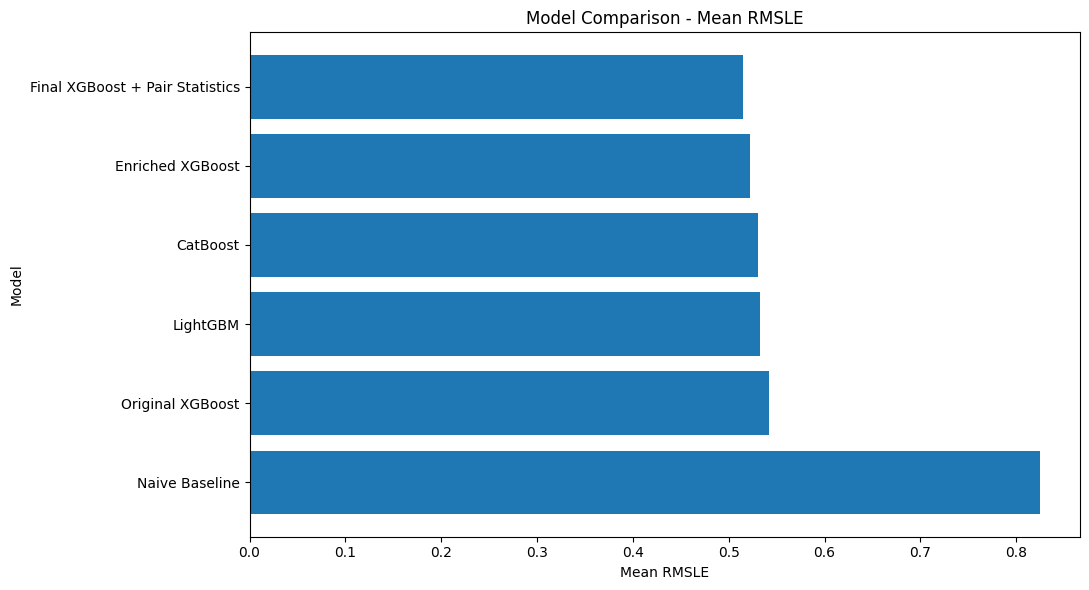

In [707]:
# ============================================================
# MODEL COMPARISON
# ============================================================

plt.figure(figsize=(11, 6))

plt.barh(
    model_comparison["Model"],
    model_comparison["Mean_RMSLE"]
)

plt.xlabel("Mean RMSLE")
plt.ylabel("Model")
plt.title("Model Comparison - Mean RMSLE")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [708]:
# ============================================================
# BASELINE IMPROVEMENT
# ============================================================

final_rmsle = 0.515052

improvement = (
    (baseline_rmsle - final_rmsle)
    / baseline_rmsle
    * 100
)

print(f"Baseline RMSLE: {baseline_rmsle:.6f}")
print(f"Final RMSLE:    {final_rmsle:.6f}")
print(f"Improvement:    {improvement:.2f}%")

Baseline RMSLE: 0.825242
Final RMSLE:    0.515052
Improvement:    37.59%


In [709]:
# ============================================================
# FINAL XGBOOST FOLD PERFORMANCE
# ============================================================

final_fold_results = pd.DataFrame({
    "Fold": [1, 2, 3, 4, 5],
    "Train_Period": [
        "1-80",
        "1-90",
        "1-100",
        "1-110",
        "1-120"
    ],
    "Validation_Period": [
        "81-90",
        "91-100",
        "101-110",
        "111-120",
        "121-130"
    ],
    "RMSLE": [
        0.490278,
        0.518308,
        0.541103,
        0.530579,
        0.494990
    ]
})

final_fold_results

,Fold,Train_Period,Validation_Period,RMSLE
0,1,1-80,81-90,0.490278
1,2,1-90,91-100,0.518308
2,3,1-100,101-110,0.541103
3,4,1-110,111-120,0.530579
4,5,1-120,121-130,0.494990


In [711]:
# ============================================================
# BUILD + TRAIN FINAL XGBOOST MODEL
# ============================================================

# Final 20 features
final_features = features_enriched + [
    "pair_mean",
    "pair_std"
]

final_categorical_features = [
    "category",
    "cuisine",
    "center_type"
]

final_numerical_features = [
    "center_id",
    "meal_id",
    "city_code",
    "region_code",
    "op_area",
    "checkout_price",
    "base_price",
    "emailer_for_promotion",
    "homepage_featured",
    "lag_1",
    "lag_2",
    "lag_4",
    "lag_8",
    "rolling_mean_4",
    "rolling_std_4",
    "pair_mean",
    "pair_std"
]

# ------------------------------------------------------------
# Prepare complete historical training data
# ------------------------------------------------------------

final_train = lag_features.copy()

final_train = final_train.merge(
    meal_info,
    on="meal_id",
    how="left"
)

final_train = final_train.merge(
    center_info,
    on="center_id",
    how="left"
)

# ------------------------------------------------------------
# Pair statistics from all historical demand
# ------------------------------------------------------------

final_pair_stats = (
    final_train
    .groupby(
        ["center_id", "meal_id"]
    )["num_orders"]
    .agg(
        pair_mean="mean",
        pair_std="std"
    )
    .reset_index()
)

final_train = final_train.merge(
    final_pair_stats,
    on=["center_id", "meal_id"],
    how="left"
)

# ------------------------------------------------------------
# X and y
# ------------------------------------------------------------

X_final = final_train[
    final_features
].copy()

y_final = np.log1p(
    final_train["num_orders"]
)

print("X shape:", X_final.shape)
print("y shape:", y_final.shape)

# ------------------------------------------------------------
# Preprocessor
# ------------------------------------------------------------

final_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            final_categorical_features
        ),
        (
            "numerical",
            "passthrough",
            final_numerical_features
        )
    ]
)

# ------------------------------------------------------------
# Final XGBoost
# ------------------------------------------------------------

final_xgb = xgb.XGBRegressor(
    objective="reg:squarederror",
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

# ------------------------------------------------------------
# Final pipeline
# ------------------------------------------------------------

final_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            final_preprocessor
        ),
        (
            "model",
            final_xgb
        )
    ]
)

# ------------------------------------------------------------
# Train
# ------------------------------------------------------------

final_pipeline.fit(
    X_final,
    y_final
)

print("\nFinal XGBoost model trained successfully.")

X shape: (456548, 20)
y shape: (456548,)

Final XGBoost model trained successfully.


In [712]:
# ============================================================
# FINAL FEATURE IMPORTANCE
# ============================================================

feature_names = (
    final_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

importance_values = (
    final_pipeline
    .named_steps["model"]
    .feature_importances_
)

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance_values
})

feature_importance = (
    feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

print("Top 20 features:")
feature_importance.head(20)

Top 20 features:


,Feature,Importance
0,numerical__pair_mean,0.532132
1,numerical__emailer_for_promotion,0.150525
2,numerical__lag_1,0.081047
3,numerical__homepage_featured,0.049068
4,numerical__rolling_mean_4,0.018225
5,categorical__cuisine_Continental,0.013435
6,numerical__checkout_price,0.012133
7,categorical__category_Beverages,0.009331
8,categorical__category_Rice Bowl,0.008459
9,categorical__cuisine_Thai,0.008180


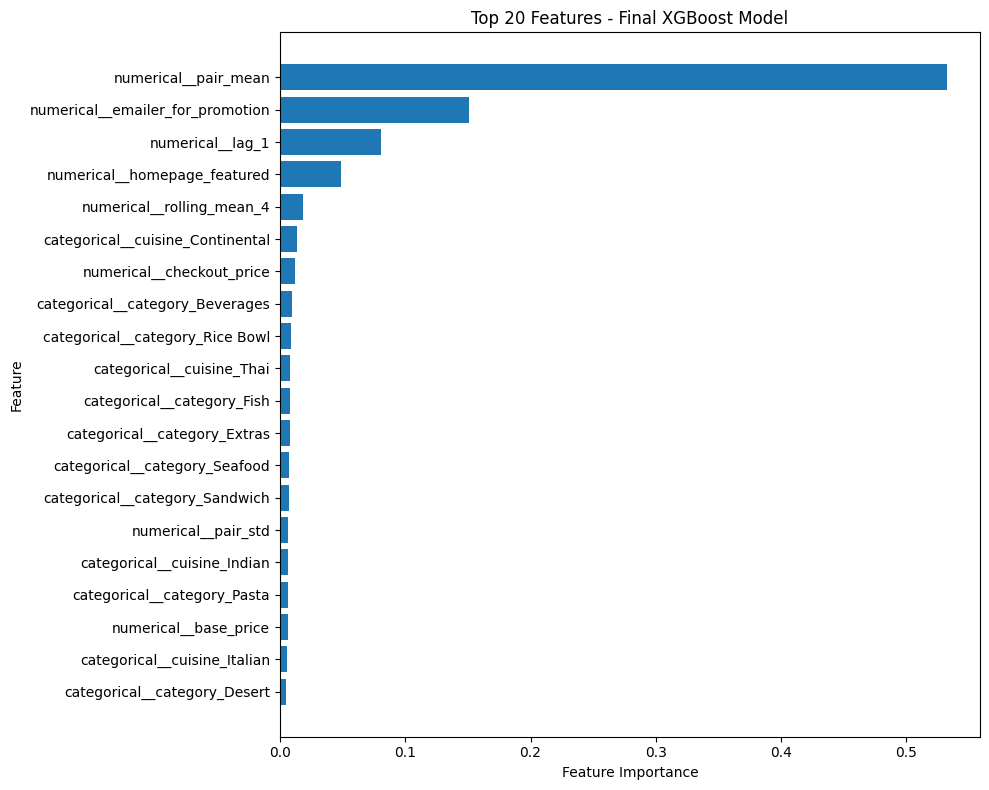

In [713]:
# ============================================================
# TOP 20 FEATURE IMPORTANCE PLOT
# ============================================================

top_20 = feature_importance.head(20)

plt.figure(figsize=(10, 8))

plt.barh(
    top_20["Feature"].iloc[::-1],
    top_20["Importance"].iloc[::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 20 Features - Final XGBoost Model")

plt.tight_layout()
plt.show()

In [714]:
final_features = features_enriched + [
    "pair_mean",
    "pair_std"
]

In [716]:
# Locked model configuration
final_xgb = xgb.XGBRegressor(
    objective="reg:squarederror",
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

Training history : Weeks 1-130
Prediction period: Weeks 131-145

History shape : (407243, 14)
Future shape  : (49305, 14)

Training feature columns:
['week', 'center_id', 'meal_id', 'checkout_price', 'base_price', 'emailer_for_promotion', 'homepage_featured', 'num_orders', 'category', 'cuisine', 'city_code', 'region_code', 'center_type', 'op_area', 'lag_1', 'lag_2', 'lag_4', 'lag_8', 'rolling_mean_4', 'rolling_std_4', 'pair_mean', 'pair_std']

All final features are present.

Locked model trained successfully.
Predicting week 131...
Predicting week 132...
Predicting week 133...
Predicting week 134...
Predicting week 135...
Predicting week 136...
Predicting week 137...
Predicting week 138...
Predicting week 139...
Predicting week 140...
Predicting week 141...
Predicting week 142...
Predicting week 143...
Predicting week 144...
Predicting week 145...

HISTORICAL PREDICTION CHECK
Rows evaluated : 49,305
RMSLE          : 0.475382
MAE            : 67.53

Most accurate predictions:


,week,center_id,meal_id,num_orders,predicted_orders,absolute_error,error_pct
23749,139,75,1571,204,204.000290,0.000290,0.000142
44171,138,149,2490,80,79.998154,0.001846,0.002308
44043,131,149,1971,94,93.997375,0.002625,0.002792
43077,143,145,2704,121,120.995964,0.004036,0.003335
40345,144,132,2139,27,26.994148,0.005852,0.021673
25494,133,80,1207,109,108.992302,0.007698,0.007062
15679,140,55,1770,15,15.011563,0.011563,0.077089
15395,135,53,2704,67,67.013458,0.013458,0.020087
44832,133,152,2577,95,94.983017,0.016983,0.017877
13854,131,51,2577,96,96.018814,0.018814,0.019598



Largest prediction errors:


,week,center_id,meal_id,num_orders,predicted_orders,absolute_error,error_pct
12248,132,43,1971,13150,4700.787598,8449.212402,64.252566
41013,132,137,1971,11056,3752.696777,7303.303223,66.057374
1857,132,13,1971,8979,2541.636230,6437.363770,71.693549
20731,132,67,1971,9019,3447.585938,5571.414062,61.774189
1934,134,13,2290,7911,3151.689453,4759.310547,60.160669
20732,133,67,1971,7803,3453.550293,4349.449707,55.740737
41014,133,137,1971,7926,3590.687988,4335.312012,54.697351
25786,132,80,1971,7060,2730.131592,4329.868408,61.329581
46059,134,157,2290,5577,1280.123047,4296.876953,77.046386
19403,134,65,2290,6426,2256.772705,4169.227295,64.880599


,week,actual_orders,predicted_orders
0,131,899953,811165.8125
1,132,939374,819262.7500
2,133,835583,800381.9375
3,134,975072,787660.0000
4,135,777106,751062.3750
5,136,769623,713753.0625
6,137,719740,671653.3750
7,138,667343,643639.6875
8,139,751935,641387.0000
9,140,802689,696214.6250


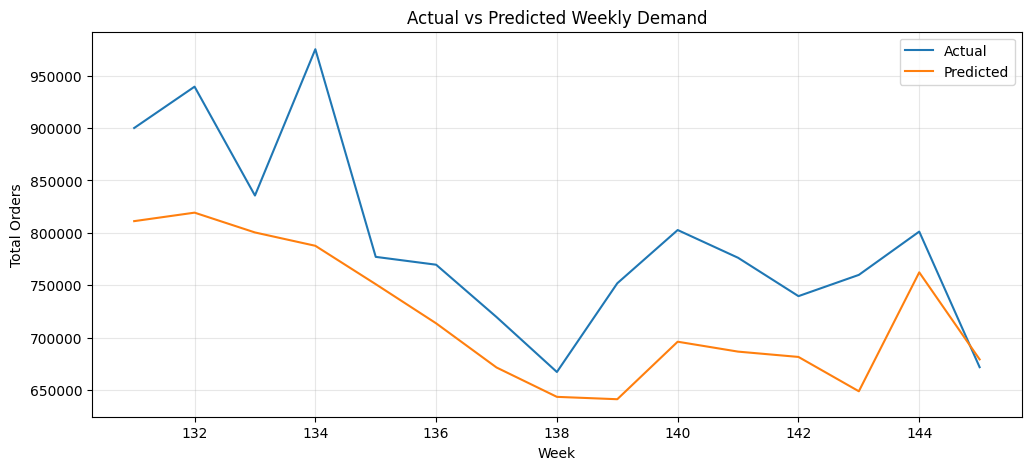

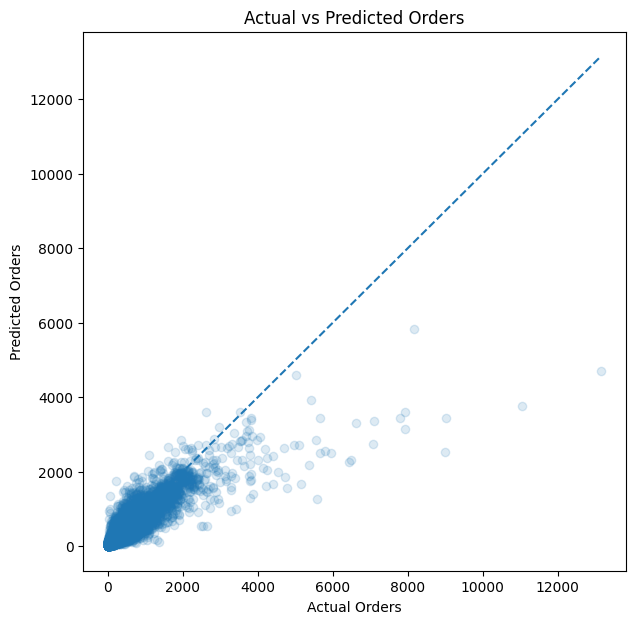


Prediction bias:
Mean error: -22.15
Median error: -5.88
Mean actual demand: 241.10
Mean predicted demand: 218.95


In [719]:
# ============================================================
# FINAL MODEL - HISTORICAL PREDICTION CHECK
# Train: weeks 1-130
# Predict: weeks 131-145
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_squared_log_error,
    mean_absolute_error
)

# ============================================================
# 1. SETTINGS
# ============================================================

TRAIN_END = 130
VALID_START = 131
VALID_END = 145

print(f"Training history : Weeks 1-{TRAIN_END}")
print(f"Prediction period: Weeks {VALID_START}-{VALID_END}")


# ============================================================
# 2. CLEAN SOURCE DATA
# ============================================================

# Keep only the original columns required for forecasting.
# This avoids contamination from previous experiments.

required_source_columns = [
    "week",
    "center_id",
    "meal_id",
    "checkout_price",
    "base_price",
    "emailer_for_promotion",
    "homepage_featured",
    "num_orders",
    "category",
    "cuisine",
    "city_code",
    "region_code",
    "center_type",
    "op_area"
]

# train_enriched may contain num_orders_x / num_orders_y
# because of previous merges. Resolve that here.

clean_train = train_enriched.copy()

if "num_orders" not in clean_train.columns:

    if "num_orders_x" in clean_train.columns:
        clean_train["num_orders"] = clean_train["num_orders_x"]

    elif "num_orders_y" in clean_train.columns:
        clean_train["num_orders"] = clean_train["num_orders_y"]

    else:
        raise ValueError(
            "Could not find the num_orders column."
        )


clean_train = clean_train[
    required_source_columns
].copy()


# ============================================================
# 3. SPLIT HISTORY AND VALIDATION
# ============================================================

history = clean_train[
    clean_train["week"] <= TRAIN_END
].copy()

future_actual = clean_train[
    (clean_train["week"] >= VALID_START) &
    (clean_train["week"] <= VALID_END)
].copy()

print("\nHistory shape :", history.shape)
print("Future shape  :", future_actual.shape)


# ============================================================
# 4. SORT HISTORY
# ============================================================

history = history.sort_values(
    ["center_id", "meal_id", "week"]
).reset_index(drop=True)


# ============================================================
# 5. LAG FEATURE FUNCTION
# ============================================================

def create_lags(df, reference_df):

    result = df.copy()

    lookup = reference_df[
        [
            "center_id",
            "meal_id",
            "week",
            "num_orders"
        ]
    ].copy()

    for lag in [1, 2, 4, 8]:

        lag_lookup = lookup.rename(
            columns={
                "week": "previous_week",
                "num_orders": f"lag_{lag}"
            }
        )

        result["previous_week"] = (
            result["week"] - lag
        )

        result = result.merge(
            lag_lookup[
                [
                    "center_id",
                    "meal_id",
                    "previous_week",
                    f"lag_{lag}"
                ]
            ],
            on=[
                "center_id",
                "meal_id",
                "previous_week"
            ],
            how="left"
        )

        result = result.drop(
            columns=["previous_week"]
        )

    return result


# ============================================================
# 6. ROLLING FEATURE FUNCTION
# ============================================================

def create_rolling_features(df):

    result = df.copy()

    # IMPORTANT:
    # shift(1) means the current week's demand is NOT used.
    # rolling(4) therefore represents the previous 4 observations.

    grouped = (
        result
        .sort_values(
            ["center_id", "meal_id", "week"]
        )
        .groupby(
            ["center_id", "meal_id"]
        )["num_orders"]
    )

    result["rolling_mean_4"] = (
        grouped
        .transform(
            lambda x:
            x.shift(1)
             .rolling(
                 window=4,
                 min_periods=1
             )
             .mean()
        )
    )

    result["rolling_std_4"] = (
        grouped
        .transform(
            lambda x:
            x.shift(1)
             .rolling(
                 window=4,
                 min_periods=2
             )
             .std()
        )
    )

    return result


# ============================================================
# 7. PAIR STATISTICS FUNCTION
# ============================================================

def create_pair_statistics(
    forecast_df,
    reference_df
):

    result = forecast_df.copy()

    pair_stats = (
        reference_df
        .groupby(
            ["center_id", "meal_id"]
        )["num_orders"]
        .agg(
            pair_mean="mean",
            pair_std="std"
        )
        .reset_index()
    )

    result = result.merge(
        pair_stats,
        on=[
            "center_id",
            "meal_id"
        ],
        how="left"
    )

    return result


# ============================================================
# 8. CREATE TRAINING FEATURES
# ============================================================

train_features = create_lags(
    history,
    history
)

train_features = create_rolling_features(
    train_features
)

train_features = create_pair_statistics(
    train_features,
    history
)


# ============================================================
# 9. VERIFY TRAINING FEATURES
# ============================================================

print("\nTraining feature columns:")
print(train_features.columns.tolist())

missing_features = [
    col
    for col in final_features
    if col not in train_features.columns
]

if missing_features:

    raise ValueError(
        f"Missing training features: "
        f"{missing_features}"
    )

print("\nAll final features are present.")


# ============================================================
# 10. PREPARE X AND y
# ============================================================

X_train_check = train_features[
    final_features
].copy()

y_train_check = np.log1p(
    train_features["num_orders"]
)


# ============================================================
# 11. CREATE LOCKED MODEL
# ============================================================

check_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            final_categorical_features
        ),
        (
            "numerical",
            "passthrough",
            final_numerical_features
        )
    ]
)

check_xgb = xgb.XGBRegressor(
    objective="reg:squarederror",
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

check_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            check_preprocessor
        ),
        (
            "model",
            check_xgb
        )
    ]
)


# ============================================================
# 12. TRAIN
# ============================================================

check_pipeline.fit(
    X_train_check,
    y_train_check
)

print("\nLocked model trained successfully.")


# ============================================================
# 13. RECURSIVE FORECAST
# ============================================================

recursive_history = history[
    [
        "week",
        "center_id",
        "meal_id",
        "num_orders"
    ]
].copy()

all_predictions = []


for week in range(
    VALID_START,
    VALID_END + 1
):

    print(
        f"Predicting week {week}..."
    )

    week_data = future_actual[
        future_actual["week"] == week
    ].copy()

    # --------------------------------------------------------
    # LAGS
    # --------------------------------------------------------

    week_features = create_lags(
        week_data,
        recursive_history
    )

    # --------------------------------------------------------
    # ROLLING FEATURES
    # --------------------------------------------------------

    # Create a temporary combined history so that
    # rolling statistics are based only on information
    # available before this prediction.

    temp_history = pd.concat(
        [
            recursive_history,
            week_data[
                [
                    "week",
                    "center_id",
                    "meal_id",
                    "num_orders"
                ]
            ]
        ],
        ignore_index=True
    )

    # We calculate rolling values from recursive_history only.
    rolling_history = recursive_history.copy()

    rolling_history = create_rolling_features(
        rolling_history
    )

    # Get the latest rolling values for each pair.

    latest_rolling = (
        rolling_history
        .sort_values("week")
        .groupby(
            ["center_id", "meal_id"]
        )
        .tail(1)
        [
            [
                "center_id",
                "meal_id",
                "rolling_mean_4",
                "rolling_std_4"
            ]
        ]
    )

    week_features = week_features.merge(
        latest_rolling,
        on=[
            "center_id",
            "meal_id"
        ],
        how="left"
    )

    # --------------------------------------------------------
    # PAIR STATISTICS
    # --------------------------------------------------------

    week_features = create_pair_statistics(
        week_features,
        recursive_history
    )

    # --------------------------------------------------------
    # CHECK FEATURES
    # --------------------------------------------------------

    missing_features = [
        col
        for col in final_features
        if col not in week_features.columns
    ]

    if missing_features:

        raise ValueError(
            f"Week {week}: missing "
            f"{missing_features}"
        )

    # --------------------------------------------------------
    # PREDICT
    # --------------------------------------------------------

    X_week = week_features[
        final_features
    ].copy()

    log_prediction = (
        check_pipeline.predict(
            X_week
        )
    )

    predicted_orders = np.clip(
        np.expm1(log_prediction),
        0,
        None
    )

    week_features[
        "predicted_orders"
    ] = predicted_orders

    all_predictions.append(
        week_features[
            [
                "week",
                "center_id",
                "meal_id",
                "predicted_orders"
            ]
        ]
    )

    # --------------------------------------------------------
    # AFTER prediction:
    # reveal the actual week to the model's history.
    # --------------------------------------------------------

    recursive_history = pd.concat(
        [
            recursive_history,
            week_data[
                [
                    "week",
                    "center_id",
                    "meal_id",
                    "num_orders"
                ]
            ]
        ],
        ignore_index=True
    )


# ============================================================
# 14. COMBINE RESULTS
# ============================================================

predictions = pd.concat(
    all_predictions,
    ignore_index=True
)

actual = future_actual[
    [
        "week",
        "center_id",
        "meal_id",
        "num_orders"
    ]
].copy()

prediction_check = actual.merge(
    predictions,
    on=[
        "week",
        "center_id",
        "meal_id"
    ],
    how="inner"
)


# ============================================================
# 15. ERROR METRICS
# ============================================================

prediction_check["absolute_error"] = (
    prediction_check["num_orders"]
    - prediction_check["predicted_orders"]
).abs()

prediction_check["error_pct"] = (
    prediction_check["absolute_error"]
    / prediction_check["num_orders"]
) * 100


rmsle = np.sqrt(
    mean_squared_log_error(
        prediction_check["num_orders"],
        prediction_check["predicted_orders"]
    )
)

mae = mean_absolute_error(
    prediction_check["num_orders"],
    prediction_check["predicted_orders"]
)


# ============================================================
# 16. RESULTS
# ============================================================

print("\n" + "=" * 60)
print("HISTORICAL PREDICTION CHECK")
print("=" * 60)

print(
    f"Rows evaluated : "
    f"{len(prediction_check):,}"
)

print(
    f"RMSLE          : "
    f"{rmsle:.6f}"
)

print(
    f"MAE            : "
    f"{mae:.2f}"
)


# ============================================================
# 17. SAMPLE PREDICTIONS
# ============================================================

print("\nMost accurate predictions:")

display(
    prediction_check[
        [
            "week",
            "center_id",
            "meal_id",
            "num_orders",
            "predicted_orders",
            "absolute_error",
            "error_pct"
        ]
    ]
    .sort_values(
        "absolute_error"
    )
    .head(20)
)


print("\nLargest prediction errors:")

display(
    prediction_check[
        [
            "week",
            "center_id",
            "meal_id",
            "num_orders",
            "predicted_orders",
            "absolute_error",
            "error_pct"
        ]
    ]
    .sort_values(
        "absolute_error",
        ascending=False
    )
    .head(20)
)


# ============================================================
# 18. WEEKLY AGGREGATION
# ============================================================

weekly_check = (
    prediction_check
    .groupby("week")
    .agg(
        actual_orders=("num_orders", "sum"),
        predicted_orders=("predicted_orders", "sum")
    )
    .reset_index()
)

display(weekly_check)


# ============================================================
# 19. ACTUAL VS PREDICTED PLOT
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(
    weekly_check["week"],
    weekly_check["actual_orders"],
    label="Actual"
)

plt.plot(
    weekly_check["week"],
    weekly_check["predicted_orders"],
    label="Predicted"
)

plt.xlabel("Week")
plt.ylabel("Total Orders")

plt.title(
    "Actual vs Predicted Weekly Demand"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()


# ============================================================
# 20. SCATTER PLOT
# ============================================================

plt.figure(figsize=(7, 7))

plt.scatter(
    prediction_check["num_orders"],
    prediction_check["predicted_orders"],
    alpha=0.15
)

max_value = max(
    prediction_check["num_orders"].max(),
    prediction_check["predicted_orders"].max()
)

plt.plot(
    [0, max_value],
    [0, max_value],
    linestyle="--"
)

plt.xlabel("Actual Orders")
plt.ylabel("Predicted Orders")

plt.title(
    "Actual vs Predicted Orders"
)

plt.show()


# ============================================================
# 21. BIAS
# ============================================================

prediction_check["prediction_error"] = (
    prediction_check["predicted_orders"]
    - prediction_check["num_orders"]
)

print("\nPrediction bias:")

print(
    f"Mean error: "
    f"{prediction_check['prediction_error'].mean():.2f}"
)

print(
    f"Median error: "
    f"{prediction_check['prediction_error'].median():.2f}"
)

print(
    f"Mean actual demand: "
    f"{prediction_check['num_orders'].mean():.2f}"
)

print(
    f"Mean predicted demand: "
    f"{prediction_check['predicted_orders'].mean():.2f}"
)

# Streamlit

In [720]:
# ============================================================
# FINAL PRODUCTION MODEL
# Train on ALL historical weeks: 1-145
# ============================================================

import numpy as np
import pandas as pd
import xgboost as xgb

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
import joblib


# ============================================================
# 1. CLEAN TRAINING DATA
# ============================================================

final_source = train_enriched.copy()

# Resolve num_orders if previous merges created duplicates
if "num_orders" not in final_source.columns:

    if "num_orders_x" in final_source.columns:
        final_source["num_orders"] = final_source["num_orders_x"]

    elif "num_orders_y" in final_source.columns:
        final_source["num_orders"] = final_source["num_orders_y"]

    else:
        raise ValueError(
            "num_orders column not found."
        )


# Only use the columns required by the final model
required_columns = [
    "week",
    "center_id",
    "meal_id",
    "checkout_price",
    "base_price",
    "emailer_for_promotion",
    "homepage_featured",
    "num_orders",
    "category",
    "cuisine",
    "city_code",
    "region_code",
    "center_type",
    "op_area"
]

final_source = final_source[
    required_columns
].copy()


# ============================================================
# 2. SORT DATA
# ============================================================

final_source = final_source.sort_values(
    ["center_id", "meal_id", "week"]
).reset_index(drop=True)


# ============================================================
# 3. CREATE EXACT CALENDAR LAGS
# ============================================================

def create_final_lag(df, lag):

    lookup = df[
        [
            "center_id",
            "meal_id",
            "week",
            "num_orders"
        ]
    ].copy()

    lookup = lookup.rename(
        columns={
            "week": "previous_week",
            "num_orders": f"lag_{lag}"
        }
    )

    result = df.copy()

    result["previous_week"] = (
        result["week"] - lag
    )

    result = result.merge(
        lookup,
        on=[
            "center_id",
            "meal_id",
            "previous_week"
        ],
        how="left"
    )

    result = result.drop(
        columns=["previous_week"]
    )

    return result


final_train = final_source.copy()

for lag in [1, 2, 4, 8]:

    final_train = create_final_lag(
        final_train,
        lag
    )


# ============================================================
# 4. ROLLING FEATURES
# ============================================================

grouped_orders = (
    final_train
    .sort_values(
        ["center_id", "meal_id", "week"]
    )
    .groupby(
        ["center_id", "meal_id"]
    )["num_orders"]
)

final_train["rolling_mean_4"] = (
    grouped_orders
    .transform(
        lambda x:
        x.shift(1)
         .rolling(
             4,
             min_periods=1
         )
         .mean()
    )
)

final_train["rolling_std_4"] = (
    grouped_orders
    .transform(
        lambda x:
        x.shift(1)
         .rolling(
             4,
             min_periods=2
         )
         .std()
    )
)


# ============================================================
# 5. CENTER × MEAL PAIR STATISTICS
# ============================================================

pair_stats = (
    final_source
    .groupby(
        ["center_id", "meal_id"]
    )["num_orders"]
    .agg(
        pair_mean="mean",
        pair_std="std"
    )
    .reset_index()
)

final_train = final_train.merge(
    pair_stats,
    on=[
        "center_id",
        "meal_id"
    ],
    how="left"
)


# ============================================================
# 6. VERIFY FINAL FEATURES
# ============================================================

missing_features = [
    feature
    for feature in final_features
    if feature not in final_train.columns
]

if missing_features:

    raise ValueError(
        f"Missing final features: "
        f"{missing_features}"
    )

print("All final features present.")

print(
    "\nFinal training shape:",
    final_train.shape
)


# ============================================================
# 7. X AND Y
# ============================================================

X_final = final_train[
    final_features
].copy()

y_final = np.log1p(
    final_train["num_orders"]
)


# ============================================================
# 8. PREPROCESSOR
# ============================================================

final_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            final_categorical_features
        ),
        (
            "numerical",
            "passthrough",
            final_numerical_features
        )
    ]
)


# ============================================================
# 9. LOCKED XGBOOST
# ============================================================

final_xgb = xgb.XGBRegressor(
    objective="reg:squarederror",
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)


# ============================================================
# 10. COMPLETE PIPELINE
# ============================================================

final_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            final_preprocessor
        ),
        (
            "model",
            final_xgb
        )
    ]
)


# ============================================================
# 11. TRAIN FINAL MODEL
# ============================================================

print("\nTraining final model...")

final_pipeline.fit(
    X_final,
    y_final
)

print("Final model trained successfully.")


# ============================================================
# 12. SAVE COMPLETE PIPELINE
# ============================================================

model_path = "meal_demand_forecasting_final.pkl"

joblib.dump(
    final_pipeline,
    model_path
)

print(
    f"\nModel saved successfully:"
    f" {model_path}"
)


# ============================================================
# 13. VERIFY SAVED MODEL
# ============================================================

loaded_model = joblib.load(
    model_path
)

print(
    "\nLoaded model type:",
    type(loaded_model)
)

print(
    "Pipeline steps:",
    loaded_model.named_steps.keys()
)


# ============================================================
# 14. TEST THAT SAVED MODEL ACTUALLY PREDICTS
# ============================================================

test_predictions_log = loaded_model.predict(
    X_final.head(10)
)

test_predictions = np.expm1(
    test_predictions_log
)

print("\nSample predictions from saved model:")

sample_check = pd.DataFrame({
    "actual_orders": final_train[
        "num_orders"
    ].head(10).values,

    "predicted_orders": test_predictions
})

display(sample_check)


# ============================================================
# 15. FILE SIZE
# ============================================================

import os

file_size_mb = (
    os.path.getsize(model_path)
    / (1024 ** 2)
)

print(
    f"\nModel file size: "
    f"{file_size_mb:.2f} MB"
)

All final features present.

Final training shape: (456548, 22)

Training final model...
Final model trained successfully.

Model saved successfully: meal_demand_forecasting_final.pkl

Loaded model type: <class 'sklearn.pipeline.Pipeline'>
Pipeline steps: dict_keys(['preprocessor', 'model'])

Sample predictions from saved model:


,actual_orders,predicted_orders
0,865,1085.320923
1,782,792.326416
2,851,862.803589
3,1202,884.985596
4,958,880.190063
5,1094,966.094482
6,1513,1111.657715
7,1149,1229.240479
8,1282,1115.356079
9,1473,1167.479248



Model file size: 7.48 MB
